In [5]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import itertools
import time
import random
import warnings
!pip install -q arch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from arch.unitroot import VarianceRatio
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
# ============================================================
# CELL 2 — Preprocessing
# ============================================================
def load_and_preprocess(filepath, smooth_window=3, diff_order=1,
                        feature_range=(0, 1), loader_type="xlsx"):
    """
    loader_type: "xlsx" cho a, "csv" cho b.
    """
    if loader_type == "xlsx":
        df = pd.read_excel(filepath, skiprows=4)
        df = df.rename(columns={
            'Unnamed: 0': 'Date',  'Unnamed: 1': 'Open',
            'Unnamed: 2': 'Max_price', 'Unnamed: 3': 'Min_price',
            'Unnamed: 4': 'Close'
        })
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['Date']).sort_values('Date').set_index('Date')
    elif loader_type == "csv":
        df = pd.read_csv(filepath)
        df = df.rename(columns={
            'Ngày': 'Date', 'Lần cuối': 'Close',
            'Mở': 'Open', 'Cao': 'Max_price', 'Thấp': 'Min_price'
        })
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['Date'])
        for col in ['Open', 'Max_price', 'Min_price', 'Close']:
            df[col] = (df[col].astype(str)
                       .str.replace(',', '', regex=False)
                       .str.replace('"', '', regex=False)
                       .str.strip())
        df = df.sort_values('Date').set_index('Date')
    numeric_cols = ['Open', 'Max_price', 'Min_price', 'Close']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=numeric_cols)
    df['Close'] = df['Close'].interpolate()
    df['Close_Smooth'] = df['Close'].rolling(
        window=smooth_window, min_periods=1).mean()
    df['Processed'] = df['Close_Smooth'].diff().fillna(0)
    train_end = int(0.8 * len(df))
    val_end   = int(0.9 * len(df))
    df_train = df.iloc[:train_end]
    df_val   = df.iloc[train_end:val_end]
    df_test  = df.iloc[val_end:]
    print(f"Train : {len(df_train)} ngày "
          f"({df_train.index[0].date()} → {df_train.index[-1].date()})")
    print(f"Val   : {len(df_val)} ngày "
          f"({df_val.index[0].date()} → {df_val.index[-1].date()})")
    print(f"Test  : {len(df_test)} ngày "
          f"({df_test.index[0].date()} → {df_test.index[-1].date()})")
    scaler = MinMaxScaler(feature_range=feature_range)
    train_scaled = scaler.fit_transform(
        df_train['Processed'].values.reshape(-1, 1))
    val_scaled   = scaler.transform(
        df_val['Processed'].values.reshape(-1, 1))
    test_scaled  = scaler.transform(
        df_test['Processed'].values.reshape(-1, 1))
    return train_scaled, val_scaled, test_scaled, scaler, df

In [7]:
# ============================================================
# CELL 3 — Utilities: sequences, DeepESN, ESN, helpers
# ============================================================
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


class DeepESN:
    def __init__(self, n_reservoir=50, n_layers=2, spectral_radius=0.9,
                 sparsity=0.1, ridge_alpha=1e-6, random_state=1234):
        self.n_reservoir     = n_reservoir
        self.n_layers        = n_layers
        self.spectral_radius = spectral_radius
        self.sparsity        = sparsity
        self.ridge_alpha     = ridge_alpha
        self.random_state    = np.random.RandomState(random_state)

    def _init_layer(self, input_dim):
        Win = self.random_state.uniform(
            -0.5, 0.5, (self.n_reservoir, input_dim + 1))
        W = self.random_state.rand(
            self.n_reservoir, self.n_reservoir) - 0.5
        W[self.random_state.rand(*W.shape) > self.sparsity] = 0
        radius = np.max(np.abs(np.linalg.eigvals(W)))
        W *= self.spectral_radius / radius
        return Win, W

    def _run_reservoir(self, X, init_states=None, sigma=0.0):
        N = X.shape[0]
        states = np.zeros((N, self.n_reservoir * self.n_layers))
        for t in range(N):
            layer_input   = X[t]
            concat_states = []
            for l in range(self.n_layers):
                if t == 0:
                    prev = (init_states[l] if init_states is not None
                            else np.zeros(self.n_reservoir))
                else:
                    prev = states[t-1, l*self.n_reservoir:(l+1)*self.n_reservoir]
                noise = (self.random_state.normal(0, sigma, self.n_reservoir)
                         if sigma > 0 else 0.0)
                layer_input_bias = np.concatenate([[1.0], layer_input])
                current = np.maximum(0,
                    np.dot(self.Win_layers[l], layer_input_bias) +
                    np.dot(self.W_layers[l], prev) + noise)
                concat_states.append(current)
                layer_input = current
            states[t] = np.concatenate(concat_states)
        last_states = [
            states[-1, l*self.n_reservoir:(l+1)*self.n_reservoir]
            for l in range(self.n_layers)
        ]
        return states, last_states

    def fit(self, X, y, sigma=1e-4):
        N, input_dim = X.shape
        self.Win_layers, self.W_layers = [], []
        for l in range(self.n_layers):
            Win, W = self._init_layer(
                input_dim if l == 0 else self.n_reservoir)
            self.Win_layers.append(Win)
            self.W_layers.append(W)
        states, self.last_states_ = self._run_reservoir(X, sigma=sigma)
        self.ridge = Ridge(alpha=self.ridge_alpha)
        self.ridge.fit(states, y)

    def predict(self, X, warm_up_states=None):
        states, self.last_states_ = self._run_reservoir(
            X, init_states=warm_up_states)
        return self.ridge.predict(states)


class ESN:
    """ESN 1 lớp."""
    def __init__(self, n_reservoir=50, spectral_radius=0.9,
                 sparsity=0.1, ridge_alpha=1e-6, random_state=1234):
        self.n_reservoir     = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity        = sparsity
        self.ridge_alpha     = ridge_alpha
        self.random_state    = np.random.RandomState(random_state)

    def _init_weights(self, input_dim):
        self.Win = self.random_state.uniform(
            -0.5, 0.5, (self.n_reservoir, input_dim + 1))
        W = self.random_state.rand(
            self.n_reservoir, self.n_reservoir) - 0.5
        W[self.random_state.rand(*W.shape) > self.sparsity] = 0
        radius = np.max(np.abs(np.linalg.eigvals(W)))
        self.W = W * (self.spectral_radius / radius)

    def _run(self, X, init_state=None, sigma=0.0):
        N, input_dim = X.shape
        states = np.zeros((N, self.n_reservoir))
        for t in range(N):
            u    = np.concatenate([[1.0], X[t]])
            prev = (init_state if (t == 0 and init_state is not None)
                    else (np.zeros(self.n_reservoir) if t == 0
                          else states[t-1]))
            noise = (self.random_state.normal(0, sigma, self.n_reservoir)
                     if sigma > 0 else 0.0)
            states[t] = np.maximum(
                0, np.dot(self.Win, u) + np.dot(self.W, prev) + noise)
        return states

    def fit(self, X, y, sigma=1e-4):
        self._init_weights(X.shape[1])
        states = self._run(X, sigma=sigma)
        self.ridge = Ridge(alpha=self.ridge_alpha)
        self.ridge.fit(states, y)
        self.last_state_ = states[-1].copy()

    def predict(self, X, warm_up_state=None):
        states = self._run(X, init_state=warm_up_state)
        self.last_state_ = states[-1].copy()
        return self.ridge.predict(states)


def invert_difference(last_value, diff_series):
    inverted, prev = [], last_value
    for d in diff_series:
        v = prev + d
        inverted.append(v)
        prev = v
    return np.array(inverted)


def plot_esn_forecast(df, y_true_inv, y_pred_inv,
                      title="ESN Forecast vs Actual"):
    plt.figure(figsize=(10, 5))
    plt.plot(df.index[-len(y_true_inv):], y_true_inv,
             label="Actual", color='black', linewidth=1.5)
    plt.plot(df.index[-len(y_pred_inv):], y_pred_inv,
             label="Predicted", color='red',
             linestyle='--', linewidth=1.5)
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [8]:
# ============================================================
# CELL 4–11 — Pipeline chính
# ============================================================
def run_pipeline(filepath, stock_name, loader_type="xlsx",
                 smooth_window=5, window=10):
    print("\n" + "="*75)
    print(f"  PIPELINE: {stock_name}  |  file: {filepath}")
    print("="*75 + "\n")

    # CELL 4 — Load & sequences
    train_scaled, val_scaled, test_scaled, scaler, df = load_and_preprocess(
        filepath, smooth_window=smooth_window, loader_type=loader_type)
    train_val_overlap = np.concatenate([train_scaled[-window:], val_scaled])
    val_test_overlap  = np.concatenate([val_scaled[-window:],   test_scaled])
    X_train, y_train = create_sequences(train_scaled,      window)
    X_val,   y_val   = create_sequences(train_val_overlap, window)
    X_test,  y_test  = create_sequences(val_test_overlap,  window)
    X_trainval = np.concatenate([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    last_train_value = df['Close_Smooth'].iloc[int(0.8 * len(df)) - 1]
    last_val_value   = df['Close_Smooth'].iloc[int(0.9 * len(df)) - 1]
    print(f"Shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Anchor Train→Val : {last_train_value:.2f}")
    print(f"Anchor Val→Test  : {last_val_value:.2f}")
    SEEDS = [0, 42, 123, 456, 789, 1234]

    # CELL 5-6 — Deep ESN: grid search + multi-seed
    print(f"\n{'='*60}\nMÔ HÌNH: DEEP ESN  [{stock_name}]\n{'='*60}")
    n_reservoir_list     = [40, 45, 50, 55]
    n_layers_list        = [2, 3]
    spectral_radius_list = [0.70, 0.72, 0.73, 0.74, 0.75]
    sparsity_list        = [0.07, 0.08, 0.09, 0.1, 0.12]
    ridge_alpha_list     = [5e-4, 7e-4, 1e-3, 2e-3, 3e-3, 4e-3]
    total_combinations = (len(n_reservoir_list) * len(n_layers_list) *
                          len(spectral_radius_list) * len(sparsity_list) *
                          len(ridge_alpha_list))
    print(f"Grid Search Deep ESN: {total_combinations} combinations")
    best_mae, best_params = float('inf'), None
    all_results = []
    for iteration, (n_res, n_layers, sr, spa, alpha) in enumerate(
            itertools.product(n_reservoir_list, n_layers_list,
                              spectral_radius_list, sparsity_list,
                              ridge_alpha_list), start=1):
        model = DeepESN(n_reservoir=n_res, n_layers=n_layers,
                        spectral_radius=sr, sparsity=spa, ridge_alpha=alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val, warm_up_states=model.last_states_)
        y_pred_diff = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_true_diff = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
        y_pred_inv  = invert_difference(last_train_value, y_pred_diff)
        y_true_inv  = invert_difference(last_train_value, y_true_diff)
        mae = mean_absolute_error(y_true_inv, y_pred_inv)
        result_str = (f"[{iteration}/{total_combinations}] "
                      f"n_res={n_res}, n_layers={n_layers}, sr={sr}, "
                      f"spa={spa}, alpha={alpha} -> MAE={mae:.2f}")
        all_results.append(result_str)
        if iteration <= 3:   print(result_str)
        elif iteration == 4: print(f"...\n(Còn {total_combinations-6} combinations...)\n...")
        if mae < best_mae:
            best_mae, best_params = mae, (n_res, n_layers, sr, spa, alpha)
    print("\n".join(all_results[-3:]))
    print(f"\nBest Deep ESN: n_res={best_params[0]}, n_layers={best_params[1]}, "
          f"sr={best_params[2]}, spa={best_params[3]}, alpha={best_params[4]}")
    print(f"Val MAE: {best_mae:.2f}")

    mae_list, rmse_list, mape_list = [], [], []
    all_pred_inv, seed_results = [], []
    traintime_list_deepesn = []
    y_true_inv_seed = None
    for seed in SEEDS:
        model_seed = DeepESN(
            n_reservoir=best_params[0], n_layers=best_params[1],
            spectral_radius=best_params[2], sparsity=best_params[3],
            ridge_alpha=best_params[4], random_state=seed)
        _t0 = time.time()
        model_seed.fit(X_trainval, y_trainval)
        traintime_list_deepesn.append(time.time() - _t0)
        y_pred = model_seed.predict(X_test, warm_up_states=model_seed.last_states_)
        y_pred_diff     = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_true_diff     = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_inv_seed = invert_difference(last_val_value, y_pred_diff)
        y_true_inv_seed = invert_difference(last_val_value, y_true_diff)
        mae_s  = mean_absolute_error(y_true_inv_seed, y_pred_inv_seed)
        rmse_s = np.sqrt(mean_squared_error(y_true_inv_seed, y_pred_inv_seed))
        mape_s = np.mean(np.abs(
            (y_true_inv_seed - y_pred_inv_seed) /
            (np.abs(y_true_inv_seed) + 1e-10))) * 100
        mae_list.append(mae_s); rmse_list.append(rmse_s); mape_list.append(mape_s)
        all_pred_inv.append(y_pred_inv_seed)
        seed_results.append({"seed": seed, "mae": mae_s,
                              "rmse": rmse_s, "mape": mape_s})
    seed_results = sorted(seed_results, key=lambda x: x["mae"])
    print(f"\n{'='*55}\nDeep ESN — Kết quả từng seed [{stock_name}]\n{'='*55}")
    for r in seed_results:
        print(f"  Seed {r['seed']:4d} → MAE={r['mae']:.2f}, "
              f"RMSE={r['rmse']:.2f}, MAPE={r['mape']:.2f}%")
    print(f"\n{'='*55}\nDeep ESN — Test (mean ± std, 6 seeds) [{stock_name}]\n{'='*55}")
    print(f"  MAE  = {np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}")
    print(f"  RMSE = {np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}")
    print(f"  MAPE = {np.mean(mape_list):.2f}% ± {np.std(mape_list):.2f}%")
    y_pred_deepesn_inv = np.mean(all_pred_inv, axis=0)
    y_true_deepesn_inv = y_true_inv_seed
    mae_deepesn  = np.mean(mae_list)
    rmse_deepesn = np.mean(rmse_list)
    mape_deepesn = np.mean(mape_list)
    plot_esn_forecast(df, y_true_deepesn_inv, y_pred_deepesn_inv,
                      title=f"Deep ESN Forecast ({stock_name})")

    # CELL 7 — ARIMA
    print(f"\n{'='*60}\nMÔ HÌNH 1: ARIMA  [{stock_name}]\n{'='*60}")
    train_end = int(0.8 * len(df))
    val_end   = int(0.9 * len(df))
    close_train    = df['Close_Smooth'].iloc[:train_end]
    close_val      = df['Close_Smooth'].iloc[train_end:val_end]
    close_test     = df['Close_Smooth'].iloc[val_end:]
    close_trainval = df['Close_Smooth'].iloc[:val_end]
    assert len(close_test) == len(y_true_deepesn_inv), \
        f"Độ dài không khớp: {len(close_test)} vs {len(y_true_deepesn_inv)}"
    best_arima_mae, best_arima_order = float('inf'), None
    print("Grid search ARIMA order trên Val...")
    for p, d, q in itertools.product([1, 2, 3], [1], [0, 1, 2]):
        try:
            res = ARIMA(close_train, order=(p, d, q)).fit()
            mae_tmp = mean_absolute_error(
                close_val.values, res.forecast(steps=len(close_val)).values)
            if mae_tmp < best_arima_mae:
                best_arima_mae, best_arima_order = mae_tmp, (p, d, q)
        except Exception:
            continue
    print(f"Best ARIMA order: {best_arima_order}, Val MAE: {best_arima_mae:.2f}")
    _t0 = time.time()
    res_final      = ARIMA(close_trainval, order=best_arima_order).fit()
    traintime_arima = time.time() - _t0
    arima_forecast = res_final.forecast(steps=len(close_test))
    arima_true     = close_test.values
    arima_pred     = arima_forecast.values
    mae_arima  = mean_absolute_error(arima_true, arima_pred)
    rmse_arima = np.sqrt(mean_squared_error(arima_true, arima_pred))
    mape_arima = np.mean(np.abs(
        (arima_true - arima_pred) / (np.abs(arima_true) + 1e-10))) * 100
    print(f"\nARIMA{best_arima_order} — Test Metrics [{stock_name}]:")
    print(f"  MAE  = {mae_arima:.2f}")
    print(f"  RMSE = {rmse_arima:.2f}")
    print(f"  MAPE = {mape_arima:.2f}%")
    plot_esn_forecast(df, arima_true, arima_pred,
                      title=f"ARIMA{best_arima_order} Forecast vs Actual ({stock_name})")

    # CELL 8 — ESN tiêu chuẩn
    print(f"\n{'='*60}\nMÔ HÌNH 2: ESN TIÊU CHUẨN  [{stock_name}]\n{'='*60}")
    n_reservoir_list_esn     = [40, 50, 60, 70, 80]
    spectral_radius_list_esn = [0.70, 0.73, 0.75, 0.77, 0.80]
    sparsity_list_esn        = [0.07, 0.09, 0.1, 0.12, 0.15]
    ridge_alpha_list_esn     = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2]
    total_esn = (len(n_reservoir_list_esn) * len(spectral_radius_list_esn)
                 * len(sparsity_list_esn) * len(ridge_alpha_list_esn))
    print(f"Grid Search ESN: {total_esn} combinations")
    best_esn_mae, best_esn_params = float('inf'), None
    for n_res, sr, spa, alpha in itertools.product(
            n_reservoir_list_esn, spectral_radius_list_esn,
            sparsity_list_esn, ridge_alpha_list_esn):
        esn_tmp = ESN(n_reservoir=n_res, spectral_radius=sr,
                      sparsity=spa, ridge_alpha=alpha, random_state=42)
        esn_tmp.fit(X_train, y_train)
        y_pred = esn_tmp.predict(X_val, warm_up_state=esn_tmp.last_state_)
        y_pred_diff = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_true_diff = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
        y_pred_inv  = invert_difference(last_train_value, y_pred_diff)
        y_true_inv  = invert_difference(last_train_value, y_true_diff)
        mae = mean_absolute_error(y_true_inv, y_pred_inv)
        if mae < best_esn_mae:
            best_esn_mae, best_esn_params = mae, (n_res, sr, spa, alpha)
    print(f"Best ESN: n_res={best_esn_params[0]}, sr={best_esn_params[1]}, "
          f"spa={best_esn_params[2]}, alpha={best_esn_params[3]}")
    print(f"Val MAE (seed=42): {best_esn_mae:.2f}")
    mae_list_esn, rmse_list_esn, mape_list_esn = [], [], []
    all_pred_esn_inv, esn_seed_results = [], []
    traintime_list_esn = []
    for seed in SEEDS:
        esn_s = ESN(n_reservoir=best_esn_params[0],
                    spectral_radius=best_esn_params[1],
                    sparsity=best_esn_params[2],
                    ridge_alpha=best_esn_params[3],
                    random_state=seed)
        _t0 = time.time()
        esn_s.fit(X_trainval, y_trainval)
        traintime_list_esn.append(time.time() - _t0)
        y_pred_s = esn_s.predict(X_test, warm_up_state=esn_s.last_state_)
        y_pred_diff  = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
        y_true_diff  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_inv_s = invert_difference(last_val_value, y_pred_diff)
        y_true_inv_s = invert_difference(last_val_value, y_true_diff)
        mae_s  = mean_absolute_error(y_true_inv_s, y_pred_inv_s)
        rmse_s = np.sqrt(mean_squared_error(y_true_inv_s, y_pred_inv_s))
        mape_s = np.mean(np.abs(
            (y_true_inv_s - y_pred_inv_s) /
            (np.abs(y_true_inv_s) + 1e-10))) * 100
        mae_list_esn.append(mae_s); rmse_list_esn.append(rmse_s)
        mape_list_esn.append(mape_s); all_pred_esn_inv.append(y_pred_inv_s)
        esn_seed_results.append({"seed": seed, "mae": mae_s,
                                  "rmse": rmse_s, "mape": mape_s})
    esn_seed_results = sorted(esn_seed_results, key=lambda x: x["mae"])
    print(f"\n{'='*55}\nESN tiêu chuẩn — Kết quả từng seed [{stock_name}]\n{'='*55}")
    for r in esn_seed_results:
        print(f"  Seed {r['seed']:4d} → MAE={r['mae']:.2f}, "
              f"RMSE={r['rmse']:.2f}, MAPE={r['mape']:.2f}%")
    print(f"\n{'='*55}\nESN tiêu chuẩn — Test (mean ± std, 6 seeds) [{stock_name}]\n{'='*55}")
    print(f"  MAE  = {np.mean(mae_list_esn):.2f} ± {np.std(mae_list_esn):.2f}")
    print(f"  RMSE = {np.mean(rmse_list_esn):.2f} ± {np.std(rmse_list_esn):.2f}")
    print(f"  MAPE = {np.mean(mape_list_esn):.2f}% ± {np.std(mape_list_esn):.2f}%")
    y_pred_esn_inv = np.mean(all_pred_esn_inv, axis=0)
    y_true_esn_inv = y_true_inv_s
    mae_esn  = np.mean(mae_list_esn)
    rmse_esn = np.mean(rmse_list_esn)
    mape_esn = np.mean(mape_list_esn)
    plot_esn_forecast(df, y_true_esn_inv, y_pred_esn_inv,
                      title=f"ESN Tiêu chuẩn Forecast vs Actual ({stock_name})")

    # CELL 9 — LSTM
    print(f"\n{'='*60}\nMÔ HÌNH 3: LSTM  [{stock_name}]\n{'='*60}")
    X_train_lstm    = X_train.reshape(-1, window, 1)
    X_val_lstm      = X_val.reshape(-1, window, 1)
    X_test_lstm     = X_test.reshape(-1, window, 1)
    X_trainval_lstm = X_trainval.reshape(-1, window, 1)
    best_lstm_mae, best_lstm_cfg = float('inf'), None
    print("Grid search LSTM...")
    for units, drop, lr in itertools.product([40, 48, 50], [0.1, 0.2, 0.3],
                                              [1e-3, 5e-3, 1e-2]):
        random.seed(42); np.random.seed(42); tf.random.set_seed(42)
        model_lstm = Sequential([
            LSTM(units, input_shape=(window, 1), return_sequences=False),
            Dropout(drop), Dense(1)])
        model_lstm.compile(optimizer=Adam(lr), loss='mse')
        es = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=0)
        model_lstm.fit(X_train_lstm, y_train,
                       validation_data=(X_val_lstm, y_val),
                       epochs=100, batch_size=32, callbacks=[es], verbose=0)
        y_pred_val = model_lstm.predict(X_val_lstm, verbose=0).flatten()
        y_pred_diff    = scaler.inverse_transform(
            y_pred_val.reshape(-1, 1)).flatten()
        y_true_diff    = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
        y_pred_inv_tmp = invert_difference(last_train_value, y_pred_diff)
        y_true_inv_tmp = invert_difference(last_train_value, y_true_diff)
        mae_tmp = mean_absolute_error(y_true_inv_tmp, y_pred_inv_tmp)
        print(f"  units={units}, drop={drop}, lr={lr} → Val MAE={mae_tmp:.2f}")
        if mae_tmp < best_lstm_mae:
            best_lstm_mae, best_lstm_cfg = mae_tmp, (units, drop, lr)
    print(f"\nBest LSTM: units={best_lstm_cfg[0]}, "
          f"dropout={best_lstm_cfg[1]}, lr={best_lstm_cfg[2]}")
    mae_list_lstm, rmse_list_lstm, mape_list_lstm = [], [], []
    all_pred_lstm_inv, lstm_seed_results = [], []
    traintime_list_lstm = []
    for seed in SEEDS:
        random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
        model_s = Sequential([
            LSTM(best_lstm_cfg[0], input_shape=(window, 1), return_sequences=False),
            Dropout(best_lstm_cfg[1]), Dense(1)])
        model_s.compile(optimizer=Adam(best_lstm_cfg[2]), loss='mse')
        es_s = EarlyStopping(monitor='loss', patience=15,
                             restore_best_weights=True, verbose=0)
        _t0 = time.time()
        model_s.fit(X_trainval_lstm, y_trainval,
                    epochs=150, batch_size=32, callbacks=[es_s], verbose=0)
        traintime_list_lstm.append(time.time() - _t0)
        y_pred_s     = model_s.predict(X_test_lstm, verbose=0).flatten()
        y_pred_diff  = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
        y_true_diff  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_inv_s = invert_difference(last_val_value, y_pred_diff)
        y_true_inv_s = invert_difference(last_val_value, y_true_diff)
        mae_s  = mean_absolute_error(y_true_inv_s, y_pred_inv_s)
        rmse_s = np.sqrt(mean_squared_error(y_true_inv_s, y_pred_inv_s))
        mape_s = np.mean(np.abs(
            (y_true_inv_s - y_pred_inv_s) /
            (np.abs(y_true_inv_s) + 1e-10))) * 100
        mae_list_lstm.append(mae_s); rmse_list_lstm.append(rmse_s)
        mape_list_lstm.append(mape_s); all_pred_lstm_inv.append(y_pred_inv_s)
        lstm_seed_results.append({"seed": seed, "mae": mae_s,
                                   "rmse": rmse_s, "mape": mape_s})
    lstm_seed_results = sorted(lstm_seed_results, key=lambda x: x["mae"])
    print(f"\n{'='*55}\nLSTM — Kết quả từng seed [{stock_name}]\n{'='*55}")
    for r in lstm_seed_results:
        print(f"  Seed {r['seed']:4d} → MAE={r['mae']:.2f}, "
              f"RMSE={r['rmse']:.2f}, MAPE={r['mape']:.2f}%")
    print(f"\n{'='*55}\nLSTM — Test (mean ± std, 6 seeds) [{stock_name}]\n{'='*55}")
    print(f"  MAE  = {np.mean(mae_list_lstm):.2f} ± {np.std(mae_list_lstm):.2f}")
    print(f"  RMSE = {np.mean(rmse_list_lstm):.2f} ± {np.std(rmse_list_lstm):.2f}")
    print(f"  MAPE = {np.mean(mape_list_lstm):.2f}% ± {np.std(mape_list_lstm):.2f}%")
    y_pred_lstm_inv = np.mean(all_pred_lstm_inv, axis=0)
    y_true_lstm_inv = y_true_inv_s
    mae_lstm  = np.mean(mae_list_lstm)
    rmse_lstm = np.mean(rmse_list_lstm)
    mape_lstm = np.mean(mape_list_lstm)
    plot_esn_forecast(df, y_true_lstm_inv, y_pred_lstm_inv,
                      title=f"LSTM Forecast vs Actual ({stock_name})")

    # CELL 10 — Random Forest
    print(f"\n{'='*60}\nMÔ HÌNH 4: RANDOM FOREST  [{stock_name}]\n{'='*60}")
    param_grid_rf = {
        'n_estimators':      [50, 100, 200, 250],
        'max_depth':         [5, 10, None],
        'min_samples_split': [2, 5],
    }
    total_rf = len(list(ParameterGrid(param_grid_rf)))
    print(f"Grid Search RF: {total_rf} combinations")
    best_rf_mae, best_rf_params = float('inf'), None
    for params in ParameterGrid(param_grid_rf):
        rf_tmp = RandomForestRegressor(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            random_state=42, n_jobs=-1)
        rf_tmp.fit(X_train, y_train)
        y_pred_val  = rf_tmp.predict(X_val)
        y_pred_diff = scaler.inverse_transform(
            y_pred_val.reshape(-1, 1)).flatten()
        y_true_diff = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
        y_pred_inv_tmp = invert_difference(last_train_value, y_pred_diff)
        y_true_inv_tmp = invert_difference(last_train_value, y_true_diff)
        mae_tmp = mean_absolute_error(y_true_inv_tmp, y_pred_inv_tmp)
        print(f"  {params} → Val MAE={mae_tmp:.2f}")
        if mae_tmp < best_rf_mae:
            best_rf_mae, best_rf_params = mae_tmp, params
    print(f"\nBest RF params: {best_rf_params}")
    mae_list_rf, rmse_list_rf, mape_list_rf = [], [], []
    all_pred_rf_inv, rf_seed_results = [], []
    traintime_list_rf = []
    for seed in SEEDS:
        rf_s = RandomForestRegressor(
            n_estimators=best_rf_params['n_estimators'],
            max_depth=best_rf_params['max_depth'],
            min_samples_split=best_rf_params['min_samples_split'],
            random_state=seed, n_jobs=-1)
        _t0 = time.time()
        rf_s.fit(X_trainval, y_trainval)
        traintime_list_rf.append(time.time() - _t0)
        y_pred_s     = rf_s.predict(X_test)
        y_pred_diff  = scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
        y_true_diff  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_inv_s = invert_difference(last_val_value, y_pred_diff)
        y_true_inv_s = invert_difference(last_val_value, y_true_diff)
        mae_s  = mean_absolute_error(y_true_inv_s, y_pred_inv_s)
        rmse_s = np.sqrt(mean_squared_error(y_true_inv_s, y_pred_inv_s))
        mape_s = np.mean(np.abs(
            (y_true_inv_s - y_pred_inv_s) /
            (np.abs(y_true_inv_s) + 1e-10))) * 100
        mae_list_rf.append(mae_s); rmse_list_rf.append(rmse_s)
        mape_list_rf.append(mape_s); all_pred_rf_inv.append(y_pred_inv_s)
        rf_seed_results.append({"seed": seed, "mae": mae_s,
                                 "rmse": rmse_s, "mape": mape_s})
    rf_seed_results = sorted(rf_seed_results, key=lambda x: x["mae"])
    print(f"\n{'='*55}\nRandom Forest — Kết quả từng seed [{stock_name}]\n{'='*55}")
    for r in rf_seed_results:
        print(f"  Seed {r['seed']:4d} → MAE={r['mae']:.2f}, "
              f"RMSE={r['rmse']:.2f}, MAPE={r['mape']:.2f}%")
    print(f"\n{'='*55}\nRandom Forest — Test (mean ± std, 6 seeds) [{stock_name}]\n{'='*55}")
    print(f"  MAE  = {np.mean(mae_list_rf):.2f} ± {np.std(mae_list_rf):.2f}")
    print(f"  RMSE = {np.mean(rmse_list_rf):.2f} ± {np.std(rmse_list_rf):.2f}")
    print(f"  MAPE = {np.mean(mape_list_rf):.2f}% ± {np.std(mape_list_rf):.2f}%")
    y_pred_rf_inv = np.mean(all_pred_rf_inv, axis=0)
    y_true_rf_inv = y_true_inv_s
    mae_rf  = np.mean(mae_list_rf)
    rmse_rf = np.mean(rmse_list_rf)
    mape_rf = np.mean(mape_list_rf)
    plot_esn_forecast(df, y_true_rf_inv, y_pred_rf_inv,
                      title=f"Random Forest Forecast vs Actual ({stock_name})")

    # CELL 11 — Bảng so sánh + Plot chung
    print(f"\n{'='*75}")
    print(f"BẢNG SO SÁNH — TẬP TEST [{stock_name}] (mean ± std, 6 seeds)")
    print("="*75)
    results_table = {
        "Mô hình": [
            f"ARIMA{best_arima_order}", "ESN tiêu chuẩn",
            "LSTM", "Random Forest", "Deep ESN (đề xuất)",
        ],
        "MAE_numeric": [
            mae_arima, np.mean(mae_list_esn),
            np.mean(mae_list_lstm), np.mean(mae_list_rf), np.mean(mae_list),
        ],
        "MAE": [
            f"{mae_arima:.2f}",
            f"{np.mean(mae_list_esn):.2f} ± {np.std(mae_list_esn):.2f}",
            f"{np.mean(mae_list_lstm):.2f} ± {np.std(mae_list_lstm):.2f}",
            f"{np.mean(mae_list_rf):.2f} ± {np.std(mae_list_rf):.2f}",
            f"{np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}",
        ],
        "RMSE": [
            f"{rmse_arima:.2f}",
            f"{np.mean(rmse_list_esn):.2f} ± {np.std(rmse_list_esn):.2f}",
            f"{np.mean(rmse_list_lstm):.2f} ± {np.std(rmse_list_lstm):.2f}",
            f"{np.mean(rmse_list_rf):.2f} ± {np.std(rmse_list_rf):.2f}",
            f"{np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}",
        ],
        "MAPE (%)": [
            f"{mape_arima:.2f}%",
            f"{np.mean(mape_list_esn):.2f}% ± {np.std(mape_list_esn):.2f}%",
            f"{np.mean(mape_list_lstm):.2f}% ± {np.std(mape_list_lstm):.2f}%",
            f"{np.mean(mape_list_rf):.2f}% ± {np.std(mape_list_rf):.2f}%",
            f"{np.mean(mape_list):.2f}% ± {np.std(mape_list):.2f}%",
        ],
    }
    df_results = pd.DataFrame(results_table)
    df_results = df_results.sort_values("MAE_numeric").drop(columns=["MAE_numeric"])
    df_results.index = range(1, len(df_results) + 1)
    print(df_results.to_string())
    print("="*75)
    test_index = df.index[-len(y_true_deepesn_inv):]
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(test_index, y_true_deepesn_inv,
            label="Actual (Close Smooth)", color="black", linewidth=2)
    ax.plot(test_index, arima_pred,
            label=f"ARIMA{best_arima_order}",
            linestyle="--", linewidth=1.2, color="steelblue")
    ax.plot(test_index, y_pred_esn_inv,
            label="ESN tiêu chuẩn (mean/6 seeds)",
            linestyle="--", linewidth=1.2, color="orange")
    ax.plot(test_index, y_pred_lstm_inv,
            label="LSTM (mean/6 seeds)",
            linestyle="--", linewidth=1.2, color="green")
    ax.plot(test_index, y_pred_rf_inv,
            label="Random Forest (mean/6 seeds)",
            linestyle="--", linewidth=1.2, color="purple")
    ax.plot(test_index, y_pred_deepesn_inv,
            label="Deep ESN (mean/6 seeds)",
            linestyle="-", color="red", linewidth=1.8)
    ax.set_title(
        f"So sánh dự báo tất cả mô hình — {stock_name} Close Price (Test set)",
        fontsize=13, fontweight="bold")
    ax.set_xlabel("Ngày"); ax.set_ylabel("Giá đóng cửa (VND)")
    ax.legend(loc="best", fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {
        "stock": stock_name,
        # Deep ESN
        "mae_deepesn":       np.mean(mae_list),
        "rmse_deepesn":      np.mean(rmse_list),
        "mape_deepesn":      np.mean(mape_list),
        "mae_list_deepesn":  mae_list,
        "rmse_list_deepesn": rmse_list,
        "mape_list_deepesn": mape_list,
        # ESN tiêu chuẩn
        "mae_esn":           np.mean(mae_list_esn),
        "rmse_esn":          np.mean(rmse_list_esn),
        "mape_esn":          np.mean(mape_list_esn),
        "mae_list_esn":      mae_list_esn,
        "rmse_list_esn":     rmse_list_esn,
        "mape_list_esn":     mape_list_esn,
        # LSTM
        "mae_lstm":          np.mean(mae_list_lstm),
        "rmse_lstm":         np.mean(rmse_list_lstm),
        "mape_lstm":         np.mean(mape_list_lstm),
        "mae_list_lstm":     mae_list_lstm,
        "rmse_list_lstm":    rmse_list_lstm,
        "mape_list_lstm":    mape_list_lstm,
        # Random Forest
        "mae_rf":            np.mean(mae_list_rf),
        "rmse_rf":           np.mean(rmse_list_rf),
        "mape_rf":           np.mean(mape_list_rf),
        "mae_list_rf":       mae_list_rf,
        "rmse_list_rf":      rmse_list_rf,
        "mape_list_rf":      mape_list_rf,
        # ARIMA
        "mae_arima":         mae_arima,
        "rmse_arima":        rmse_arima,
        "mape_arima":        mape_arima,
        "arima_order":       best_arima_order,
        # Thời gian huấn luyện (giây) — chỉ tính .fit(), không tính grid search
        "traintime_deepesn":      np.mean(traintime_list_deepesn),
        "traintime_list_deepesn": traintime_list_deepesn,
        "traintime_esn":          np.mean(traintime_list_esn),
        "traintime_list_esn":     traintime_list_esn,
        "traintime_lstm":         np.mean(traintime_list_lstm),
        "traintime_list_lstm":    traintime_list_lstm,
        "traintime_rf":           np.mean(traintime_list_rf),
        "traintime_list_rf":      traintime_list_rf,
        "traintime_arima":        traintime_arima,
        "df_results":        df_results,
        # Best hyperparams
        "best_params_deepesn": {
            "n_reservoir": best_params[0],
            "n_layers":    best_params[1],
            "sr":          best_params[2],
            "sparsity":    best_params[3],
            "alpha":       best_params[4],
        },
        "best_params_esn": {
            "n_reservoir": best_esn_params[0],
            "sr":          best_esn_params[1],
            "sparsity":    best_esn_params[2],
            "alpha":       best_esn_params[3],
        },
        "best_params_lstm": {
            "units":   best_lstm_cfg[0],
            "dropout": best_lstm_cfg[1],
            "lr":      best_lstm_cfg[2],
        },
        "best_params_rf":    best_rf_params,
        "best_arima_order":  best_arima_order,
    }


  PIPELINE: TCB  |  file: TCB.xlsx

Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 23547.20
Anchor Val→Test  : 24420.00

MÔ HÌNH: DEEP ESN  [TCB]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=220.15
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=220.28
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=220.87
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=210.13
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=204.56
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=200.82

Best Deep ESN: n_res=45, n_layers=3, sr=0.72, spa=0.08, alpha=0.001
Val MAE: 145.91

Deep ESN — Kết quả từng seed [TCB]
  Seed   42 → MAE=146.10, RMSE=21

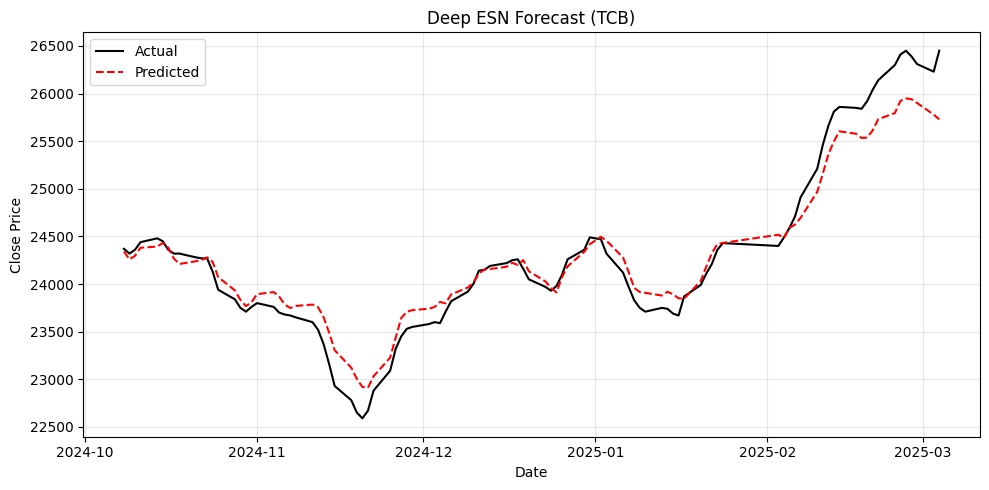


MÔ HÌNH 1: ARIMA  [TCB]
Grid search ARIMA order trên Val...
Best ARIMA order: (3, 1, 2), Val MAE: 893.64

ARIMA(3, 1, 2) — Test Metrics [TCB]:
  MAE  = 669.42
  RMSE = 917.68
  MAPE = 2.72%


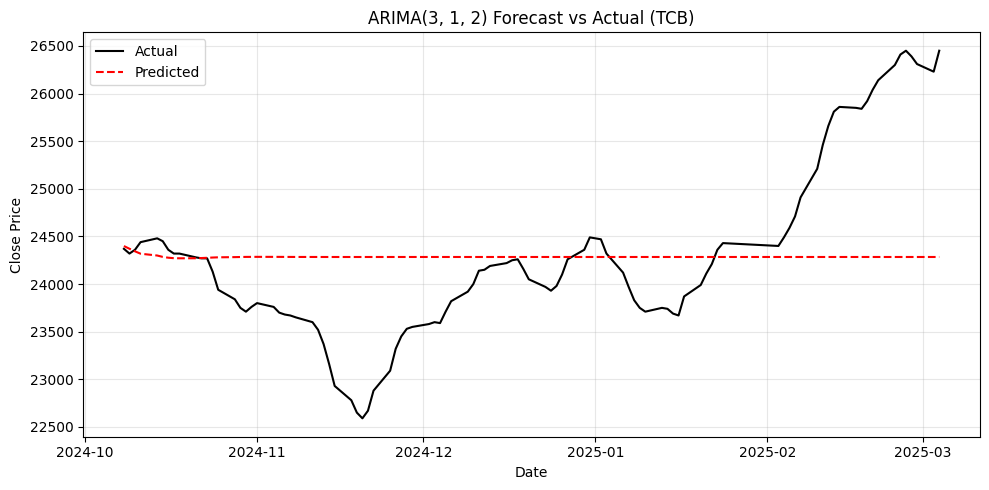


MÔ HÌNH 2: ESN TIÊU CHUẨN  [TCB]
Grid Search ESN: 625 combinations
Best ESN: n_res=50, sr=0.7, spa=0.1, alpha=0.0005
Val MAE (seed=42): 127.85

ESN tiêu chuẩn — Kết quả từng seed [TCB]
  Seed  789 → MAE=191.61, RMSE=229.18, MAPE=0.79%
  Seed   42 → MAE=195.54, RMSE=248.73, MAPE=0.79%
  Seed  456 → MAE=199.15, RMSE=271.07, MAPE=0.81%
  Seed 1234 → MAE=215.19, RMSE=251.40, MAPE=0.90%
  Seed  123 → MAE=223.58, RMSE=260.56, MAPE=0.92%
  Seed    0 → MAE=246.66, RMSE=280.85, MAPE=1.03%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [TCB]
  MAE  = 211.95 ± 19.14
  RMSE = 256.97 ± 16.60
  MAPE = 0.87% ± 0.09%


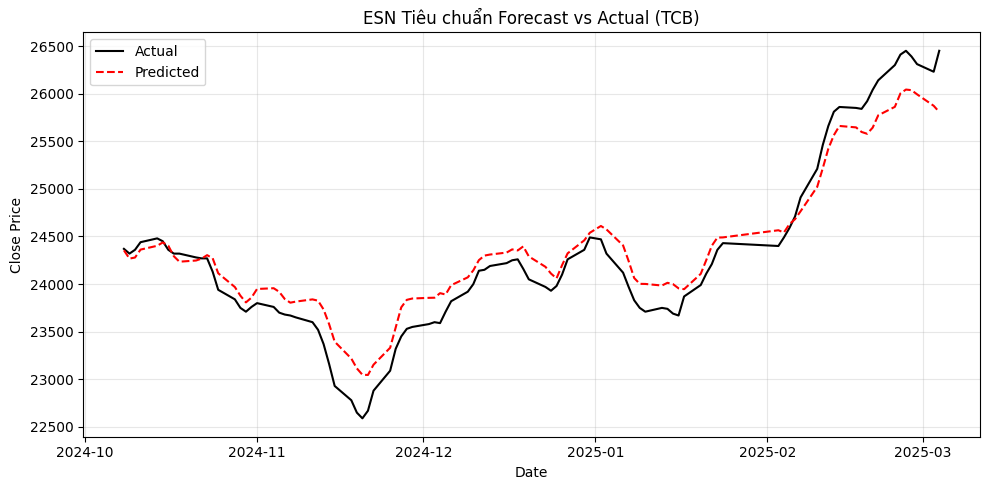


MÔ HÌNH 3: LSTM  [TCB]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=206.10
  units=40, drop=0.1, lr=0.005 → Val MAE=258.33


  units=40, drop=0.1, lr=0.01 → Val MAE=255.17
  units=40, drop=0.2, lr=0.001 → Val MAE=304.21
  units=40, drop=0.2, lr=0.005 → Val MAE=175.81
  units=40, drop=0.2, lr=0.01 → Val MAE=301.32
  units=40, drop=0.3, lr=0.001 → Val MAE=448.27
  units=40, drop=0.3, lr=0.005 → Val MAE=199.56
  units=40, drop=0.3, lr=0.01 → Val MAE=460.43
  units=48, drop=0.1, lr=0.001 → Val MAE=252.86
  units=48, drop=0.1, lr=0.005 → Val MAE=188.93
  units=48, drop=0.1, lr=0.01 → Val MAE=499.29
  units=48, drop=0.2, lr=0.001 → Val MAE=300.35
  units=48, drop=0.2, lr=0.005 → Val MAE=171.98
  units=48, drop=0.2, lr=0.01 → Val MAE=177.42
  units=48, drop=0.3, lr=0.001 → Val MAE=378.19
  units=48, drop=0.3, lr=0.005 → Val MAE=216.82
  units=48, drop=0.3, lr=0.01 → Val MAE=188.32
  units=50, drop=0.1, lr=0.001 → Val MAE=219.42
  units=50, drop=0.1, lr=0.005 → Val MAE=219.98
  units=50, drop=0.1, lr=0.01 → Val MAE=494.32
  units=50, drop=0.2, lr=0.001 → Val MAE=350.22
  units=50, drop=0.2, lr=0.005 → Val MAE=178.11

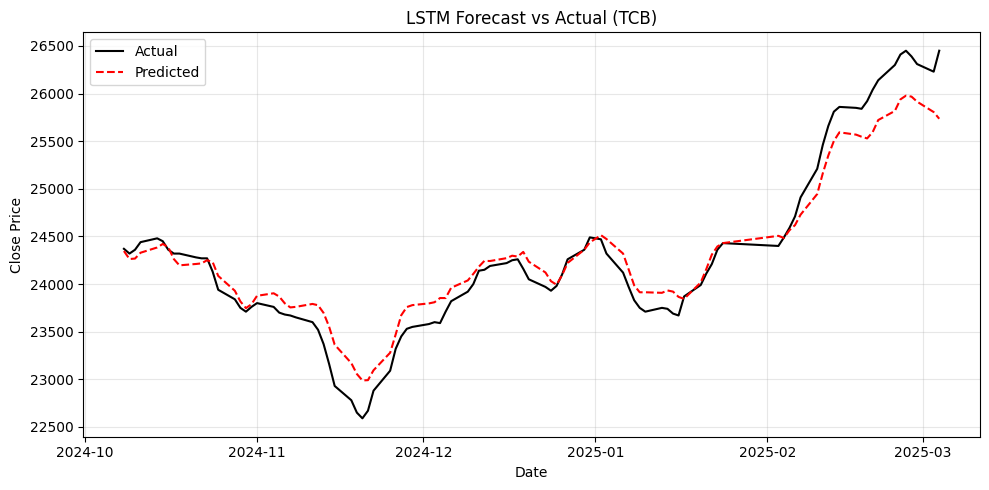


MÔ HÌNH 4: RANDOM FOREST  [TCB]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=214.10
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=228.59
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=215.62
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=222.72
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=203.57
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=225.01
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=213.83
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=221.08
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=167.72
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=171.71
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=198.66
  {'max_depth': 10, 'min_samples_split': 2, 

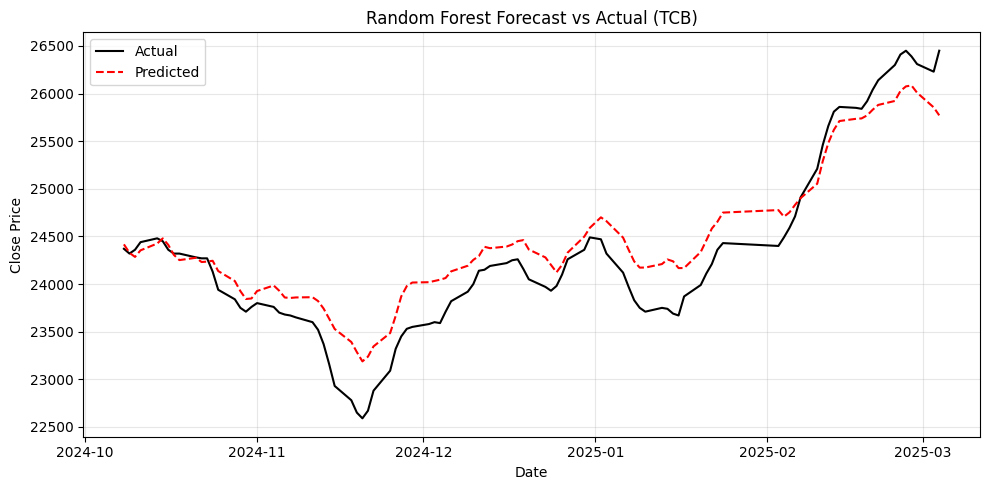


BẢNG SO SÁNH — TẬP TEST [TCB] (mean ± std, 6 seeds)
              Mô hình              MAE             RMSE       MAPE (%)
1  Deep ESN (đề xuất)   171.08 ± 19.09   228.62 ± 18.32  0.70% ± 0.08%
2      ESN tiêu chuẩn   211.95 ± 19.14   256.97 ± 16.60  0.87% ± 0.09%
3       Random Forest   269.53 ± 19.71   316.16 ± 19.98  1.12% ± 0.08%
4                LSTM  450.31 ± 285.05  542.90 ± 333.50  1.84% ± 1.16%
5      ARIMA(3, 1, 2)           669.42           917.68          2.72%


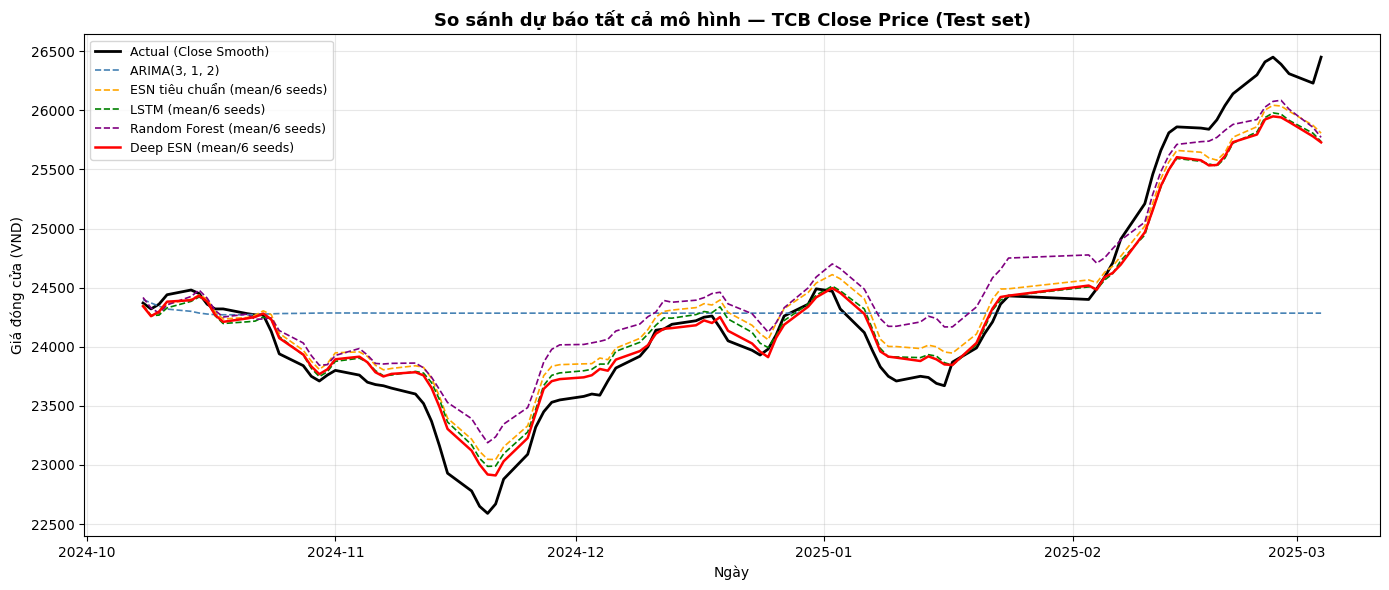


  PIPELINE: CTG  |  file: CTG.csv

Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)
Shapes — Train: (782, 10), Val: (99, 10), Test: (100, 10)
Anchor Train→Val : 22358.14
Anchor Val→Test  : 24861.42

MÔ HÌNH: DEEP ESN  [CTG]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=198.25
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=198.19
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=198.24
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=221.60
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=219.78
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=218.62

Best Deep ESN: n_res=50, n_layers=3, sr=0.75, spa=0.1, alpha=0.0005
Val MAE: 134.87

Deep ESN — Kết quả từng seed [CTG]
  Seed 1234 → MAE=185.72, RMSE=237.9

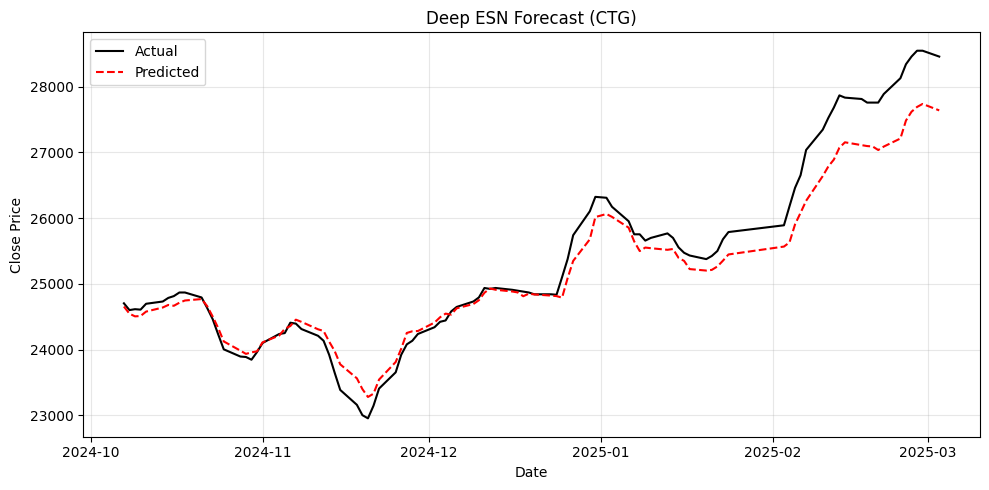


MÔ HÌNH 1: ARIMA  [CTG]
Grid search ARIMA order trên Val...
Best ARIMA order: (2, 1, 2), Val MAE: 846.87

ARIMA(2, 1, 2) — Test Metrics [CTG]:
  MAE  = 1241.36
  RMSE = 1740.34
  MAPE = 4.69%


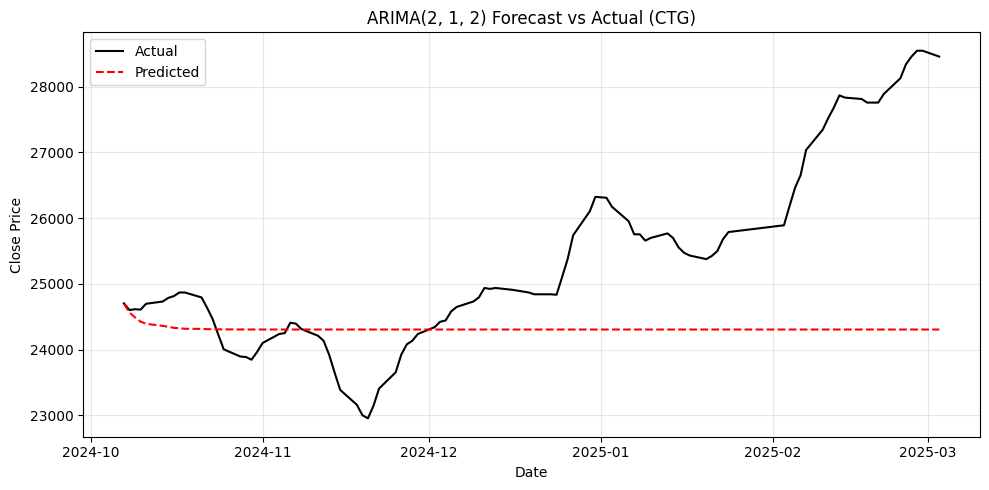


MÔ HÌNH 2: ESN TIÊU CHUẨN  [CTG]
Grid Search ESN: 625 combinations
Best ESN: n_res=70, sr=0.73, spa=0.09, alpha=0.0005
Val MAE (seed=42): 174.60

ESN tiêu chuẩn — Kết quả từng seed [CTG]
  Seed  123 → MAE=255.66, RMSE=355.36, MAPE=0.97%
  Seed   42 → MAE=285.53, RMSE=398.72, MAPE=1.08%
  Seed    0 → MAE=288.42, RMSE=405.13, MAPE=1.09%
  Seed 1234 → MAE=314.71, RMSE=437.23, MAPE=1.19%
  Seed  789 → MAE=324.09, RMSE=419.84, MAPE=1.23%
  Seed  456 → MAE=332.72, RMSE=442.78, MAPE=1.26%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [CTG]
  MAE  = 300.19 ± 26.38
  RMSE = 409.84 ± 29.01
  MAPE = 1.14% ± 0.10%


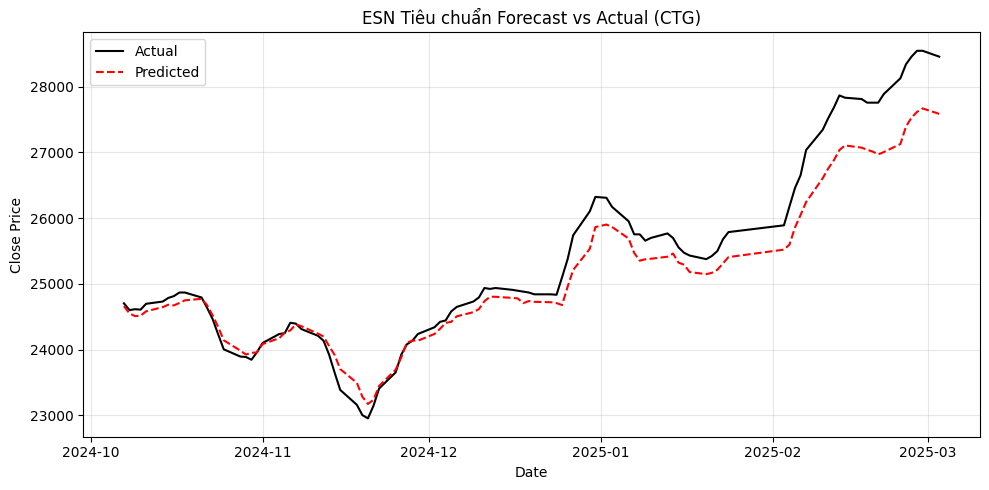


MÔ HÌNH 3: LSTM  [CTG]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=354.48
  units=40, drop=0.1, lr=0.005 → Val MAE=380.13
  units=40, drop=0.1, lr=0.01 → Val MAE=599.00
  units=40, drop=0.2, lr=0.001 → Val MAE=259.35
  units=40, drop=0.2, lr=0.005 → Val MAE=321.54
  units=40, drop=0.2, lr=0.01 → Val MAE=342.84
  units=40, drop=0.3, lr=0.001 → Val MAE=420.81
  units=40, drop=0.3, lr=0.005 → Val MAE=493.76
  units=40, drop=0.3, lr=0.01 → Val MAE=279.14
  units=48, drop=0.1, lr=0.001 → Val MAE=297.10
  units=48, drop=0.1, lr=0.005 → Val MAE=274.24
  units=48, drop=0.1, lr=0.01 → Val MAE=307.58
  units=48, drop=0.2, lr=0.001 → Val MAE=277.12
  units=48, drop=0.2, lr=0.005 → Val MAE=292.52
  units=48, drop=0.2, lr=0.01 → Val MAE=322.26
  units=48, drop=0.3, lr=0.001 → Val MAE=281.09
  units=48, drop=0.3, lr=0.005 → Val MAE=450.77
  units=48, drop=0.3, lr=0.01 → Val MAE=625.49
  units=50, drop=0.1, lr=0.001 → Val MAE=374.82
  units=50, drop=0.1, lr=0.005 → Val MAE=399.94
  

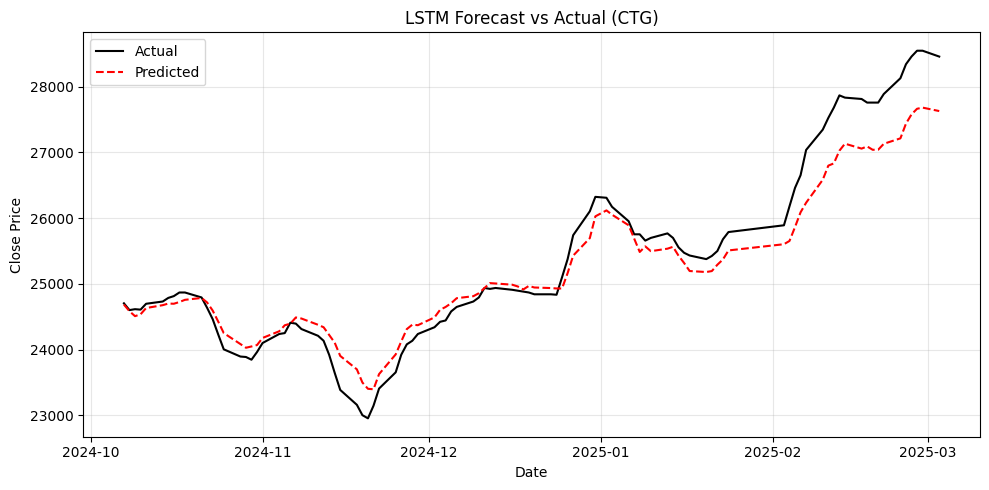


MÔ HÌNH 4: RANDOM FOREST  [CTG]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=248.11
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=249.11
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=237.12
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=238.20
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=246.66
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=249.99
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=237.09
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=237.24
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=283.87
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=253.04
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=243.54
  {'max_depth': 10, 'min_samples_split': 2, 

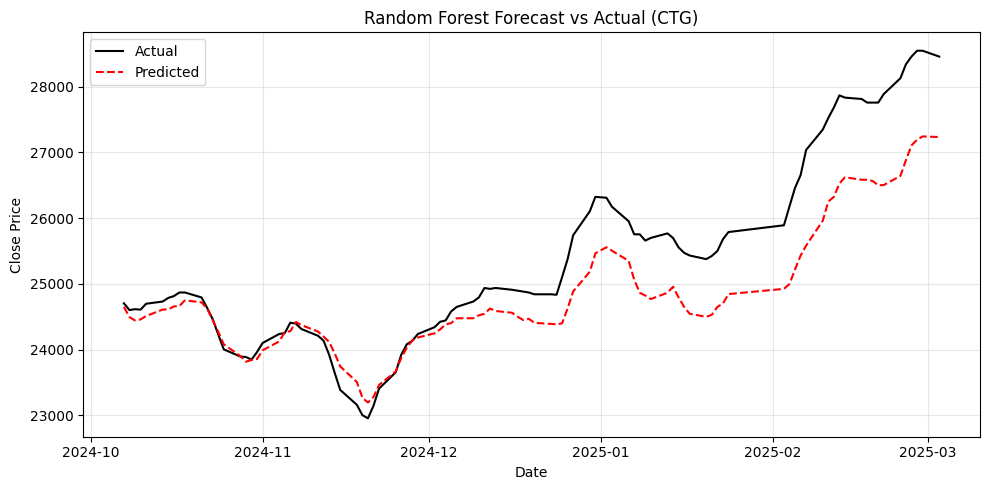


BẢNG SO SÁNH — TẬP TEST [CTG] (mean ± std, 6 seeds)
              Mô hình              MAE             RMSE       MAPE (%)
1  Deep ESN (đề xuất)   276.15 ± 51.13   386.10 ± 81.69  1.05% ± 0.19%
2      ESN tiêu chuẩn   300.19 ± 26.38   409.84 ± 29.01  1.14% ± 0.10%
3       Random Forest   547.89 ± 31.93   727.38 ± 42.35  2.08% ± 0.12%
4                LSTM  600.81 ± 248.79  753.55 ± 335.68  2.32% ± 0.93%
5      ARIMA(2, 1, 2)          1241.36          1740.34          4.69%


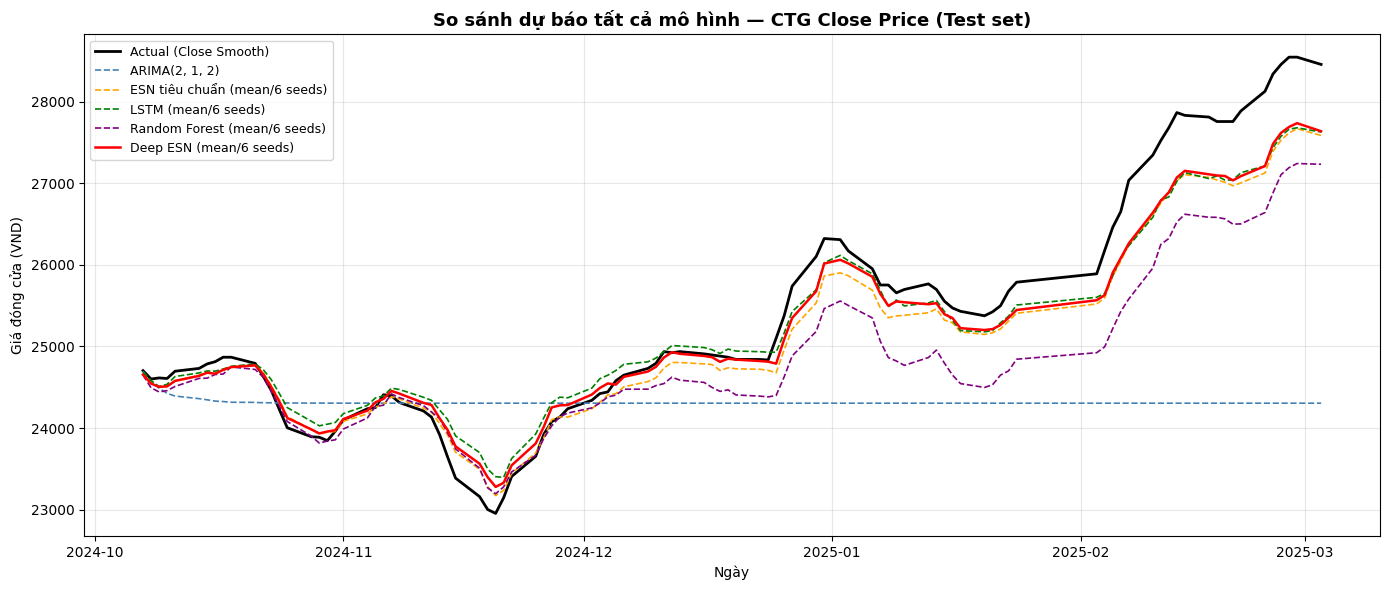


  PIPELINE: CTS  |  file: CTS.csv

Train : 776 ngày (2021-04-14 → 2024-05-24)
Val   : 97 ngày (2024-05-27 → 2024-10-10)
Test  : 97 ngày (2024-10-11 → 2025-03-04)
Shapes — Train: (766, 10), Val: (97, 10), Test: (97, 10)
Anchor Train→Val : 43110.00
Anchor Val→Test  : 40110.00

MÔ HÌNH: DEEP ESN  [CTS]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=555.00
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=554.73
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=555.61
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=593.12
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=650.96
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=695.07

Best Deep ESN: n_res=40, n_layers=2, sr=0.72, spa=0.12, alpha=0.003
Val MAE: 329.27

Deep ESN — Kết quả từng seed [CTS]
  Seed  456 → MAE=1164.33, RMSE=1265.5

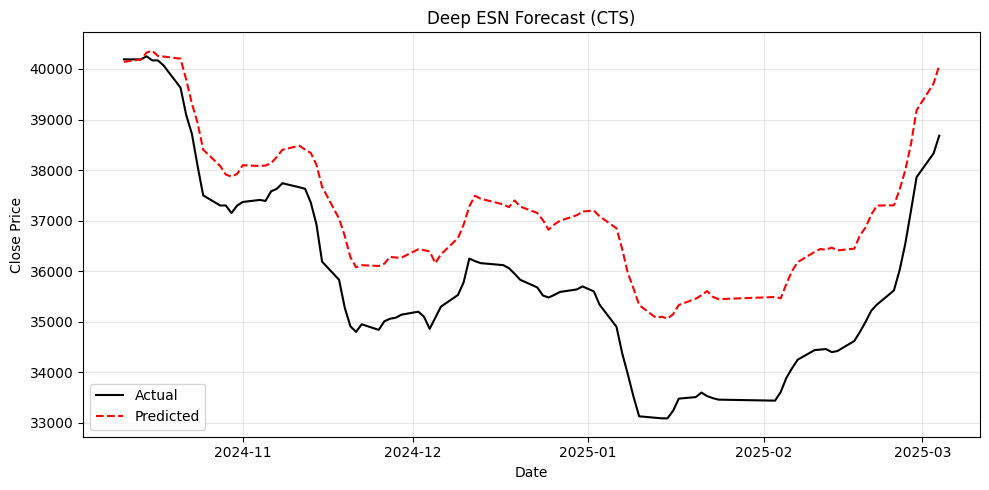


MÔ HÌNH 1: ARIMA  [CTS]
Grid search ARIMA order trên Val...
Best ARIMA order: (2, 1, 1), Val MAE: 2798.36

ARIMA(2, 1, 1) — Test Metrics [CTS]:
  MAE  = 4361.29
  RMSE = 4741.33
  MAPE = 12.45%


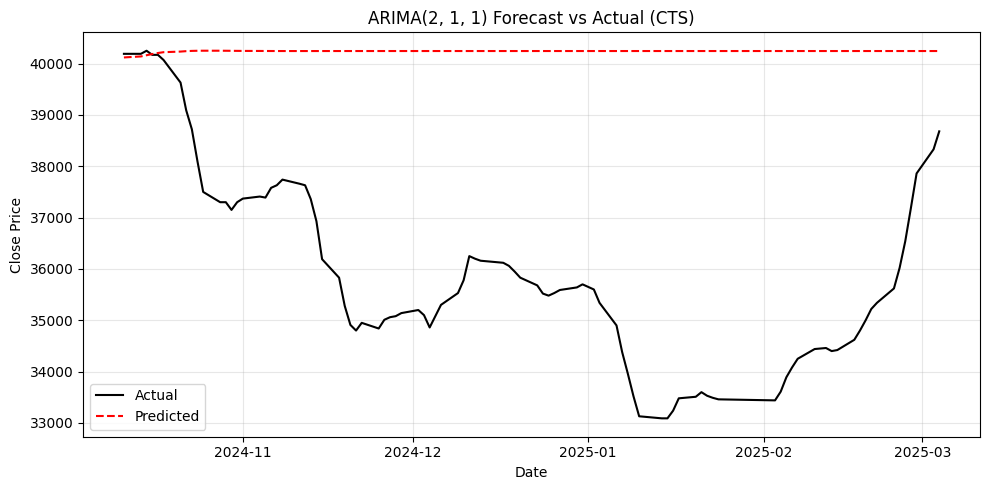


MÔ HÌNH 2: ESN TIÊU CHUẨN  [CTS]
Grid Search ESN: 625 combinations
Best ESN: n_res=60, sr=0.77, spa=0.15, alpha=0.001
Val MAE (seed=42): 417.19

ESN tiêu chuẩn — Kết quả từng seed [CTS]
  Seed 1234 → MAE=1124.13, RMSE=1211.74, MAPE=3.20%
  Seed  456 → MAE=1348.73, RMSE=1457.44, MAPE=3.84%
  Seed    0 → MAE=1378.83, RMSE=1492.25, MAPE=3.93%
  Seed  123 → MAE=1394.48, RMSE=1495.79, MAPE=3.97%
  Seed  789 → MAE=1510.90, RMSE=1636.21, MAPE=4.30%
  Seed   42 → MAE=1772.60, RMSE=1913.29, MAPE=5.04%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [CTS]
  MAE  = 1421.61 ± 194.74
  RMSE = 1534.45 ± 211.04
  MAPE = 4.05% ± 0.55%


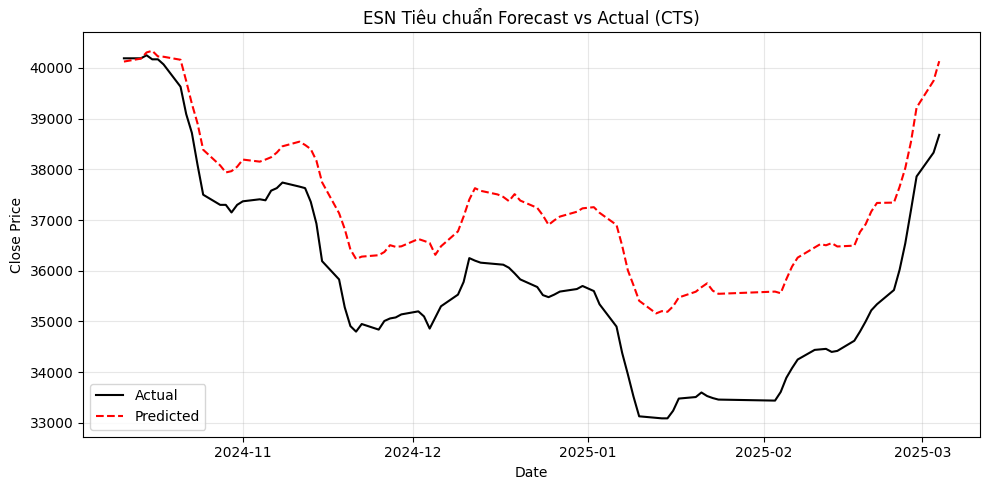


MÔ HÌNH 3: LSTM  [CTS]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=1486.77
  units=40, drop=0.1, lr=0.005 → Val MAE=2495.82
  units=40, drop=0.1, lr=0.01 → Val MAE=1038.16
  units=40, drop=0.2, lr=0.001 → Val MAE=898.44
  units=40, drop=0.2, lr=0.005 → Val MAE=1633.15
  units=40, drop=0.2, lr=0.01 → Val MAE=512.06
  units=40, drop=0.3, lr=0.001 → Val MAE=561.81
  units=40, drop=0.3, lr=0.005 → Val MAE=1594.06
  units=40, drop=0.3, lr=0.01 → Val MAE=1573.19
  units=48, drop=0.1, lr=0.001 → Val MAE=1493.84
  units=48, drop=0.1, lr=0.005 → Val MAE=2423.17
  units=48, drop=0.1, lr=0.01 → Val MAE=819.73
  units=48, drop=0.2, lr=0.001 → Val MAE=1352.31
  units=48, drop=0.2, lr=0.005 → Val MAE=1383.48
  units=48, drop=0.2, lr=0.01 → Val MAE=1169.03
  units=48, drop=0.3, lr=0.001 → Val MAE=1237.33
  units=48, drop=0.3, lr=0.005 → Val MAE=1391.14
  units=48, drop=0.3, lr=0.01 → Val MAE=997.77
  units=50, drop=0.1, lr=0.001 → Val MAE=1465.59
  units=50, drop=0.1, lr=0.005 → Val

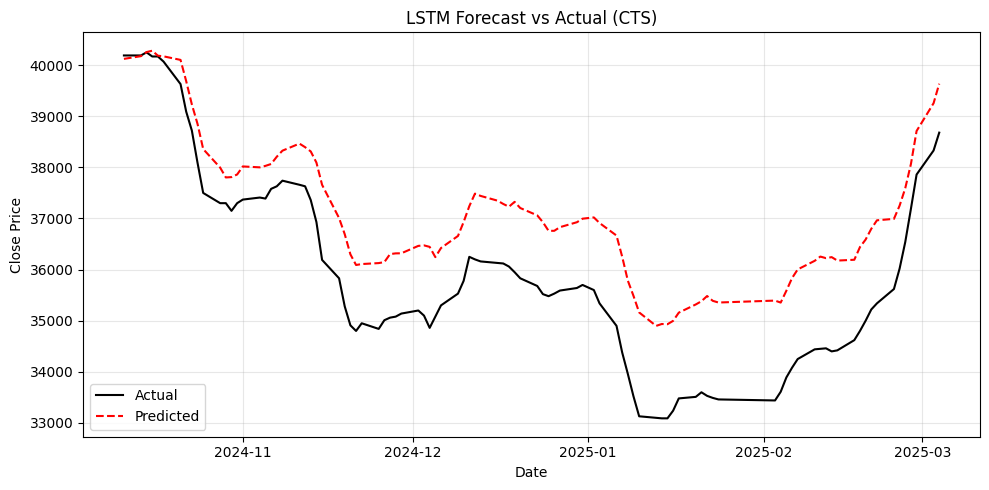


MÔ HÌNH 4: RANDOM FOREST  [CTS]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=933.76
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=997.10
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=993.74
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=997.76
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=960.44
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=1012.83
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=999.10
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=997.25
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=1255.50
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=1215.06
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=1154.83
  {'max_depth': 10, 'min_samples_split':

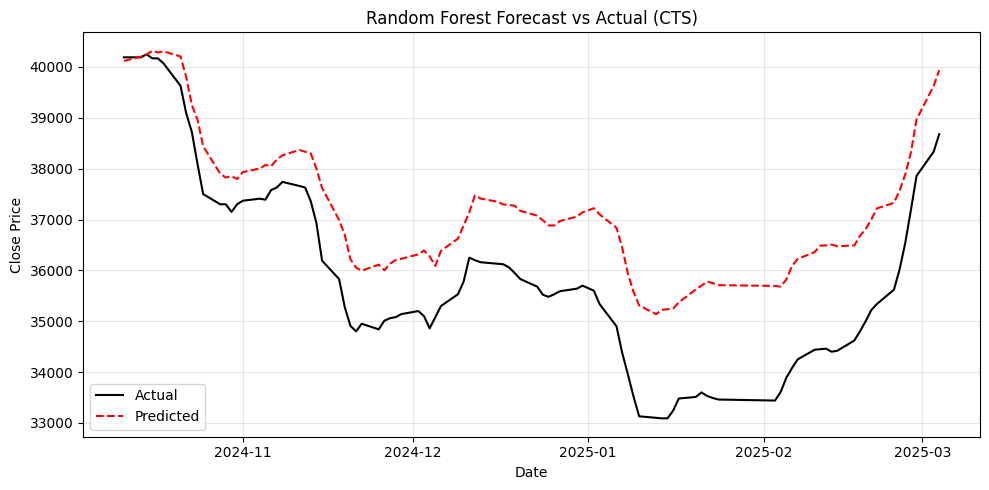


BẢNG SO SÁNH — TẬP TEST [CTS] (mean ± std, 6 seeds)
              Mô hình               MAE              RMSE       MAPE (%)
1       Random Forest  1319.64 ± 171.63  1450.46 ± 185.68  3.76% ± 0.49%
2  Deep ESN (đề xuất)  1337.30 ± 142.29  1449.50 ± 155.06  3.81% ± 0.40%
3      ESN tiêu chuẩn  1421.61 ± 194.74  1534.45 ± 211.04  4.05% ± 0.55%
4                LSTM  1890.49 ± 618.30  2132.60 ± 705.98  5.38% ± 1.76%
5      ARIMA(2, 1, 1)           4361.29           4741.33         12.45%


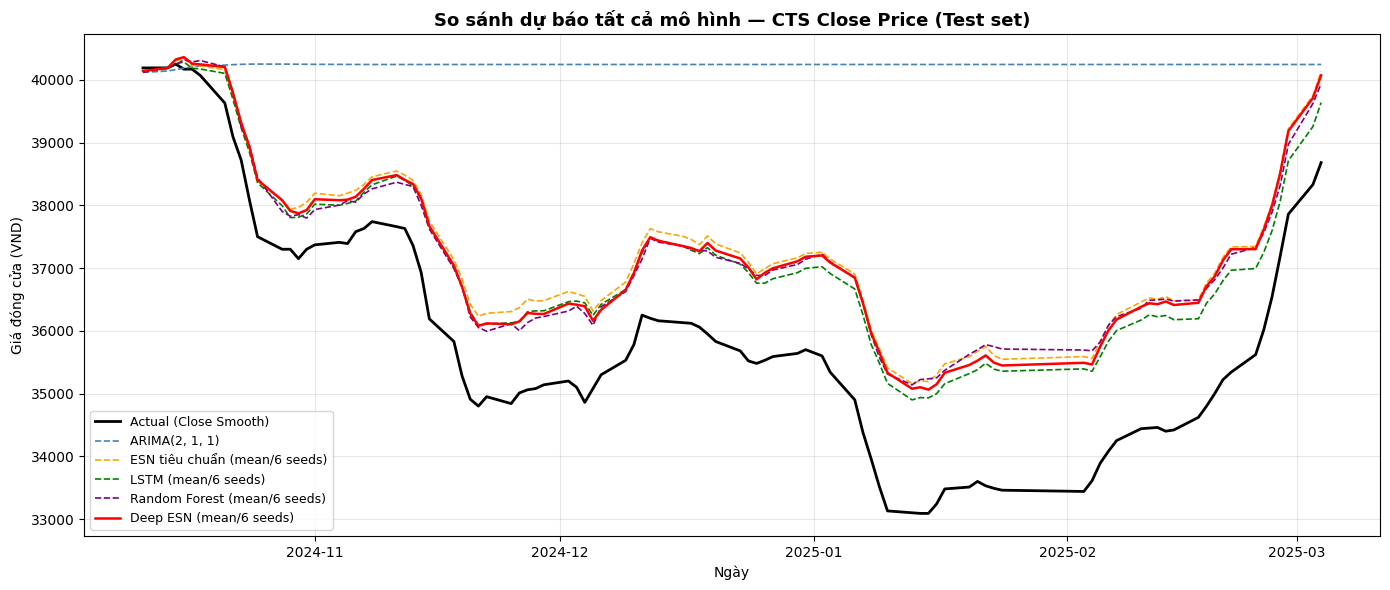


  PIPELINE: FPT  |  file: FPT.xlsx

Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 99421.74
Anchor Val→Test  : 97023.59

MÔ HÌNH: DEEP ESN  [FPT]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=1131.55
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=1125.80
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=1114.34
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=3762.00
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=3513.13
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=3309.11

Best Deep ESN: n_res=45, n_layers=2, sr=0.75, spa=0.09, alpha=0.0005
Val MAE: 600.69

Deep ESN — Kết quả từng seed [FPT]
  Seed  456 → MAE=763.42, 

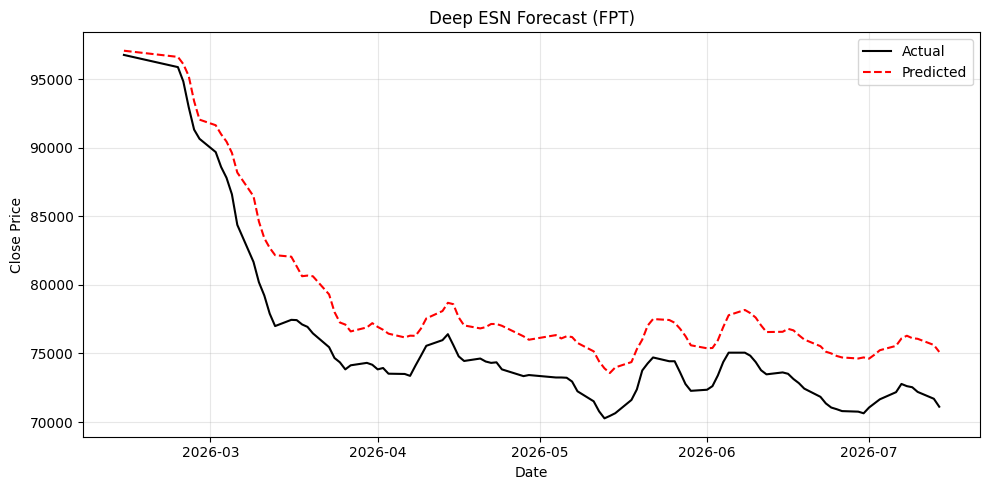


MÔ HÌNH 1: ARIMA  [FPT]
Grid search ARIMA order trên Val...
Best ARIMA order: (1, 1, 0), Val MAE: 3274.51

ARIMA(1, 1, 0) — Test Metrics [FPT]:
  MAE  = 21309.46
  RMSE = 22098.13
  MAPE = 28.83%


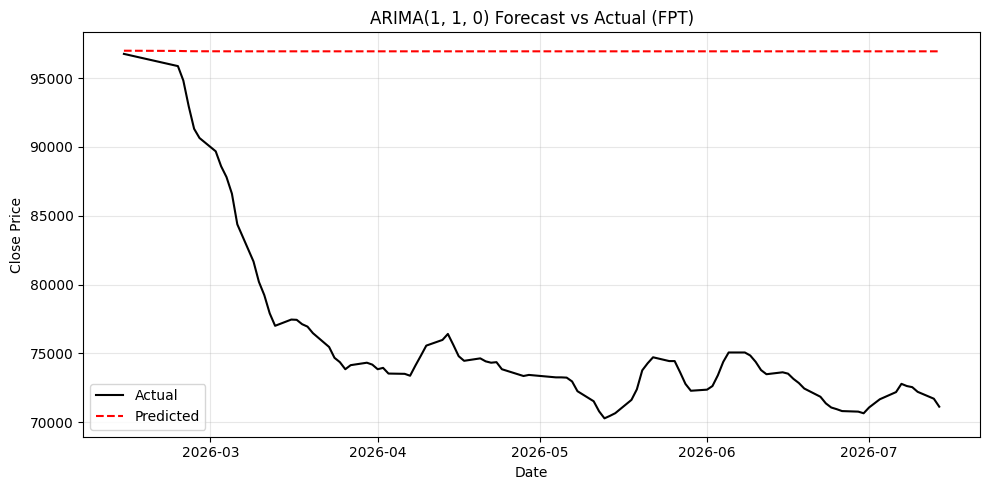


MÔ HÌNH 2: ESN TIÊU CHUẨN  [FPT]
Grid Search ESN: 625 combinations
Best ESN: n_res=70, sr=0.77, spa=0.15, alpha=0.0005
Val MAE (seed=42): 681.27

ESN tiêu chuẩn — Kết quả từng seed [FPT]
  Seed  789 → MAE=2501.98, RMSE=2605.24, MAPE=3.35%
  Seed  456 → MAE=2767.52, RMSE=2865.99, MAPE=3.70%
  Seed    0 → MAE=3385.15, RMSE=3589.05, MAPE=4.57%
  Seed  123 → MAE=3994.94, RMSE=4097.40, MAPE=5.37%
  Seed   42 → MAE=5730.36, RMSE=5901.60, MAPE=7.73%
  Seed 1234 → MAE=7057.73, RMSE=7333.61, MAPE=9.55%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [FPT]
  MAE  = 4239.61 ± 1640.15
  RMSE = 4398.81 ± 1692.36
  MAPE = 5.71% ± 2.23%


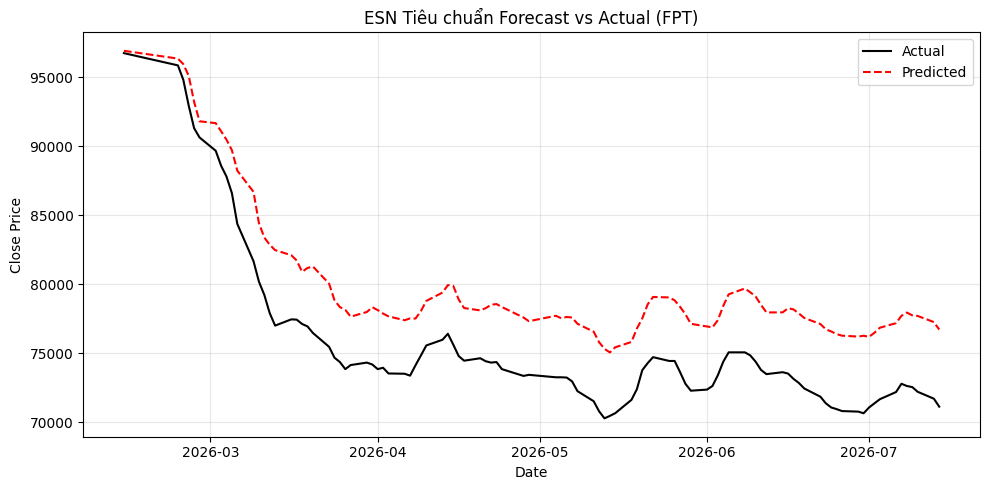


MÔ HÌNH 3: LSTM  [FPT]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=1008.22
  units=40, drop=0.1, lr=0.005 → Val MAE=1312.13
  units=40, drop=0.1, lr=0.01 → Val MAE=2489.73
  units=40, drop=0.2, lr=0.001 → Val MAE=1190.60
  units=40, drop=0.2, lr=0.005 → Val MAE=2369.82
  units=40, drop=0.2, lr=0.01 → Val MAE=2806.65
  units=40, drop=0.3, lr=0.001 → Val MAE=1339.21
  units=40, drop=0.3, lr=0.005 → Val MAE=1509.59
  units=40, drop=0.3, lr=0.01 → Val MAE=1510.08
  units=48, drop=0.1, lr=0.001 → Val MAE=1180.34
  units=48, drop=0.1, lr=0.005 → Val MAE=1843.84
  units=48, drop=0.1, lr=0.01 → Val MAE=2977.86
  units=48, drop=0.2, lr=0.001 → Val MAE=1051.57
  units=48, drop=0.2, lr=0.005 → Val MAE=940.39
  units=48, drop=0.2, lr=0.01 → Val MAE=1705.50
  units=48, drop=0.3, lr=0.001 → Val MAE=1096.77
  units=48, drop=0.3, lr=0.005 → Val MAE=1693.74
  units=48, drop=0.3, lr=0.01 → Val MAE=831.51
  units=50, drop=0.1, lr=0.001 → Val MAE=1019.25
  units=50, drop=0.1, lr=0.005 → 

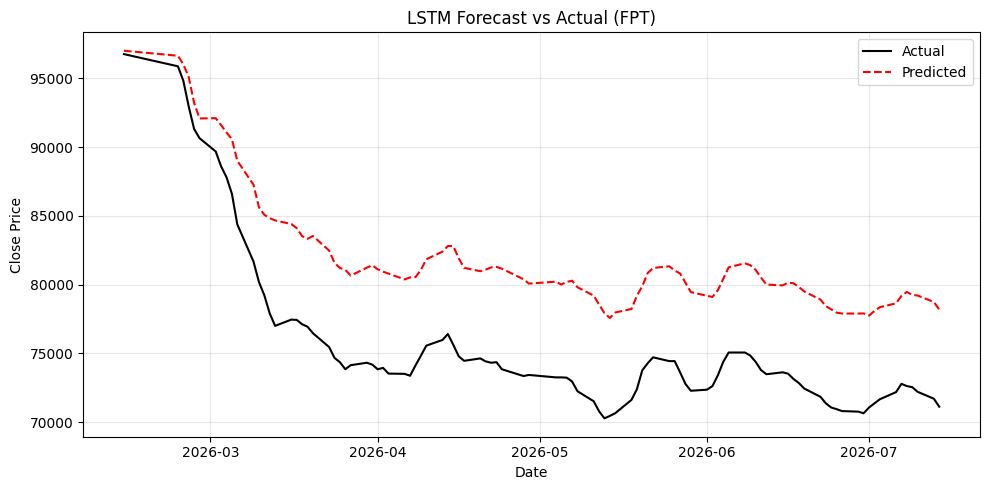


MÔ HÌNH 4: RANDOM FOREST  [FPT]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=829.92
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=893.13
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=938.02
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=939.93
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=830.08
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=864.90
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=905.20
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=922.07
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=870.64
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=871.35
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=860.86
  {'max_depth': 10, 'min_samples_split': 2, 

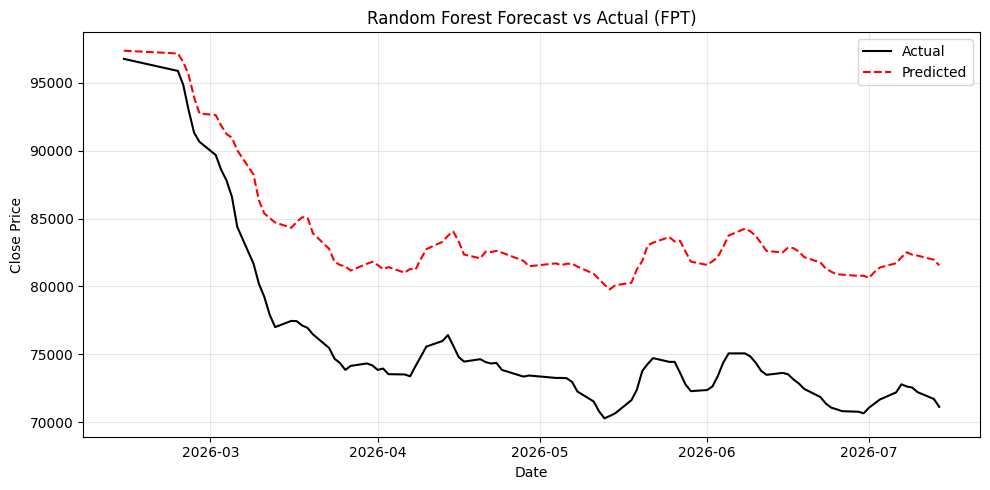


BẢNG SO SÁNH — TẬP TEST [FPT] (mean ± std, 6 seeds)
              Mô hình                MAE               RMSE        MAPE (%)
1  Deep ESN (đề xuất)  3199.86 ± 1573.28  3391.00 ± 1509.07   4.29% ± 2.14%
2      ESN tiêu chuẩn  4239.61 ± 1640.15  4398.81 ± 1692.36   5.71% ± 2.23%
3                LSTM  6459.89 ± 3131.45  6827.04 ± 3274.49   8.72% ± 4.28%
4       Random Forest   7972.05 ± 278.70   8253.01 ± 292.63  10.77% ± 0.38%
5      ARIMA(1, 1, 0)           21309.46           22098.13          28.83%


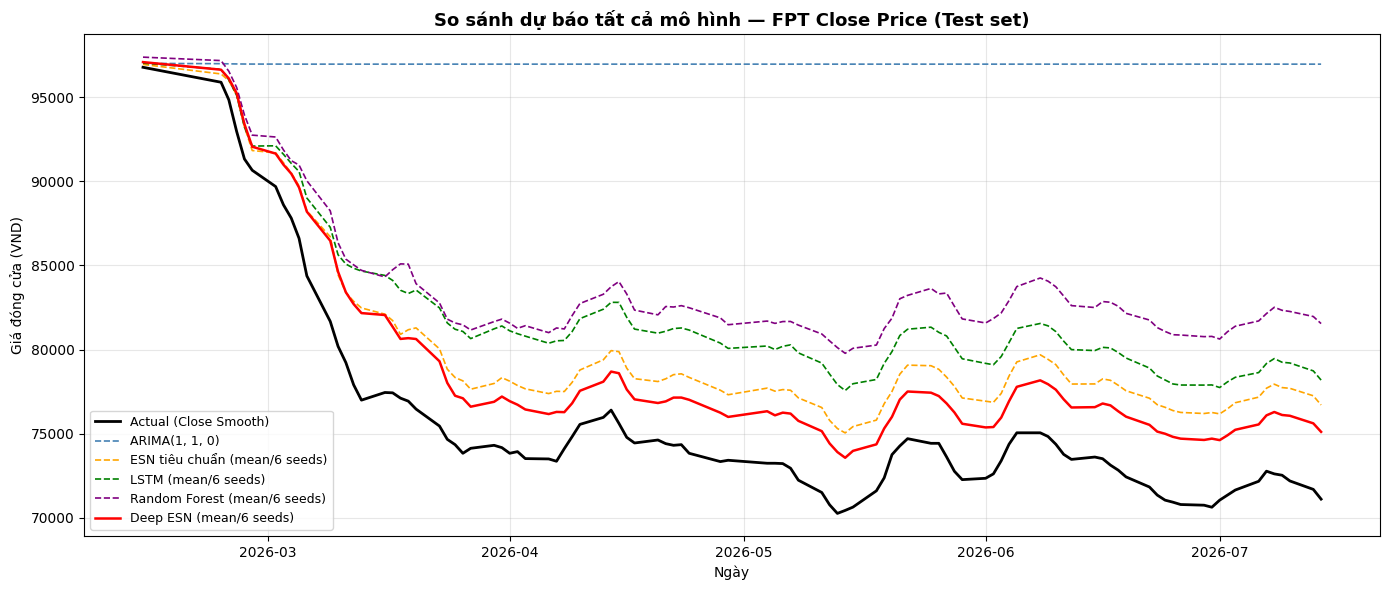


  PIPELINE: PAN  |  file: PAN.xlsx

Train : 800 ngày (2022-07-14 → 2025-09-26)
Val   : 100 ngày (2025-09-29 → 2026-02-24)
Test  : 100 ngày (2026-02-25 → 2026-07-17)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 25166.59
Anchor Val→Test  : 23992.71

MÔ HÌNH: DEEP ESN  [PAN]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=755.28
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=758.27
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=762.54
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=1788.94
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=1712.57
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=1663.74

Best Deep ESN: n_res=45, n_layers=3, sr=0.75, spa=0.07, alpha=0.0005
Val MAE: 197.25

Deep ESN — Kết quả từng seed [PAN]
  Seed  456 → MAE=189.90, RMS

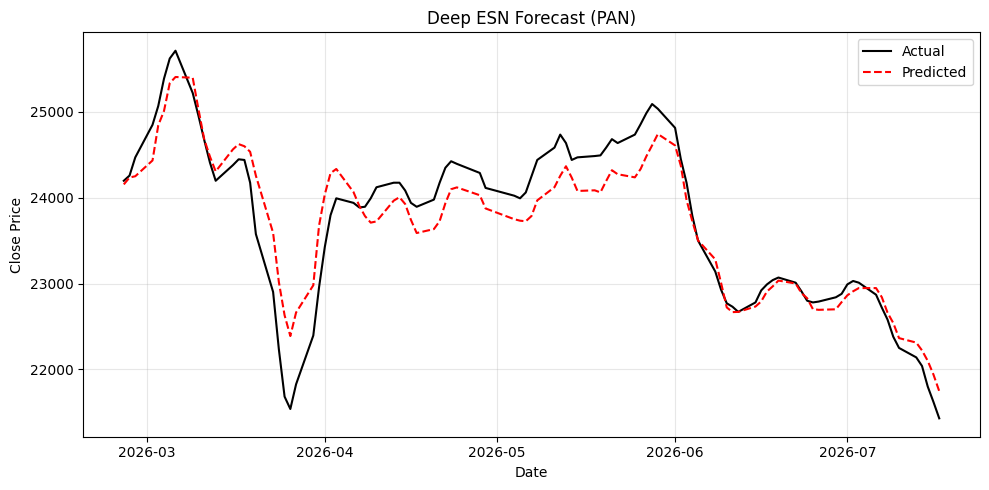


MÔ HÌNH 1: ARIMA  [PAN]
Grid search ARIMA order trên Val...
Best ARIMA order: (1, 1, 0), Val MAE: 2368.25

ARIMA(1, 1, 0) — Test Metrics [PAN]:
  MAE  = 1018.58
  RMSE = 1334.70
  MAPE = 4.44%


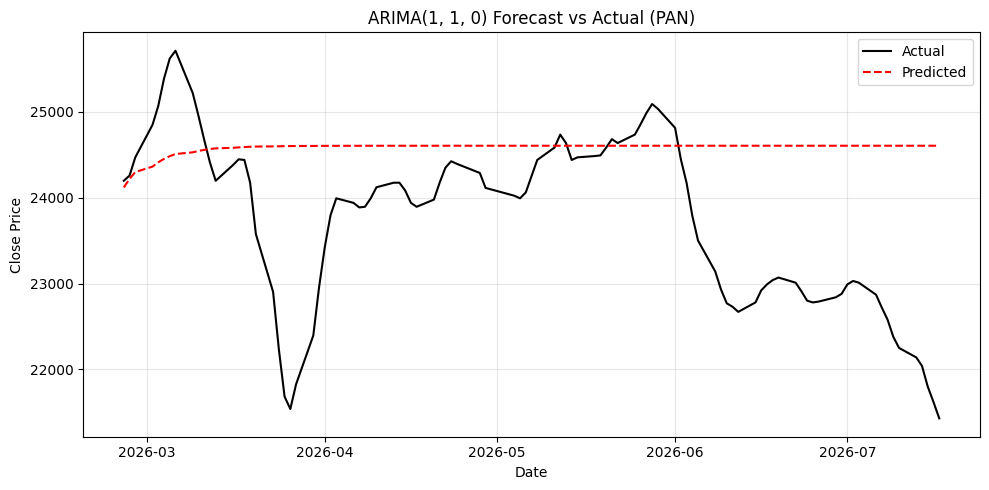


MÔ HÌNH 2: ESN TIÊU CHUẨN  [PAN]
Grid Search ESN: 625 combinations
Best ESN: n_res=60, sr=0.8, spa=0.15, alpha=0.0005
Val MAE (seed=42): 168.27

ESN tiêu chuẩn — Kết quả từng seed [PAN]
  Seed  123 → MAE=242.68, RMSE=285.01, MAPE=1.02%
  Seed  456 → MAE=339.02, RMSE=406.38, MAPE=1.42%
  Seed   42 → MAE=514.87, RMSE=587.94, MAPE=2.17%
  Seed 1234 → MAE=522.13, RMSE=599.37, MAPE=2.19%
  Seed  789 → MAE=554.20, RMSE=618.88, MAPE=2.33%
  Seed    0 → MAE=665.82, RMSE=755.24, MAPE=2.79%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [PAN]
  MAE  = 473.12 ± 140.79
  RMSE = 542.14 ± 153.42
  MAPE = 1.98% ± 0.59%


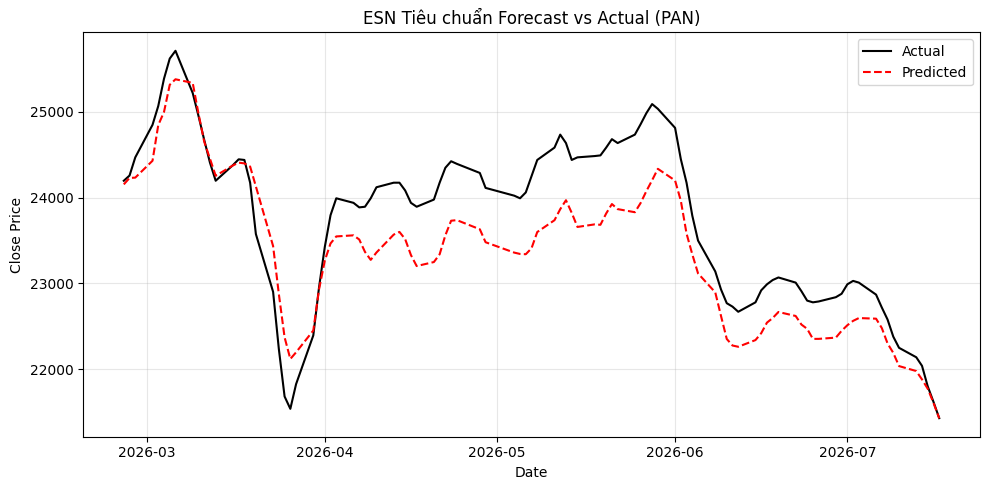


MÔ HÌNH 3: LSTM  [PAN]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=787.44
  units=40, drop=0.1, lr=0.005 → Val MAE=2062.89
  units=40, drop=0.1, lr=0.01 → Val MAE=1344.23
  units=40, drop=0.2, lr=0.001 → Val MAE=931.35
  units=40, drop=0.2, lr=0.005 → Val MAE=979.19
  units=40, drop=0.2, lr=0.01 → Val MAE=1147.94
  units=40, drop=0.3, lr=0.001 → Val MAE=1159.66
  units=40, drop=0.3, lr=0.005 → Val MAE=1207.74
  units=40, drop=0.3, lr=0.01 → Val MAE=1360.29
  units=48, drop=0.1, lr=0.001 → Val MAE=1279.83
  units=48, drop=0.1, lr=0.005 → Val MAE=1841.86
  units=48, drop=0.1, lr=0.01 → Val MAE=1378.49
  units=48, drop=0.2, lr=0.001 → Val MAE=825.58
  units=48, drop=0.2, lr=0.005 → Val MAE=1299.27
  units=48, drop=0.2, lr=0.01 → Val MAE=892.53
  units=48, drop=0.3, lr=0.001 → Val MAE=816.23
  units=48, drop=0.3, lr=0.005 → Val MAE=1108.99
  units=48, drop=0.3, lr=0.01 → Val MAE=927.25
  units=50, drop=0.1, lr=0.001 → Val MAE=995.61
  units=50, drop=0.1, lr=0.005 → Val MA

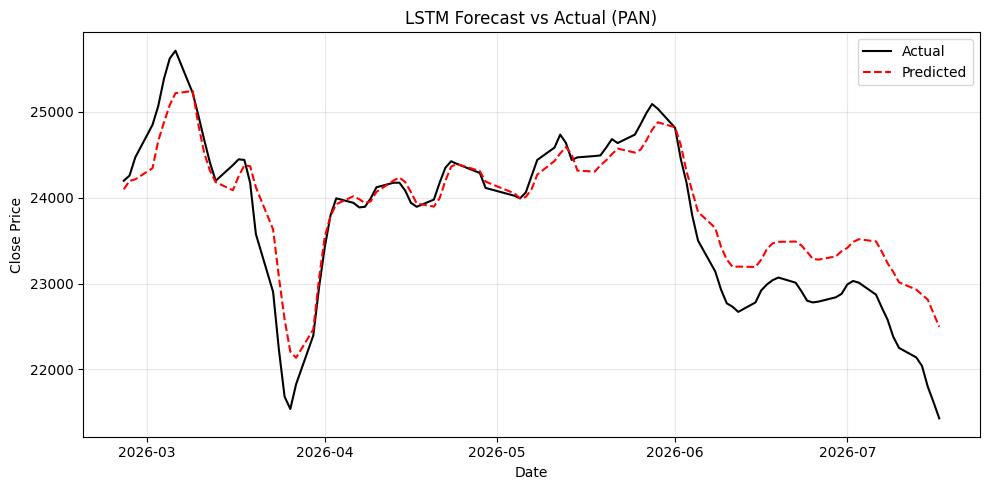


MÔ HÌNH 4: RANDOM FOREST  [PAN]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=721.85
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=679.27
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=648.42
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=664.74
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=704.26
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=675.57
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=660.60
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=676.80
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=735.59
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=691.94
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=691.66
  {'max_depth': 10, 'min_samples_split': 2, 

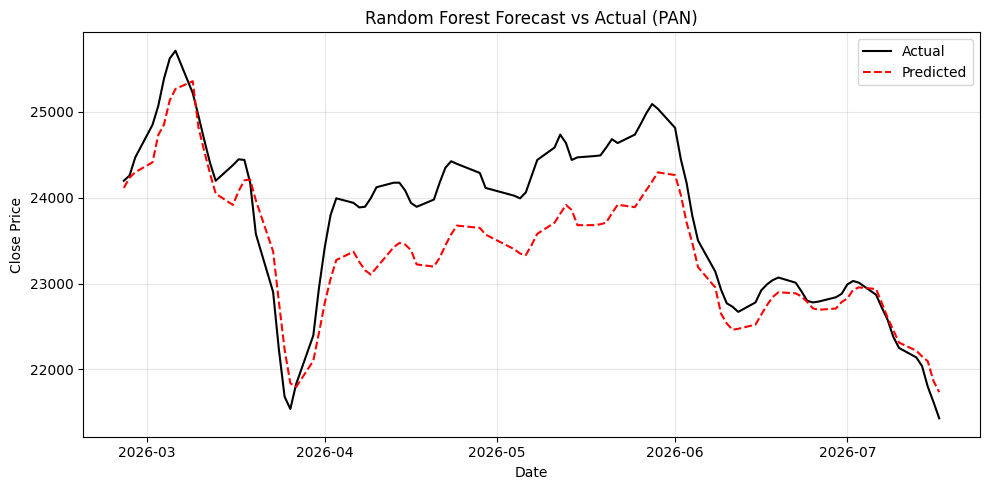


BẢNG SO SÁNH — TẬP TEST [PAN] (mean ± std, 6 seeds)
              Mô hình              MAE             RMSE       MAPE (%)
1  Deep ESN (đề xuất)  342.76 ± 158.75  417.14 ± 164.47  1.46% ± 0.66%
2       Random Forest   444.25 ± 24.33   533.21 ± 28.77  1.85% ± 0.10%
3      ESN tiêu chuẩn  473.12 ± 140.79  542.14 ± 153.42  1.98% ± 0.59%
4                LSTM  688.14 ± 391.80  816.26 ± 445.34  2.94% ± 1.69%
5      ARIMA(1, 1, 0)          1018.58          1334.70          4.44%


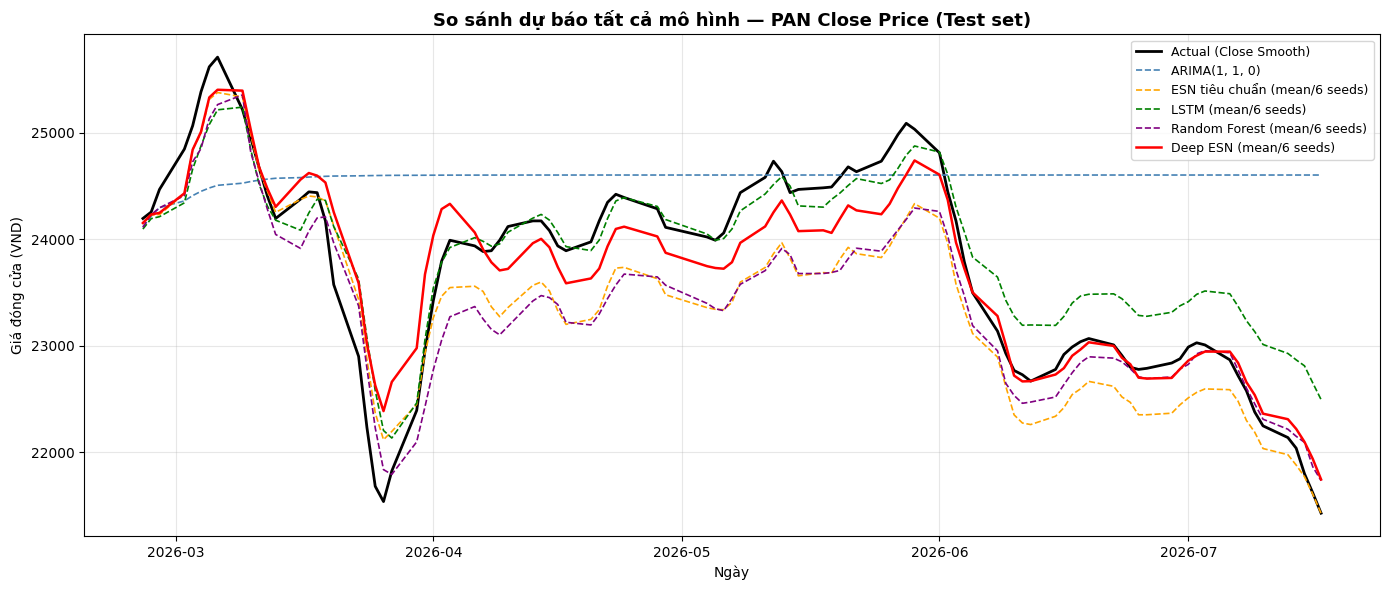


  PIPELINE: DIG  |  file: DIG.xlsx

Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 22235.47
Anchor Val→Test  : 15620.00

MÔ HÌNH: DEEP ESN  [DIG]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=354.17
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=352.22
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=349.74
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=679.27
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=727.35
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=763.26

Best Deep ESN: n_res=40, n_layers=3, sr=0.75, spa=0.1, alpha=0.0005
Val MAE: 321.23

Deep ESN — Kết quả từng seed [DIG]
  Seed   42 → MAE=140.41, RMSE=17

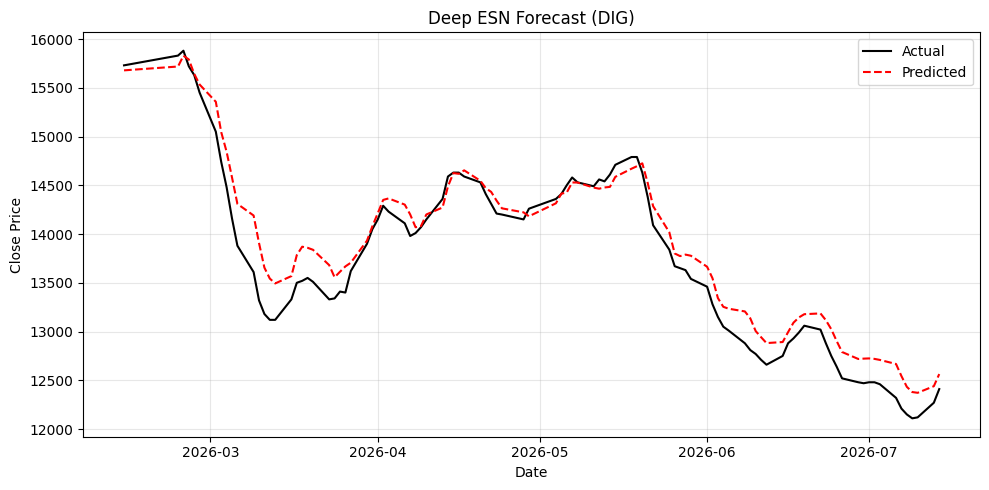


MÔ HÌNH 1: ARIMA  [DIG]
Grid search ARIMA order trên Val...
Best ARIMA order: (1, 1, 0), Val MAE: 2985.38

ARIMA(1, 1, 0) — Test Metrics [DIG]:
  MAE  = 1829.07
  RMSE = 2030.16
  MAPE = 13.80%


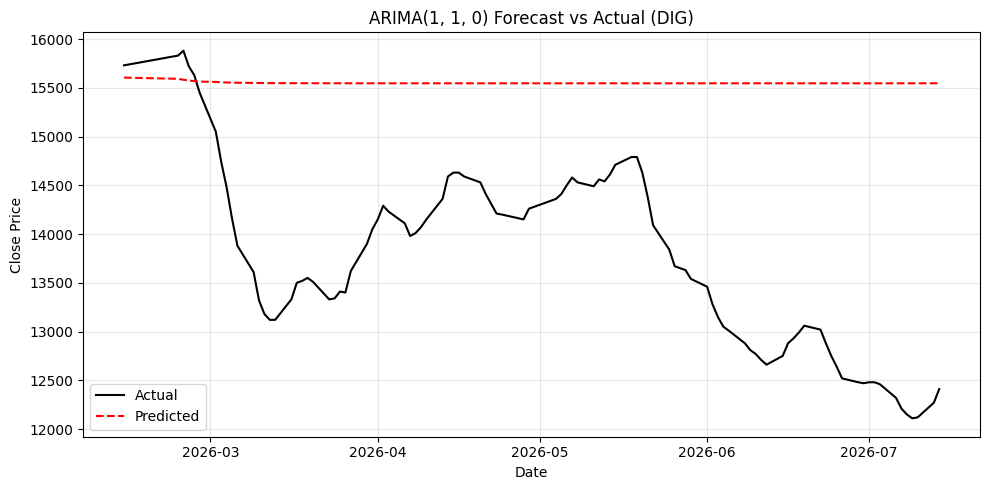


MÔ HÌNH 2: ESN TIÊU CHUẨN  [DIG]
Grid Search ESN: 625 combinations
Best ESN: n_res=60, sr=0.8, spa=0.12, alpha=0.01
Val MAE (seed=42): 246.64

ESN tiêu chuẩn — Kết quả từng seed [DIG]
  Seed  789 → MAE=202.55, RMSE=245.70, MAPE=1.52%
  Seed  456 → MAE=356.22, RMSE=394.01, MAPE=2.68%
  Seed 1234 → MAE=356.36, RMSE=400.72, MAPE=2.68%
  Seed   42 → MAE=357.61, RMSE=445.68, MAPE=2.72%
  Seed    0 → MAE=510.74, RMSE=569.48, MAPE=3.85%
  Seed  123 → MAE=564.77, RMSE=623.11, MAPE=4.25%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [DIG]
  MAE  = 391.37 ± 118.02
  RMSE = 446.45 ± 123.48
  MAPE = 2.95% ± 0.89%


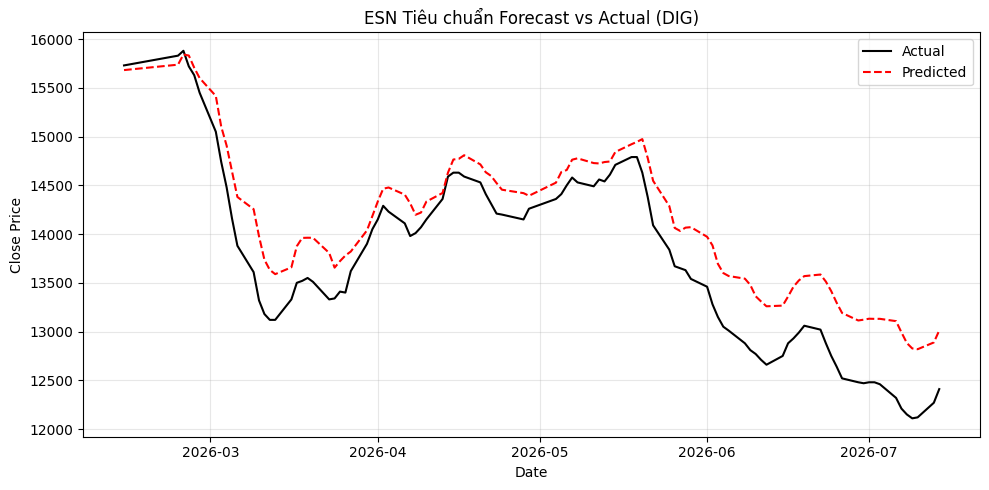


MÔ HÌNH 3: LSTM  [DIG]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=395.78
  units=40, drop=0.1, lr=0.005 → Val MAE=390.98
  units=40, drop=0.1, lr=0.01 → Val MAE=808.69
  units=40, drop=0.2, lr=0.001 → Val MAE=229.47
  units=40, drop=0.2, lr=0.005 → Val MAE=317.48
  units=40, drop=0.2, lr=0.01 → Val MAE=564.77
  units=40, drop=0.3, lr=0.001 → Val MAE=262.99
  units=40, drop=0.3, lr=0.005 → Val MAE=292.15
  units=40, drop=0.3, lr=0.01 → Val MAE=270.01
  units=48, drop=0.1, lr=0.001 → Val MAE=475.65
  units=48, drop=0.1, lr=0.005 → Val MAE=413.77
  units=48, drop=0.1, lr=0.01 → Val MAE=530.79
  units=48, drop=0.2, lr=0.001 → Val MAE=235.12
  units=48, drop=0.2, lr=0.005 → Val MAE=883.06
  units=48, drop=0.2, lr=0.01 → Val MAE=885.42
  units=48, drop=0.3, lr=0.001 → Val MAE=312.32
  units=48, drop=0.3, lr=0.005 → Val MAE=372.06
  units=48, drop=0.3, lr=0.01 → Val MAE=229.33
  units=50, drop=0.1, lr=0.001 → Val MAE=414.31
  units=50, drop=0.1, lr=0.005 → Val MAE=358.31
  

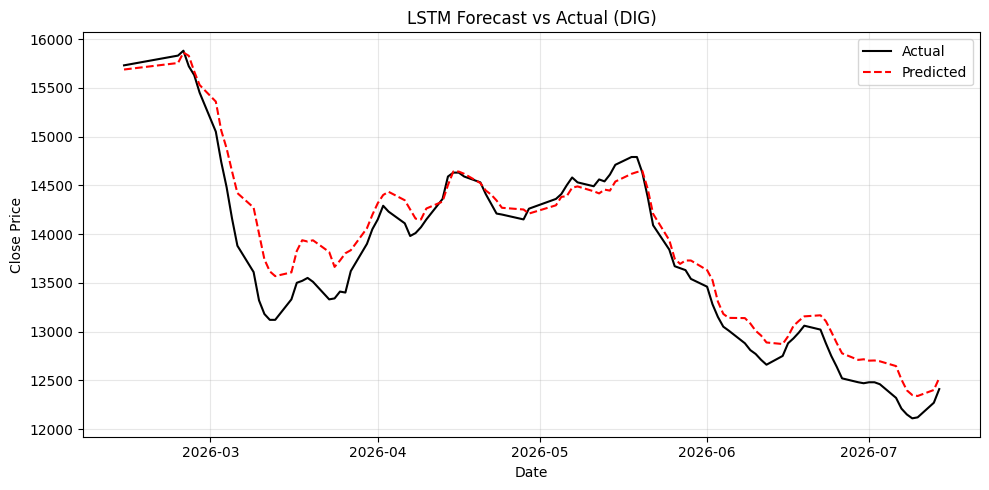


MÔ HÌNH 4: RANDOM FOREST  [DIG]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=1643.01
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=1627.35
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=1557.90
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=1504.10
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=1692.84
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=1639.80
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=1593.62
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=1542.61
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=1556.31
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=1446.86
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=1379.66
  {'max_depth': 10, 'min_samples_

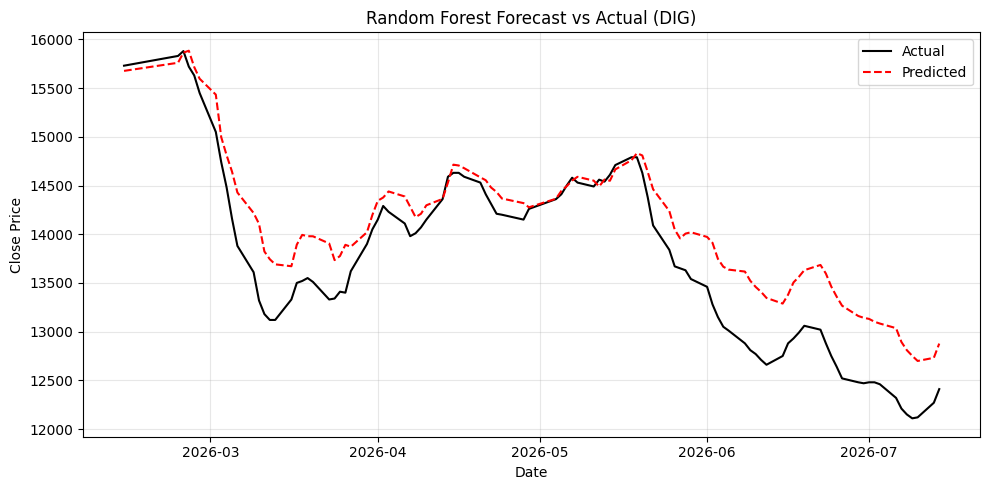


BẢNG SO SÁNH — TẬP TEST [DIG] (mean ± std, 6 seeds)
              Mô hình              MAE              RMSE       MAPE (%)
1  Deep ESN (đề xuất)  271.36 ± 134.46   313.68 ± 141.54  2.02% ± 1.02%
2       Random Forest   370.53 ± 37.36    444.01 ± 42.21  2.81% ± 0.29%
3      ESN tiêu chuẩn  391.37 ± 118.02   446.45 ± 123.48  2.95% ± 0.89%
4                LSTM  877.99 ± 522.33  1002.29 ± 578.61  6.58% ± 3.94%
5      ARIMA(1, 1, 0)          1829.07           2030.16         13.80%


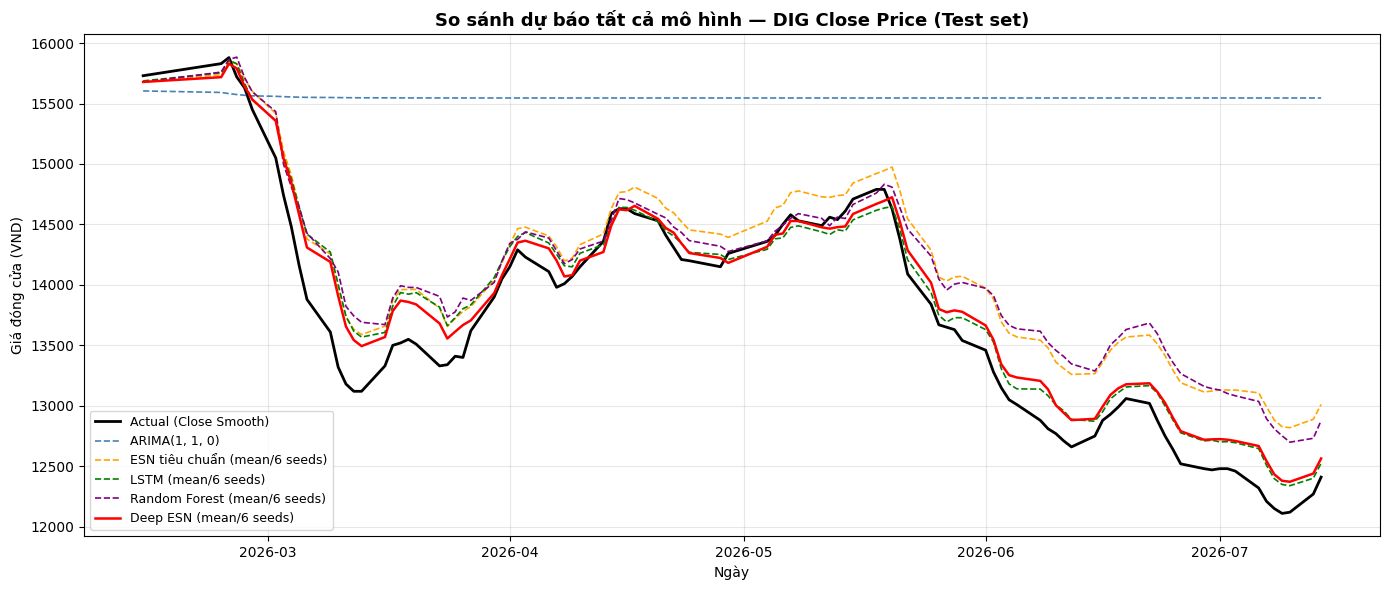


  PIPELINE: MSN  |  file: MSN.xlsx

Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ngày (2026-02-23 → 2026-07-15)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 82920.00
Anchor Val→Test  : 77800.00

MÔ HÌNH: DEEP ESN  [MSN]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=735.78
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=737.50
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=741.15
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=570.74
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=643.27
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=707.94

Best Deep ESN: n_res=45, n_layers=3, sr=0.75, spa=0.1, alpha=0.0005
Val MAE: 415.52

Deep ESN — Kết quả từng seed [MSN]
  Seed   42 → MAE=398.89, RMSE=52

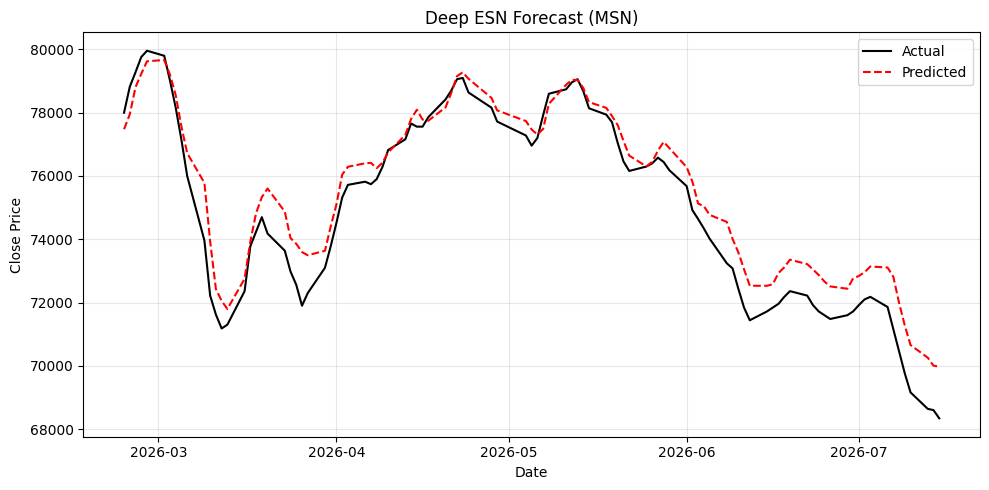


MÔ HÌNH 1: ARIMA  [MSN]
Grid search ARIMA order trên Val...
Best ARIMA order: (1, 1, 1), Val MAE: 3541.49

ARIMA(1, 1, 1) — Test Metrics [MSN]:
  MAE  = 3246.34
  RMSE = 4093.60
  MAPE = 4.47%


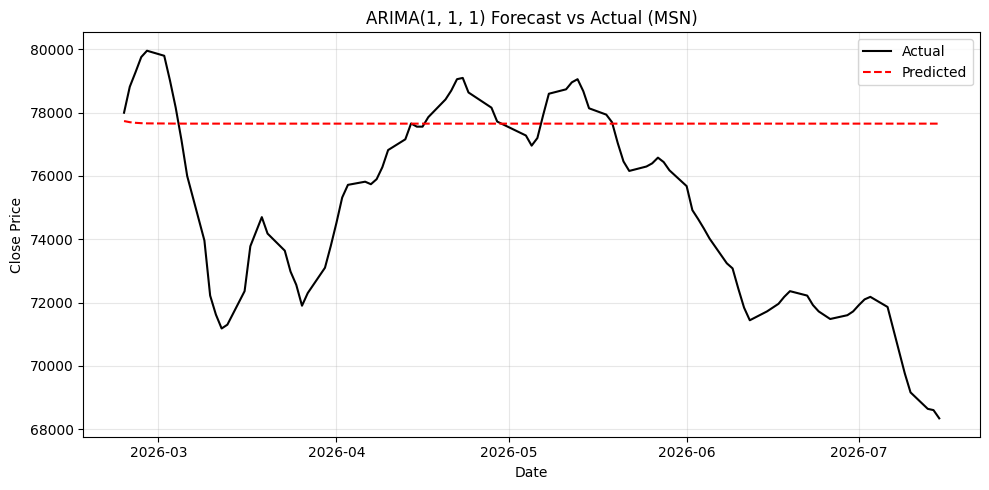


MÔ HÌNH 2: ESN TIÊU CHUẨN  [MSN]
Grid Search ESN: 625 combinations
Best ESN: n_res=80, sr=0.7, spa=0.15, alpha=0.001
Val MAE (seed=42): 430.59

ESN tiêu chuẩn — Kết quả từng seed [MSN]
  Seed   42 → MAE=603.08, RMSE=700.03, MAPE=0.80%
  Seed  789 → MAE=735.16, RMSE=911.72, MAPE=0.97%
  Seed  456 → MAE=964.00, RMSE=1106.03, MAPE=1.31%
  Seed    0 → MAE=984.46, RMSE=1109.32, MAPE=1.34%
  Seed 1234 → MAE=1008.46, RMSE=1117.85, MAPE=1.37%
  Seed  123 → MAE=1047.09, RMSE=1227.17, MAPE=1.43%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [MSN]
  MAE  = 890.37 ± 163.00
  RMSE = 1028.69 ± 173.94
  MAPE = 1.20% ± 0.23%


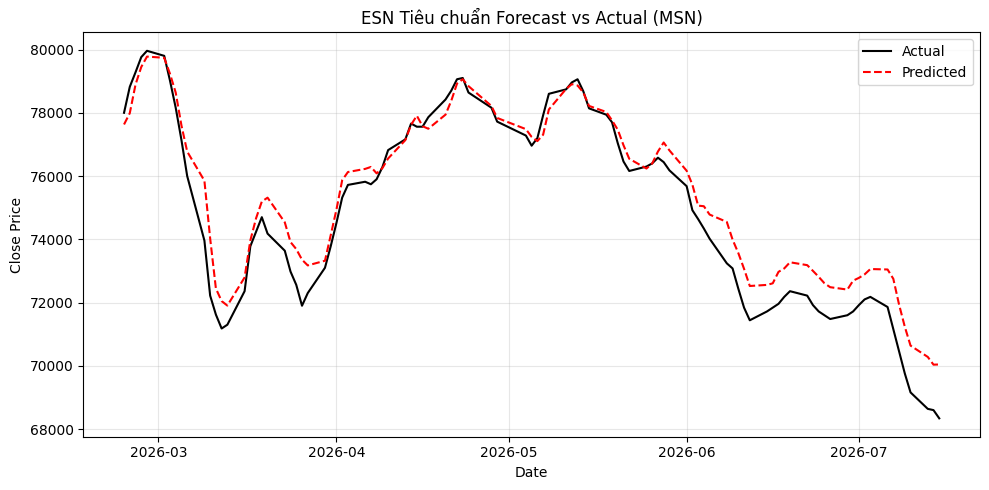


MÔ HÌNH 3: LSTM  [MSN]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=814.41
  units=40, drop=0.1, lr=0.005 → Val MAE=2041.92
  units=40, drop=0.1, lr=0.01 → Val MAE=1052.97
  units=40, drop=0.2, lr=0.001 → Val MAE=975.07
  units=40, drop=0.2, lr=0.005 → Val MAE=2733.49
  units=40, drop=0.2, lr=0.01 → Val MAE=962.68
  units=40, drop=0.3, lr=0.001 → Val MAE=889.28
  units=40, drop=0.3, lr=0.005 → Val MAE=1996.50
  units=40, drop=0.3, lr=0.01 → Val MAE=1052.27
  units=48, drop=0.1, lr=0.001 → Val MAE=3587.65
  units=48, drop=0.1, lr=0.005 → Val MAE=2126.05
  units=48, drop=0.1, lr=0.01 → Val MAE=1091.36
  units=48, drop=0.2, lr=0.001 → Val MAE=3592.79
  units=48, drop=0.2, lr=0.005 → Val MAE=1034.87
  units=48, drop=0.2, lr=0.01 → Val MAE=1054.41
  units=48, drop=0.3, lr=0.001 → Val MAE=858.38
  units=48, drop=0.3, lr=0.005 → Val MAE=1480.31
  units=48, drop=0.3, lr=0.01 → Val MAE=1020.64
  units=50, drop=0.1, lr=0.001 → Val MAE=5680.43
  units=50, drop=0.1, lr=0.005 → Val

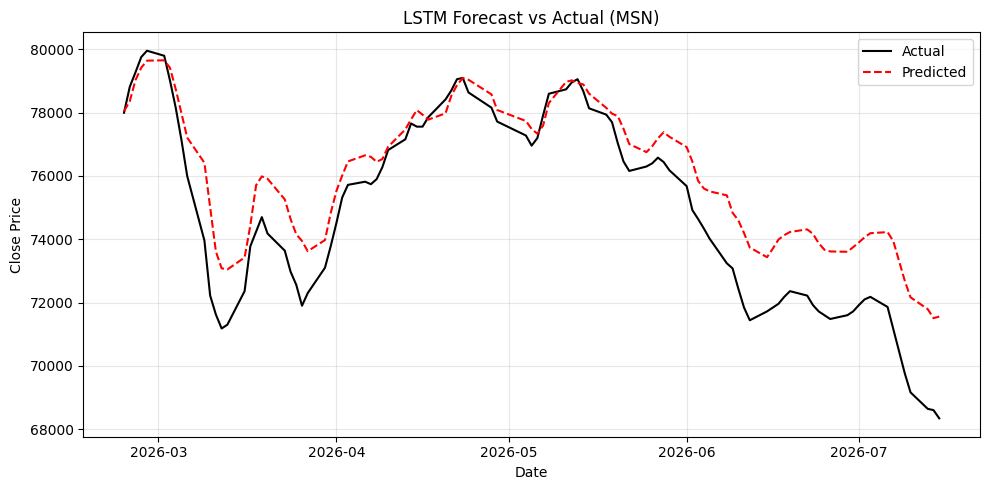


MÔ HÌNH 4: RANDOM FOREST  [MSN]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=2322.30
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=2161.34
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=2109.36
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=2162.61
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=2279.40
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=2219.53
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=2168.01
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=2230.29
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=2524.54
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=2250.81
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=2200.98
  {'max_depth': 10, 'min_samples_

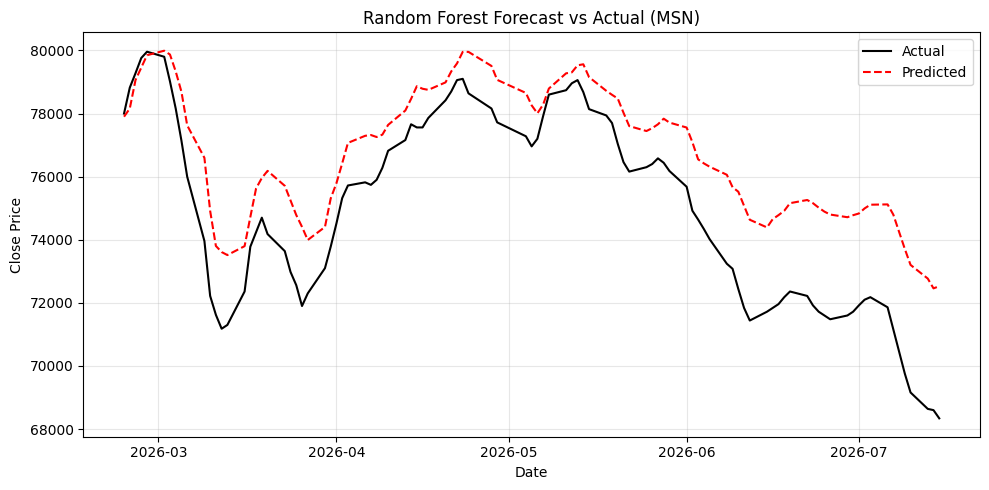


BẢNG SO SÁNH — TẬP TEST [MSN] (mean ± std, 6 seeds)
              Mô hình                MAE               RMSE       MAPE (%)
1  Deep ESN (đề xuất)    814.65 ± 499.49    955.75 ± 508.75  1.10% ± 0.68%
2      ESN tiêu chuẩn    890.37 ± 163.00   1028.69 ± 173.94  1.20% ± 0.23%
3       Random Forest    1820.91 ± 91.77    2111.56 ± 93.68  2.49% ± 0.12%
4                LSTM  1829.23 ± 1014.33  2153.95 ± 1147.97  2.49% ± 1.38%
5      ARIMA(1, 1, 1)            3246.34            4093.60          4.47%


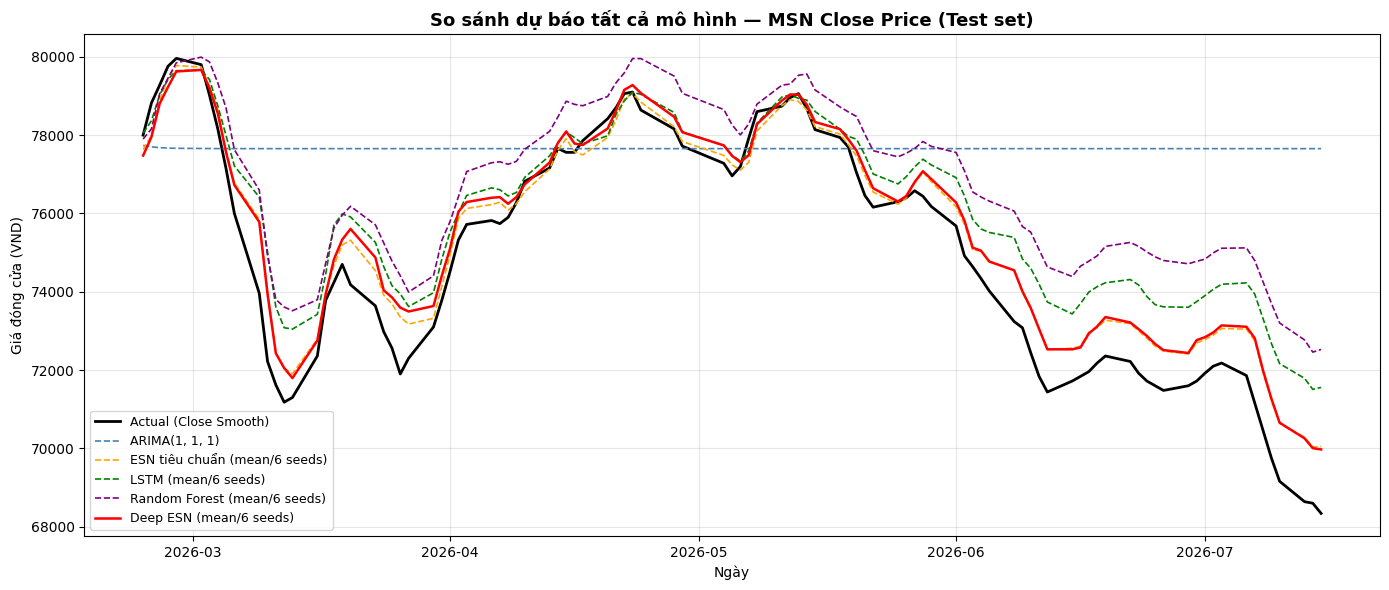


  PIPELINE: TPB  |  file: TPB.xlsx

Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ngày (2026-02-23 → 2026-07-15)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 18152.38
Anchor Val→Test  : 17120.00

MÔ HÌNH: DEEP ESN  [TPB]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=102.57
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=100.18
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=97.90
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=270.57
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=233.46
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=207.50

Best Deep ESN: n_res=40, n_layers=3, sr=0.73, spa=0.1, alpha=0.003
Val MAE: 87.82

Deep ESN — Kết quả từng seed [TPB]
  Seed    0 → MAE=137.42, RMSE=197.7

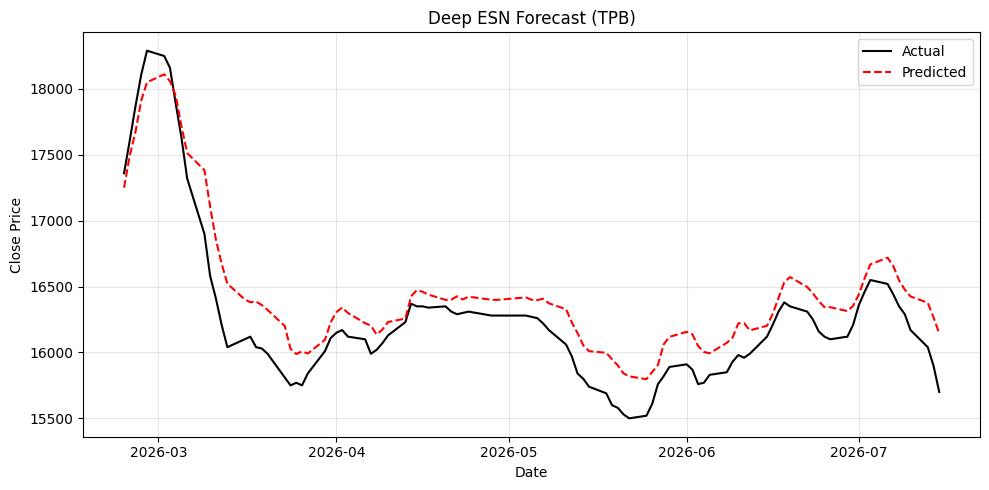


MÔ HÌNH 1: ARIMA  [TPB]
Grid search ARIMA order trên Val...
Best ARIMA order: (1, 1, 0), Val MAE: 1086.81

ARIMA(1, 1, 0) — Test Metrics [TPB]:
  MAE  = 1436.03
  RMSE = 1498.06
  MAPE = 8.93%


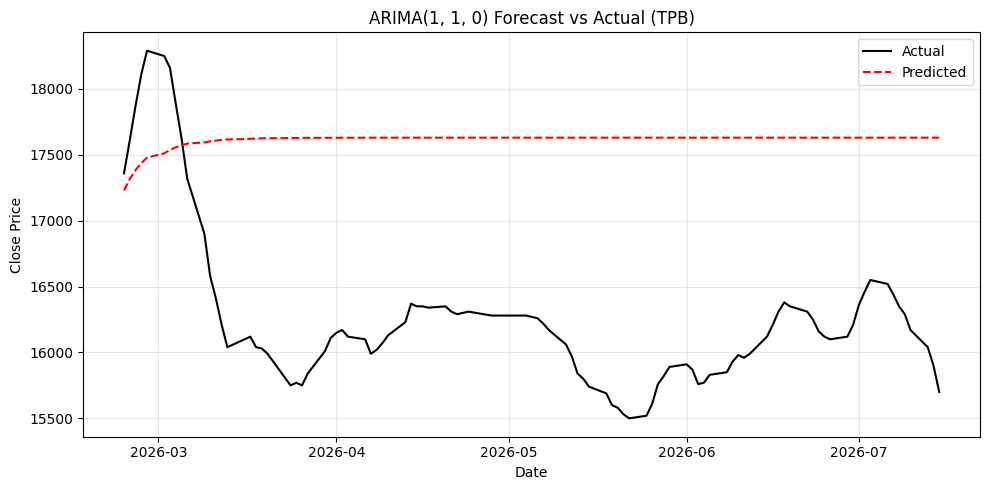


MÔ HÌNH 2: ESN TIÊU CHUẨN  [TPB]
Grid Search ESN: 625 combinations
Best ESN: n_res=80, sr=0.75, spa=0.12, alpha=0.0005
Val MAE (seed=42): 78.46

ESN tiêu chuẩn — Kết quả từng seed [TPB]
  Seed  789 → MAE=116.20, RMSE=150.49, MAPE=0.71%
  Seed   42 → MAE=235.24, RMSE=253.05, MAPE=1.45%
  Seed 1234 → MAE=407.58, RMSE=432.83, MAPE=2.53%
  Seed  456 → MAE=456.66, RMSE=480.03, MAPE=2.84%
  Seed    0 → MAE=498.40, RMSE=522.20, MAPE=3.09%
  Seed  123 → MAE=541.75, RMSE=565.76, MAPE=3.37%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [TPB]
  MAE  = 375.97 ± 151.25
  RMSE = 400.73 ± 149.30
  MAPE = 2.33% ± 0.94%


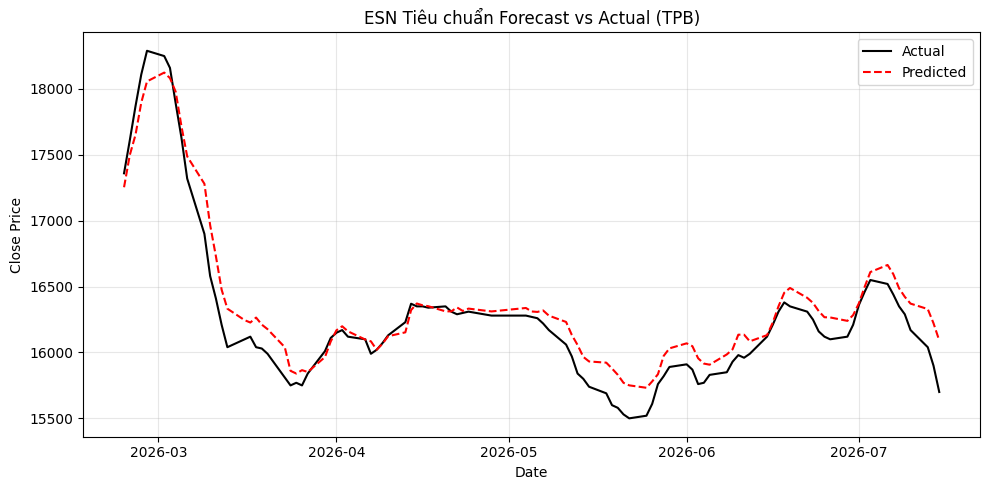


MÔ HÌNH 3: LSTM  [TPB]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=562.32
  units=40, drop=0.1, lr=0.005 → Val MAE=652.09
  units=40, drop=0.1, lr=0.01 → Val MAE=408.38
  units=40, drop=0.2, lr=0.001 → Val MAE=473.62
  units=40, drop=0.2, lr=0.005 → Val MAE=174.81
  units=40, drop=0.2, lr=0.01 → Val MAE=571.16
  units=40, drop=0.3, lr=0.001 → Val MAE=165.98
  units=40, drop=0.3, lr=0.005 → Val MAE=185.92
  units=40, drop=0.3, lr=0.01 → Val MAE=297.10
  units=48, drop=0.1, lr=0.001 → Val MAE=179.90
  units=48, drop=0.1, lr=0.005 → Val MAE=699.81
  units=48, drop=0.1, lr=0.01 → Val MAE=189.70
  units=48, drop=0.2, lr=0.001 → Val MAE=244.35
  units=48, drop=0.2, lr=0.005 → Val MAE=533.98
  units=48, drop=0.2, lr=0.01 → Val MAE=186.93
  units=48, drop=0.3, lr=0.001 → Val MAE=233.12
  units=48, drop=0.3, lr=0.005 → Val MAE=400.49
  units=48, drop=0.3, lr=0.01 → Val MAE=224.14
  units=50, drop=0.1, lr=0.001 → Val MAE=174.44
  units=50, drop=0.1, lr=0.005 → Val MAE=527.20
  

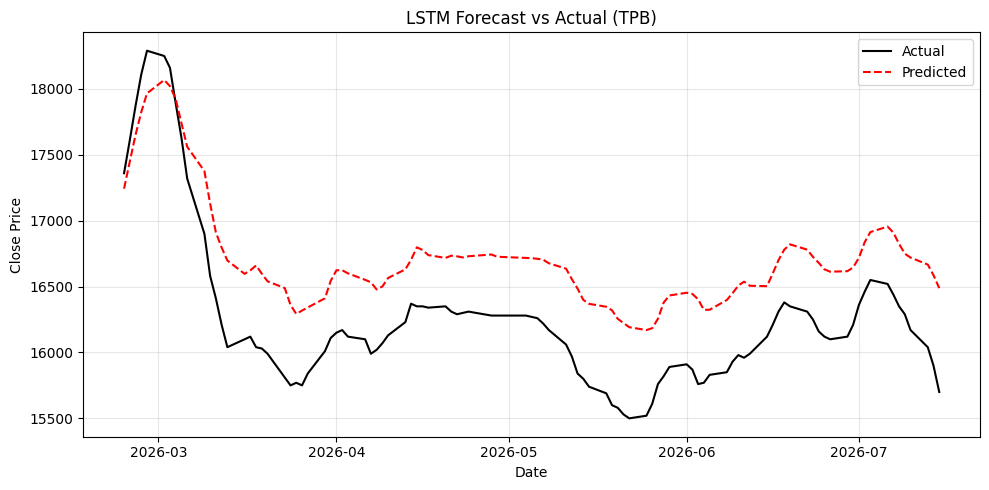


MÔ HÌNH 4: RANDOM FOREST  [TPB]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=266.64
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=242.97
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=220.89
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=227.08
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=256.02
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=234.40
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=223.36
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=225.57
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=356.21
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=319.02
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=276.37
  {'max_depth': 10, 'min_samples_split': 2, 

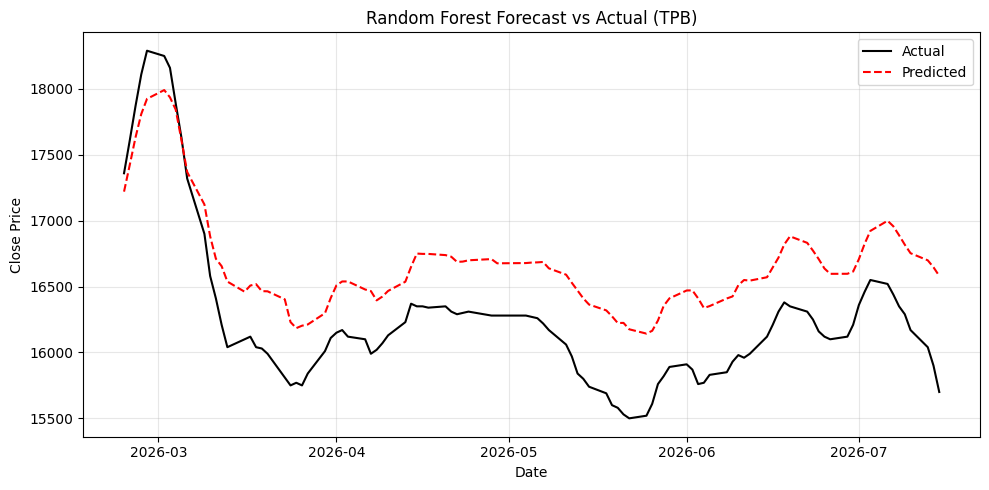


BẢNG SO SÁNH — TẬP TEST [TPB] (mean ± std, 6 seeds)
              Mô hình              MAE             RMSE       MAPE (%)
1  Deep ESN (đề xuất)  335.75 ± 160.34  366.70 ± 150.07  2.08% ± 1.00%
2      ESN tiêu chuẩn  375.97 ± 151.25  400.73 ± 149.30  2.33% ± 0.94%
3       Random Forest   448.68 ± 24.85   471.65 ± 26.28  2.79% ± 0.16%
4                LSTM  530.28 ± 218.43  569.46 ± 218.38  3.29% ± 1.36%
5      ARIMA(1, 1, 0)          1436.03          1498.06          8.93%


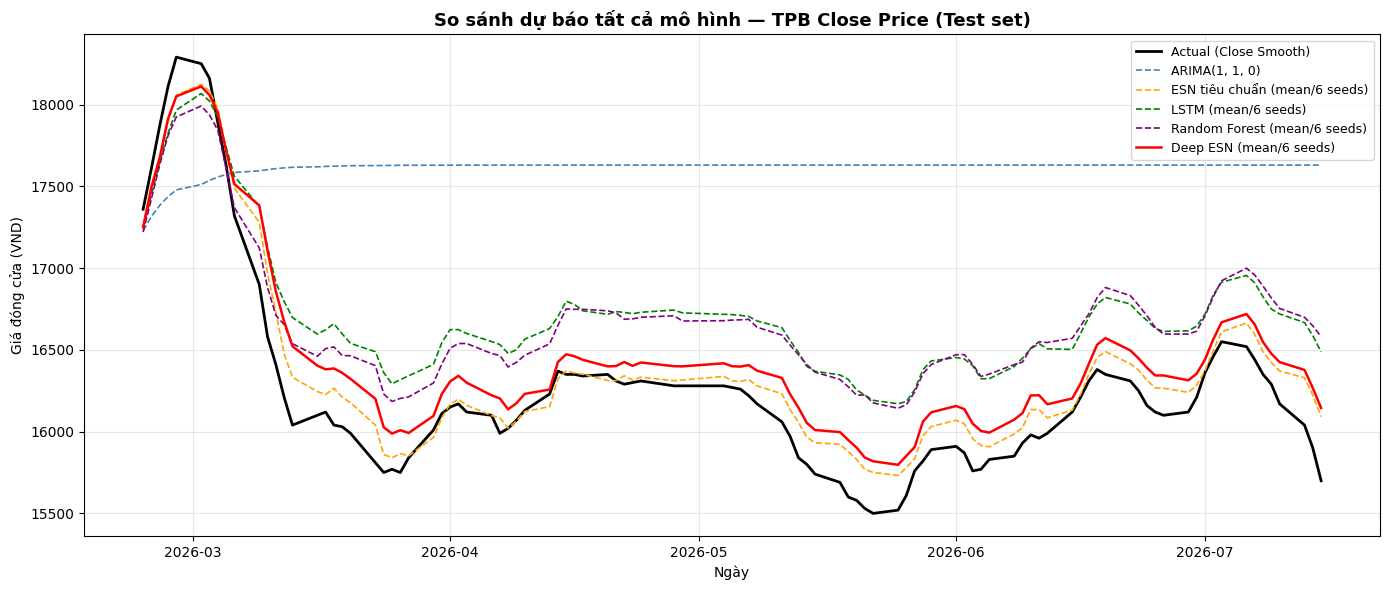


  PIPELINE: DBC  |  file: DBC.xlsx

Train : 800 ngày (2022-07-14 → 2025-09-26)
Val   : 100 ngày (2025-09-29 → 2026-02-24)
Test  : 100 ngày (2026-02-25 → 2026-07-17)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 24103.50
Anchor Val→Test  : 23654.37

MÔ HÌNH: DEEP ESN  [DBC]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=170.71
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=169.74
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=168.29
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=515.64
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=489.61
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=469.25

Best Deep ESN: n_res=50, n_layers=3, sr=0.74, spa=0.08, alpha=0.002
Val MAE: 123.58

Deep ESN — Kết quả từng seed [DBC]
  Seed  789 → MAE=701.55, RMSE=75

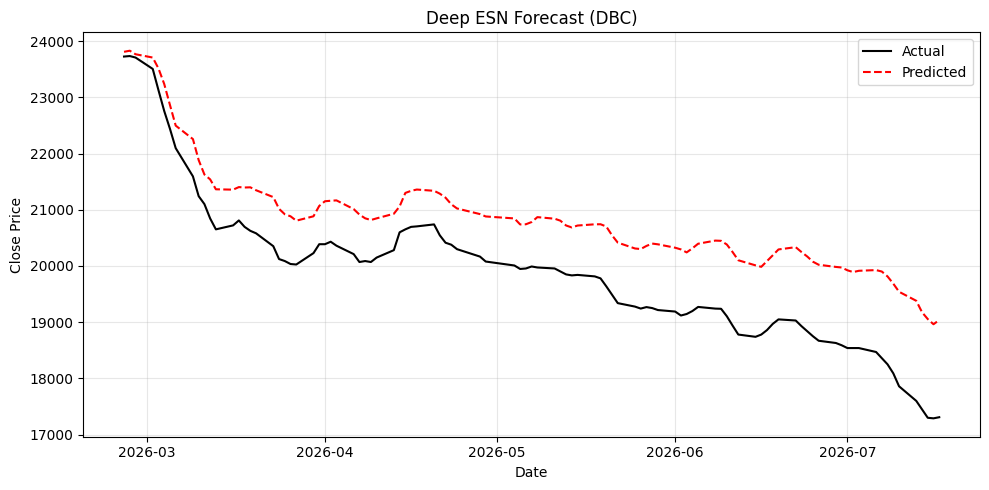


MÔ HÌNH 1: ARIMA  [DBC]
Grid search ARIMA order trên Val...
Best ARIMA order: (2, 1, 2), Val MAE: 585.61

ARIMA(2, 1, 2) — Test Metrics [DBC]:
  MAE  = 3935.91
  RMSE = 4154.90
  MAPE = 20.33%


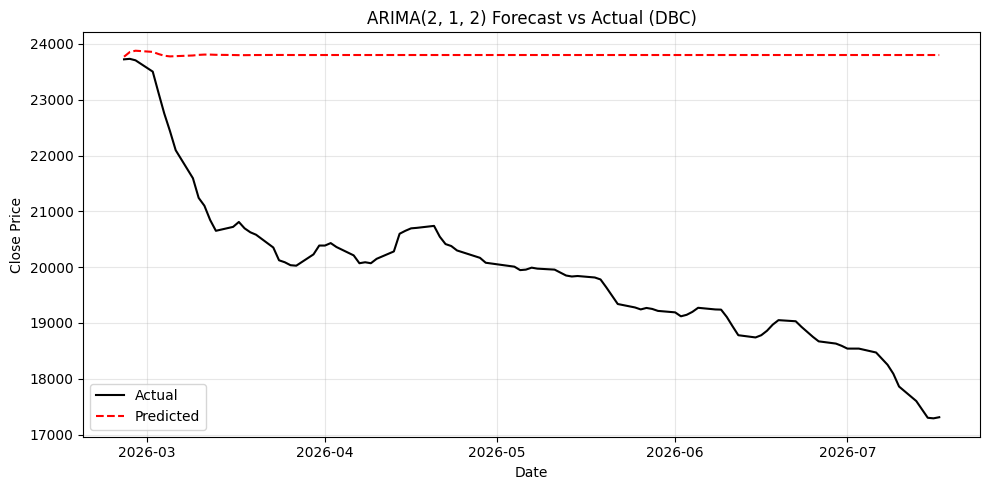


MÔ HÌNH 2: ESN TIÊU CHUẨN  [DBC]
Grid Search ESN: 625 combinations
Best ESN: n_res=60, sr=0.8, spa=0.1, alpha=0.0005
Val MAE (seed=42): 125.63

ESN tiêu chuẩn — Kết quả từng seed [DBC]
  Seed   42 → MAE=927.99, RMSE=973.39, MAPE=4.78%
  Seed  789 → MAE=1044.09, RMSE=1097.04, MAPE=5.39%
  Seed 1234 → MAE=1068.49, RMSE=1134.48, MAPE=5.52%
  Seed  456 → MAE=1193.96, RMSE=1276.11, MAPE=6.18%
  Seed  123 → MAE=1313.50, RMSE=1409.34, MAPE=6.80%
  Seed    0 → MAE=1351.68, RMSE=1464.81, MAPE=7.01%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [DBC]
  MAE  = 1149.95 ± 150.83
  RMSE = 1225.86 ± 174.15
  MAPE = 5.95% ± 0.79%


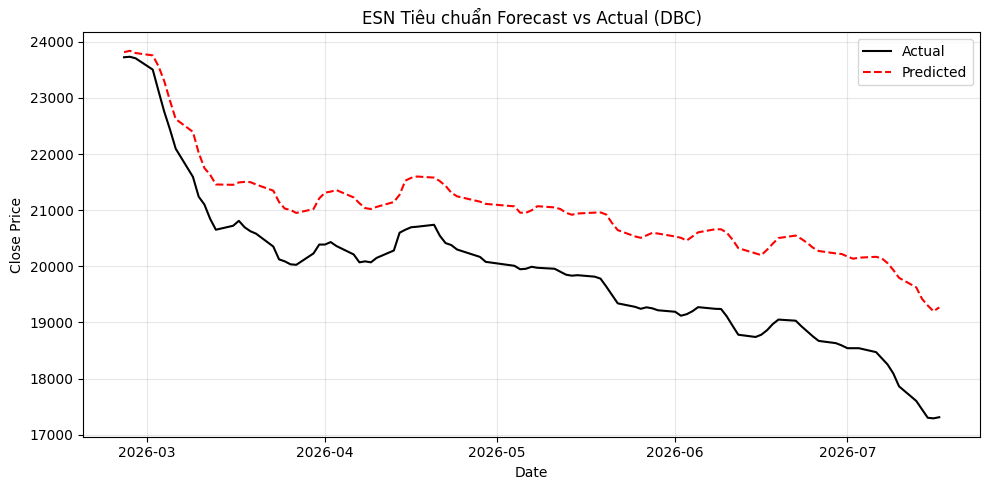


MÔ HÌNH 3: LSTM  [DBC]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=314.29
  units=40, drop=0.1, lr=0.005 → Val MAE=1004.38
  units=40, drop=0.1, lr=0.01 → Val MAE=859.84
  units=40, drop=0.2, lr=0.001 → Val MAE=251.29
  units=40, drop=0.2, lr=0.005 → Val MAE=220.97
  units=40, drop=0.2, lr=0.01 → Val MAE=659.23
  units=40, drop=0.3, lr=0.001 → Val MAE=233.56
  units=40, drop=0.3, lr=0.005 → Val MAE=380.66
  units=40, drop=0.3, lr=0.01 → Val MAE=1034.73
  units=48, drop=0.1, lr=0.001 → Val MAE=231.43
  units=48, drop=0.1, lr=0.005 → Val MAE=269.69
  units=48, drop=0.1, lr=0.01 → Val MAE=237.17
  units=48, drop=0.2, lr=0.001 → Val MAE=341.28
  units=48, drop=0.2, lr=0.005 → Val MAE=508.31
  units=48, drop=0.2, lr=0.01 → Val MAE=249.61
  units=48, drop=0.3, lr=0.001 → Val MAE=248.74
  units=48, drop=0.3, lr=0.005 → Val MAE=349.17
  units=48, drop=0.3, lr=0.01 → Val MAE=284.99
  units=50, drop=0.1, lr=0.001 → Val MAE=244.09
  units=50, drop=0.1, lr=0.005 → Val MAE=618.98


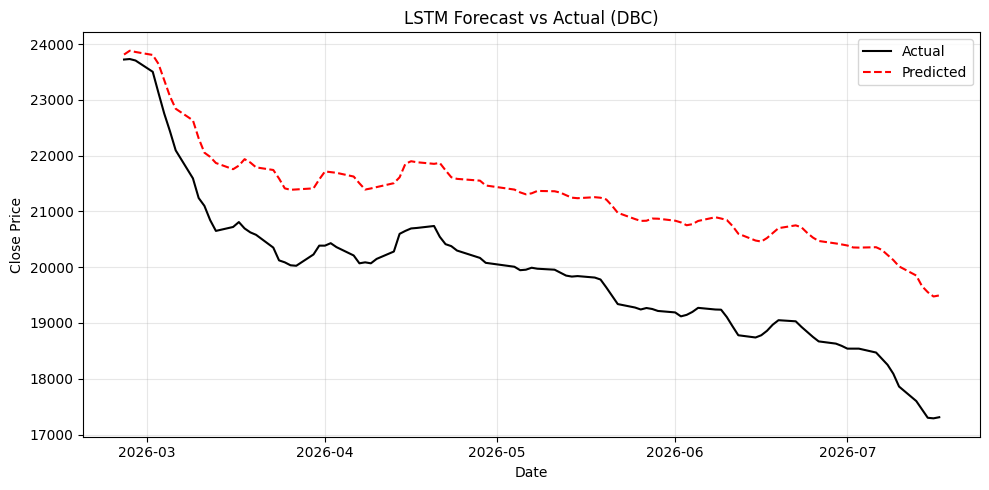


MÔ HÌNH 4: RANDOM FOREST  [DBC]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=196.30
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=193.51
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=184.70
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=181.47
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=190.75
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=189.72
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=182.72
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=179.33
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=185.30
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=198.85
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=191.20
  {'max_depth': 10, 'min_samples_split': 2, 

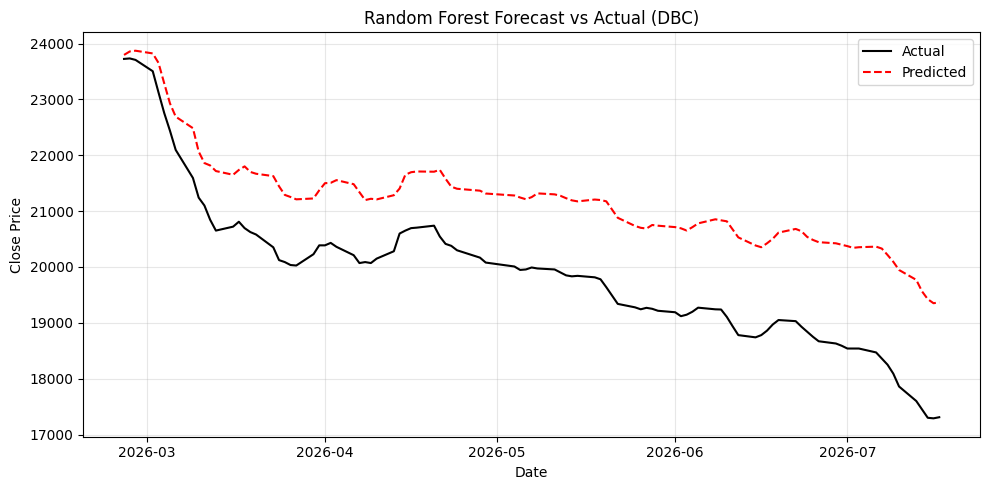


BẢNG SO SÁNH — TẬP TEST [DBC] (mean ± std, 6 seeds)
              Mô hình               MAE              RMSE       MAPE (%)
1  Deep ESN (đề xuất)   959.34 ± 130.08  1032.35 ± 142.14  4.97% ± 0.68%
2      ESN tiêu chuẩn  1149.95 ± 150.83  1225.86 ± 174.15  5.95% ± 0.79%
3       Random Forest   1326.06 ± 25.82   1397.71 ± 27.75  6.84% ± 0.13%
4                LSTM  1430.90 ± 785.45  1523.65 ± 862.35  7.37% ± 4.11%
5      ARIMA(2, 1, 2)           3935.91           4154.90         20.33%


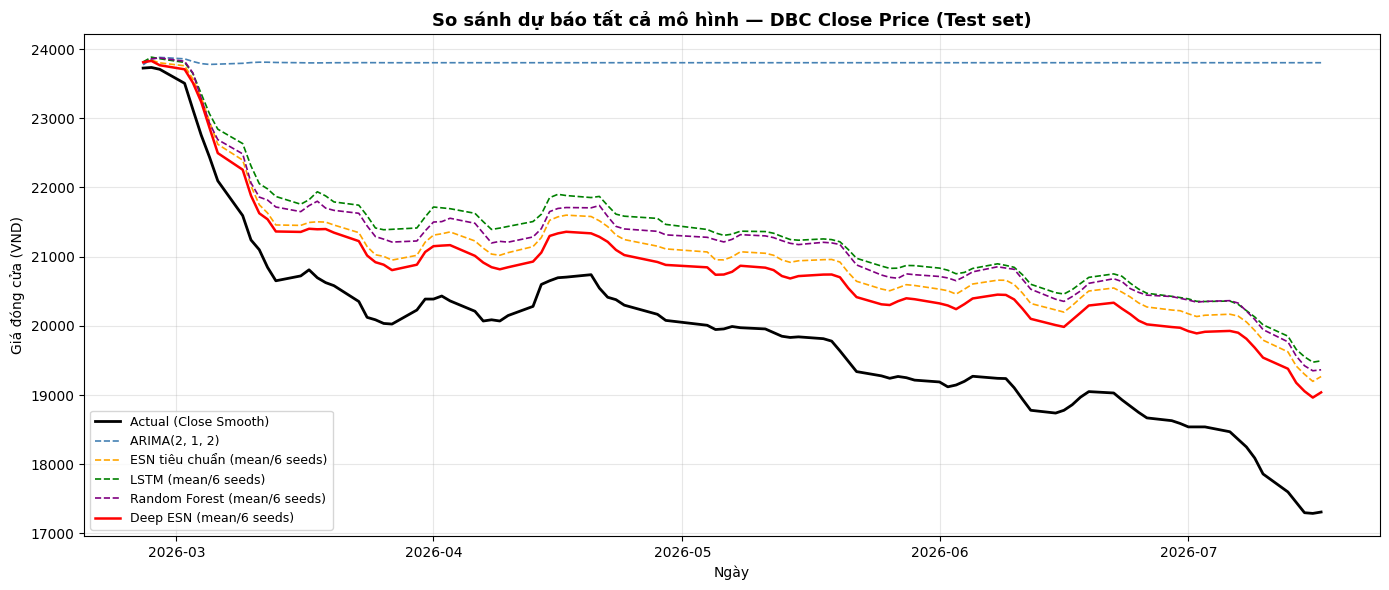


  PIPELINE: SAB  |  file: SAB.xlsx

Train : 800 ngày (2022-07-13 → 2025-09-25)
Val   : 100 ngày (2025-09-26 → 2026-02-23)
Test  : 100 ngày (2026-02-24 → 2026-07-16)
Shapes — Train: (790, 10), Val: (100, 10), Test: (100, 10)
Anchor Train→Val : 44015.03
Anchor Val→Test  : 48640.00

MÔ HÌNH: DEEP ESN  [SAB]
Grid Search Deep ESN: 1200 combinations
[1/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0005 -> MAE=1725.07
[2/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.0007 -> MAE=1727.53
[3/1200] n_res=40, n_layers=2, sr=0.7, spa=0.07, alpha=0.001 -> MAE=1728.52
...
(Còn 1194 combinations...)
...
[1198/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.002 -> MAE=1609.62
[1199/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.003 -> MAE=1595.80
[1200/1200] n_res=55, n_layers=3, sr=0.75, spa=0.12, alpha=0.004 -> MAE=1584.70

Best Deep ESN: n_res=45, n_layers=2, sr=0.72, spa=0.12, alpha=0.0005
Val MAE: 919.25

Deep ESN — Kết quả từng seed [SAB]
  Seed    0 → MAE=319.81, 

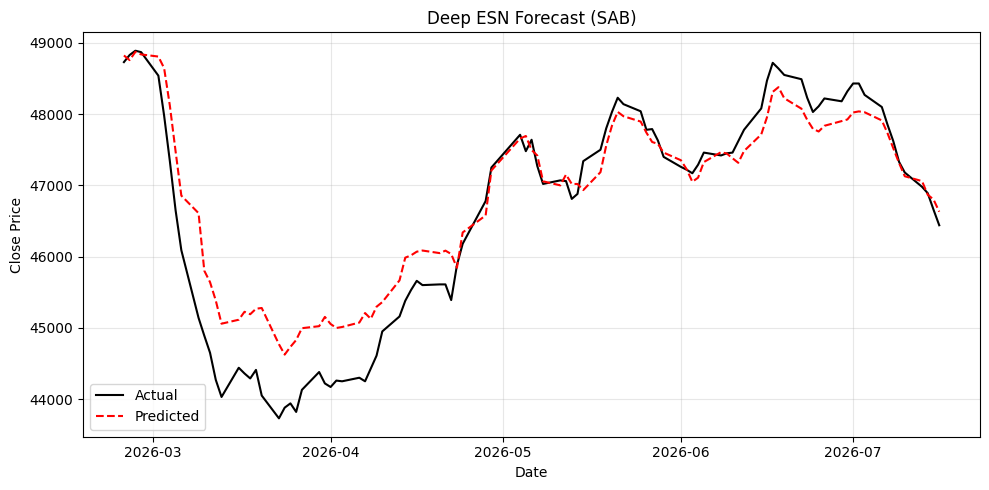


MÔ HÌNH 1: ARIMA  [SAB]
Grid search ARIMA order trên Val...
Best ARIMA order: (2, 1, 2), Val MAE: 2777.63

ARIMA(2, 1, 2) — Test Metrics [SAB]:
  MAE  = 2106.49
  RMSE = 2631.45
  MAPE = 4.64%


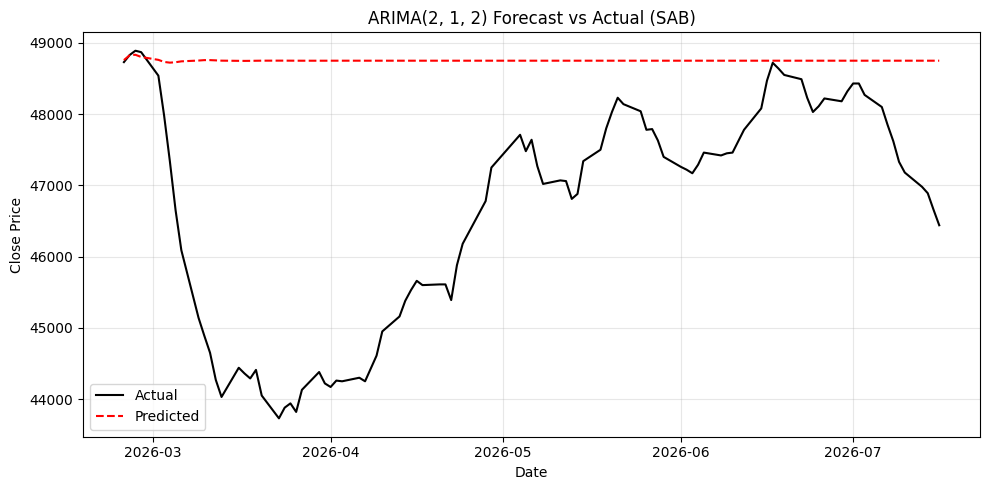


MÔ HÌNH 2: ESN TIÊU CHUẨN  [SAB]
Grid Search ESN: 625 combinations
Best ESN: n_res=40, sr=0.8, spa=0.12, alpha=0.0005
Val MAE (seed=42): 954.82

ESN tiêu chuẩn — Kết quả từng seed [SAB]
  Seed   42 → MAE=357.22, RMSE=475.51, MAPE=0.79%
  Seed  456 → MAE=455.04, RMSE=615.25, MAPE=1.00%
  Seed  789 → MAE=484.02, RMSE=638.94, MAPE=1.07%
  Seed 1234 → MAE=510.59, RMSE=593.62, MAPE=1.11%
  Seed    0 → MAE=614.58, RMSE=714.93, MAPE=1.34%
  Seed  123 → MAE=853.43, RMSE=939.78, MAPE=1.86%

ESN tiêu chuẩn — Test (mean ± std, 6 seeds) [SAB]
  MAE  = 545.81 ± 157.18
  RMSE = 663.01 ± 142.67
  MAPE = 1.19% ± 0.34%


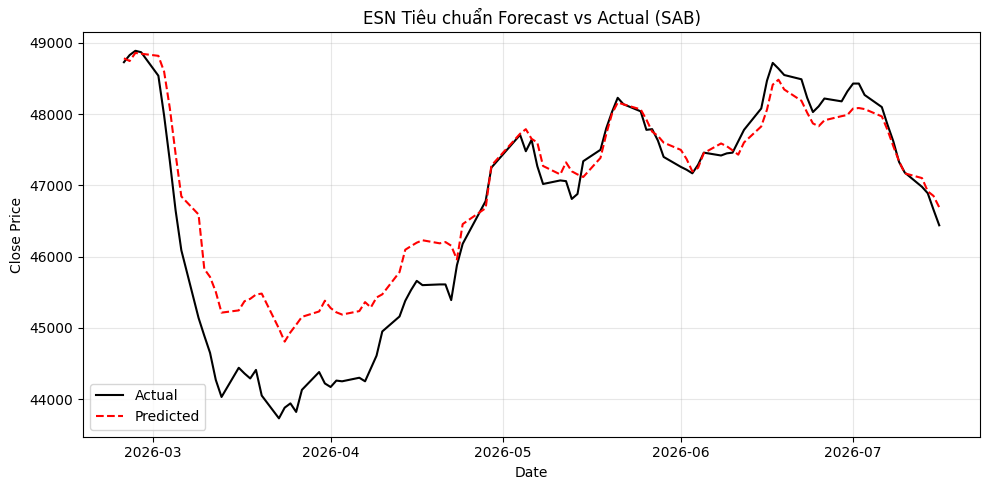


MÔ HÌNH 3: LSTM  [SAB]
Grid search LSTM...
  units=40, drop=0.1, lr=0.001 → Val MAE=1798.37
  units=40, drop=0.1, lr=0.005 → Val MAE=1192.77
  units=40, drop=0.1, lr=0.01 → Val MAE=495.30
  units=40, drop=0.2, lr=0.001 → Val MAE=2316.62
  units=40, drop=0.2, lr=0.005 → Val MAE=1293.02
  units=40, drop=0.2, lr=0.01 → Val MAE=668.94
  units=40, drop=0.3, lr=0.001 → Val MAE=2595.29
  units=40, drop=0.3, lr=0.005 → Val MAE=943.12
  units=40, drop=0.3, lr=0.01 → Val MAE=1499.33
  units=48, drop=0.1, lr=0.001 → Val MAE=1841.76
  units=48, drop=0.1, lr=0.005 → Val MAE=2098.96
  units=48, drop=0.1, lr=0.01 → Val MAE=540.36
  units=48, drop=0.2, lr=0.001 → Val MAE=1752.26
  units=48, drop=0.2, lr=0.005 → Val MAE=2501.81
  units=48, drop=0.2, lr=0.01 → Val MAE=1393.56
  units=48, drop=0.3, lr=0.001 → Val MAE=995.13
  units=48, drop=0.3, lr=0.005 → Val MAE=1822.43
  units=48, drop=0.3, lr=0.01 → Val MAE=1095.33
  units=50, drop=0.1, lr=0.001 → Val MAE=1616.52
  units=50, drop=0.1, lr=0.005 → Val

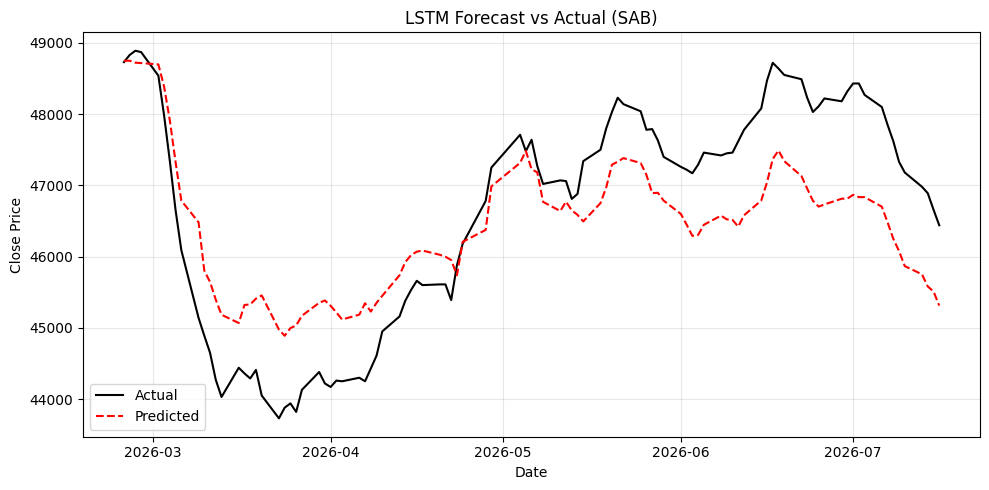


MÔ HÌNH 4: RANDOM FOREST  [SAB]
Grid Search RF: 24 combinations
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=1337.13
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=1470.84
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=1413.25
  {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 250} → Val MAE=1428.60
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50} → Val MAE=1347.52
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} → Val MAE=1455.73
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200} → Val MAE=1422.65
  {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 250} → Val MAE=1431.03
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50} → Val MAE=1481.71
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} → Val MAE=1532.36
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} → Val MAE=1548.06
  {'max_depth': 10, 'min_samples_

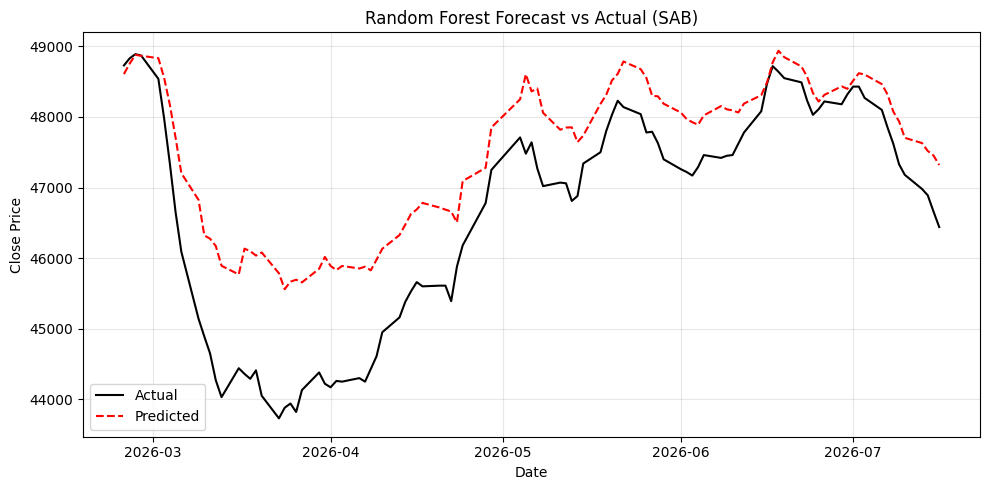


BẢNG SO SÁNH — TẬP TEST [SAB] (mean ± std, 6 seeds)
              Mô hình               MAE              RMSE       MAPE (%)
1  Deep ESN (đề xuất)    455.17 ± 70.71    567.12 ± 79.52  0.99% ± 0.15%
2      ESN tiêu chuẩn   545.81 ± 157.18   663.01 ± 142.67  1.19% ± 0.34%
3       Random Forest    864.14 ± 92.34   1025.87 ± 73.51  1.89% ± 0.20%
4                LSTM  1946.03 ± 776.26  2298.68 ± 995.35  4.14% ± 1.62%
5      ARIMA(2, 1, 2)           2106.49           2631.45          4.64%


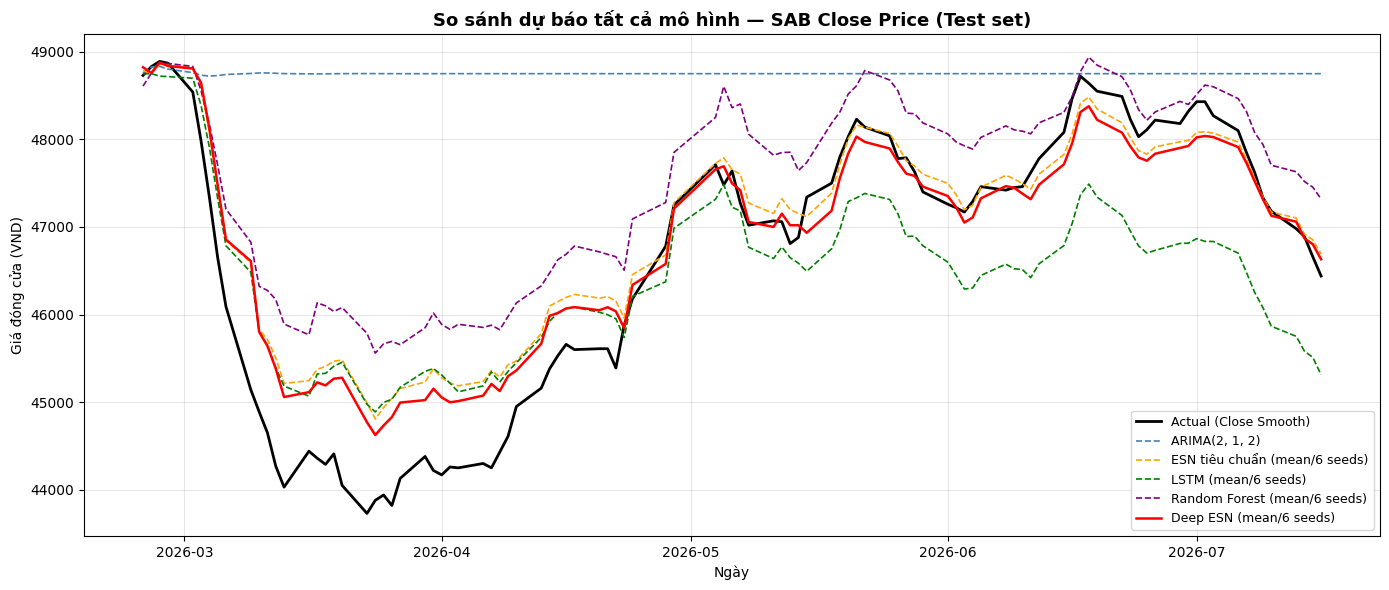

In [9]:
# ============================================================
# CELL MAIN — Chạy toàn bộ dataset
# (TCB, CTS, CTG,..... )
# ============================================================
STOCKS = [
    ("TCB.xlsx", "TCB", "xlsx"),
    ("CTG.csv", "CTG", "csv"),
    ("CTS.csv", "CTS", "csv"),
    ("FPT.xlsx", "FPT", "xlsx"),
    ("PAN.xlsx", "PAN", "xlsx"),
    ("DIG.xlsx", "DIG", "xlsx"),
    ("MSN.xlsx", "MSN", "xlsx"),
    ("TPB.xlsx", "TPB", "xlsx"),
    ("DBC.xlsx", "DBC", "xlsx"),
    ("SAB.xlsx", "SAB", "xlsx"),
]

results = {}
for filepath, stock_name, loader_type in STOCKS:
    results[stock_name] = run_pipeline(
        filepath=filepath, stock_name=stock_name,
        loader_type=loader_type, smooth_window=5, window=10)

# ── Bảng màu / marker dùng chung cho các biểu đồ dạng "slide" ──────
STOCK_PALETTE = ["#7C98B3", "#1B2A4A", "#D4AF37", "#4C7A8C", "#8E44AD",
                  "#2E8B74", "#C0524A", "#5C6BC0", "#B08968", "#556B2F"]
STOCK_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]

STOCK_COLORS = {
    stock_name: STOCK_PALETTE[i % len(STOCK_PALETTE)]
    for i, (_, stock_name, _) in enumerate(STOCKS)
}
STOCK_MARKER = {
    stock_name: STOCK_MARKERS[i % len(STOCK_MARKERS)]
    for i, (_, stock_name, _) in enumerate(STOCKS)
}

MODEL_COLORS = {
    "ARIMA":               "#B8C4D9",
    "LSTM":                "#8797B2",
    "Random Forest":       "#5B6F91",
    "ESN tiêu chuẩn":      "#1B2A4A",
    "Deep ESN (đề xuất)":  "#D4AF37",
}

ABLATION_COLORS = {"1 lớp": "#8FA8C4", "2 lớp": "#4C6485", "3 lớp": "#D4AF37"}


def vn_number(v):
    """Định dạng số theo kiểu VN: dấu chấm ngăn cách hàng nghìn."""
    return f"{v:,.0f}".replace(",", ".")


def style_slide_chart(fig, ax, title, subtitle):
    """Áp style dạng slide: tiêu đề đậm + phụ đề nghiêng, gọn, không khung."""
    fig.suptitle(title, fontsize=22, fontweight="bold",
                 x=0.02, ha="left", y=1.03, fontfamily="serif",
                 color="#1a1a1a")
    ax.set_title(subtitle, fontsize=12.5, style="italic",
                 color="#5a5a5a", loc="left", pad=18)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#999999")
    ax.grid(axis="y", color="#e2e2e2", linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(left=False, bottom=False, labelsize=10.5)


In [10]:
# ============================================================
# CELL TỔNG KẾT
# ============================================================
def _get(r, mean_key, list_key, pct=False):
    mean   = r[mean_key]
    std    = np.std(r[list_key]) if list_key and r.get(list_key) else 0.0
    suffix = "%" if pct else ""
    return f"{mean:.2f}{suffix} ± {std:.2f}{suffix}"

_KEY = {
    "Deep ESN (đề xuất)": ("mae_deepesn", "mae_list_deepesn",
                            "rmse_deepesn", "rmse_list_deepesn",
                            "mape_deepesn", "mape_list_deepesn"),
    "ESN tiêu chuẩn":     ("mae_esn",     "mae_list_esn",
                            "rmse_esn",    "rmse_list_esn",
                            "mape_esn",    "mape_list_esn"),
    "Random Forest":      ("mae_rf",      "mae_list_rf",
                            "rmse_rf",     "rmse_list_rf",
                            "mape_rf",     "mape_list_rf"),
    "LSTM":               ("mae_lstm",    "mae_list_lstm",
                            "rmse_lstm",   "rmse_list_lstm",
                            "mape_lstm",   "mape_list_lstm"),
    "ARIMA":              ("mae_arima",   None,
                            "rmse_arima",  None,
                            "mape_arima",  None),
}

records = []
for model_name, (mk_mae, lk_mae, mk_rmse, lk_rmse, mk_mape, lk_mape) in _KEY.items():
    row = {"Mô hình": model_name}
    for _, stock_name, _ in STOCKS:
        r = results[stock_name]
        row[f"{stock_name} — MAE"]  = _get(r, mk_mae,  lk_mae)
        row[f"{stock_name} — RMSE"] = _get(r, mk_rmse, lk_rmse)
        row[f"{stock_name} — MAPE"] = _get(r, mk_mape, lk_mape, pct=True)
    records.append(row)

df_summary = pd.DataFrame(records).set_index("Mô hình")
print("\n" + "="*110)
print(f"BẢNG TỔNG KẾT — TẬP TEST: Deep ESN (đề xuất) vs các baseline ({len(STOCKS)} mã)")
print("Báo cáo: mean ± std trên 6 seeds  |  ARIMA tất định nên std = 0.00")
print("="*110)
print(df_summary.to_string())
print("="*110)

print("\n── Xếp hạng theo MAE ──")
for _, stock_name, _ in STOCKS:
    r = results[stock_name]
    ranking = sorted(
        [(name, r[keys[0]]) for name, keys in _KEY.items()],
        key=lambda x: x[1])
    print(f"\n  {r['stock']}:")
    for rank, (model, mae_val) in enumerate(ranking, 1):
        tag = "  <- TOT NHAT" if rank == 1 else ""
        print(f"    #{rank}  {model:<24}  MAE = {mae_val:.2f}{tag}")
print()



BẢNG TỔNG KẾT — TẬP TEST: Deep ESN (đề xuất) vs các baseline (10 mã)
Báo cáo: mean ± std trên 6 seeds  |  ARIMA tất định nên std = 0.00
                          TCB — MAE       TCB — RMSE     TCB — MAPE        CTG — MAE       CTG — RMSE     CTG — MAPE         CTS — MAE        CTS — RMSE      CTS — MAPE          FPT — MAE         FPT — RMSE      FPT — MAPE        PAN — MAE       PAN — RMSE     PAN — MAPE        DIG — MAE        DIG — RMSE      DIG — MAPE          MSN — MAE         MSN — RMSE     MSN — MAPE        TPB — MAE       TPB — RMSE     TPB — MAPE         DBC — MAE        DBC — RMSE      DBC — MAPE         SAB — MAE        SAB — RMSE     SAB — MAPE
Mô hình                                                                                                                                                                                                                                                                                                                                        

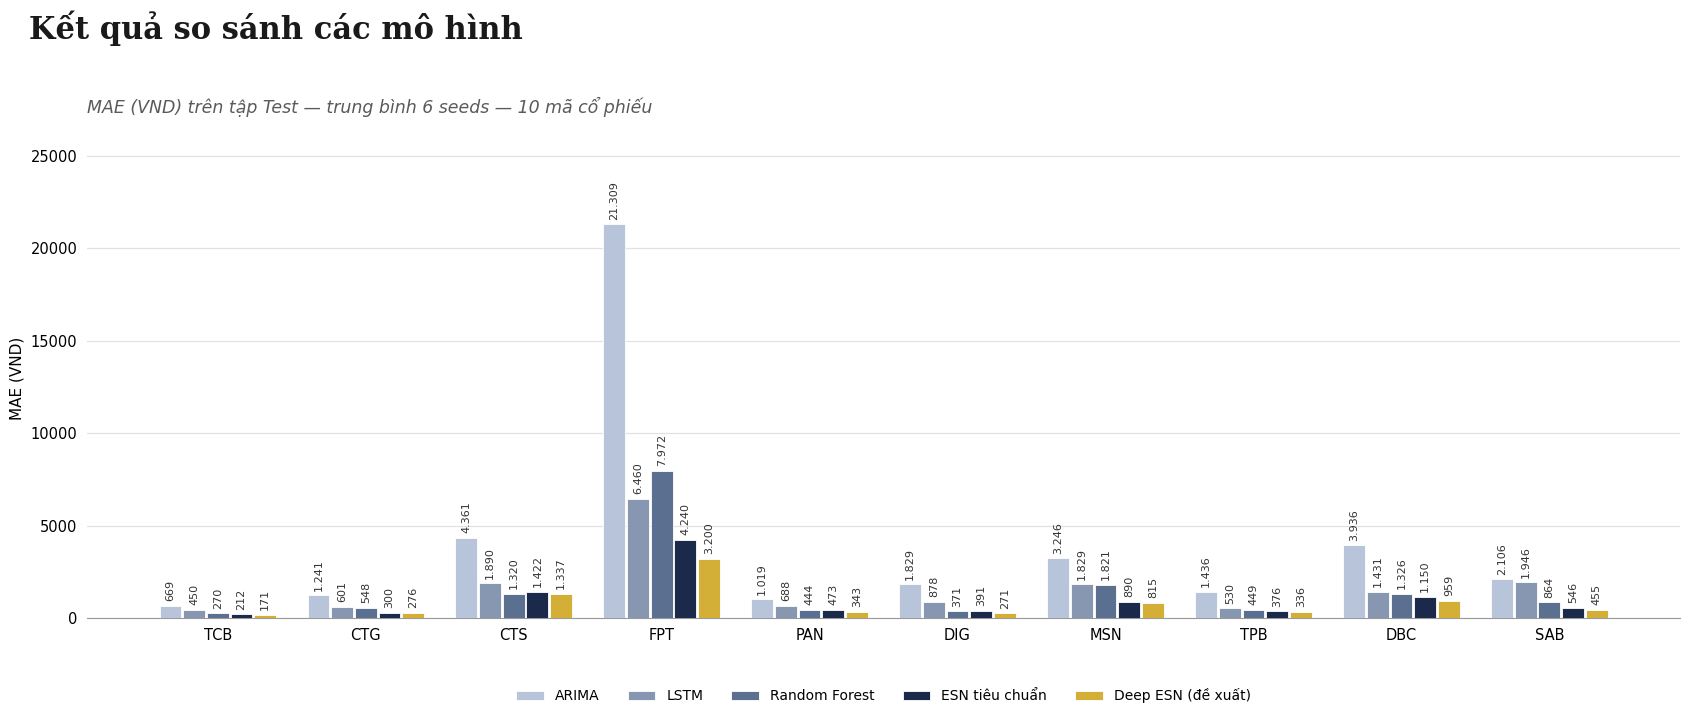


BẢNG MAE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ
        ARIMA     LSTM  Random Forest  ESN tiêu chuẩn  Deep ESN (đề xuất)
TCB    669.42   450.31         269.53          211.95              171.08
CTG   1241.36   600.81         547.89          300.19              276.15
CTS   4361.29  1890.49        1319.64         1421.61             1337.30
FPT  21309.46  6459.89        7972.05         4239.61             3199.86
PAN   1018.58   688.14         444.25          473.12              342.76
DIG   1829.07   877.99         370.53          391.37              271.36
MSN   3246.34  1829.23        1820.91          890.37              814.65
TPB   1436.03   530.28         448.68          375.97              335.75
DBC   3935.91  1430.90        1326.06         1149.95              959.34
SAB   2106.49  1946.03         864.14          545.81              455.17


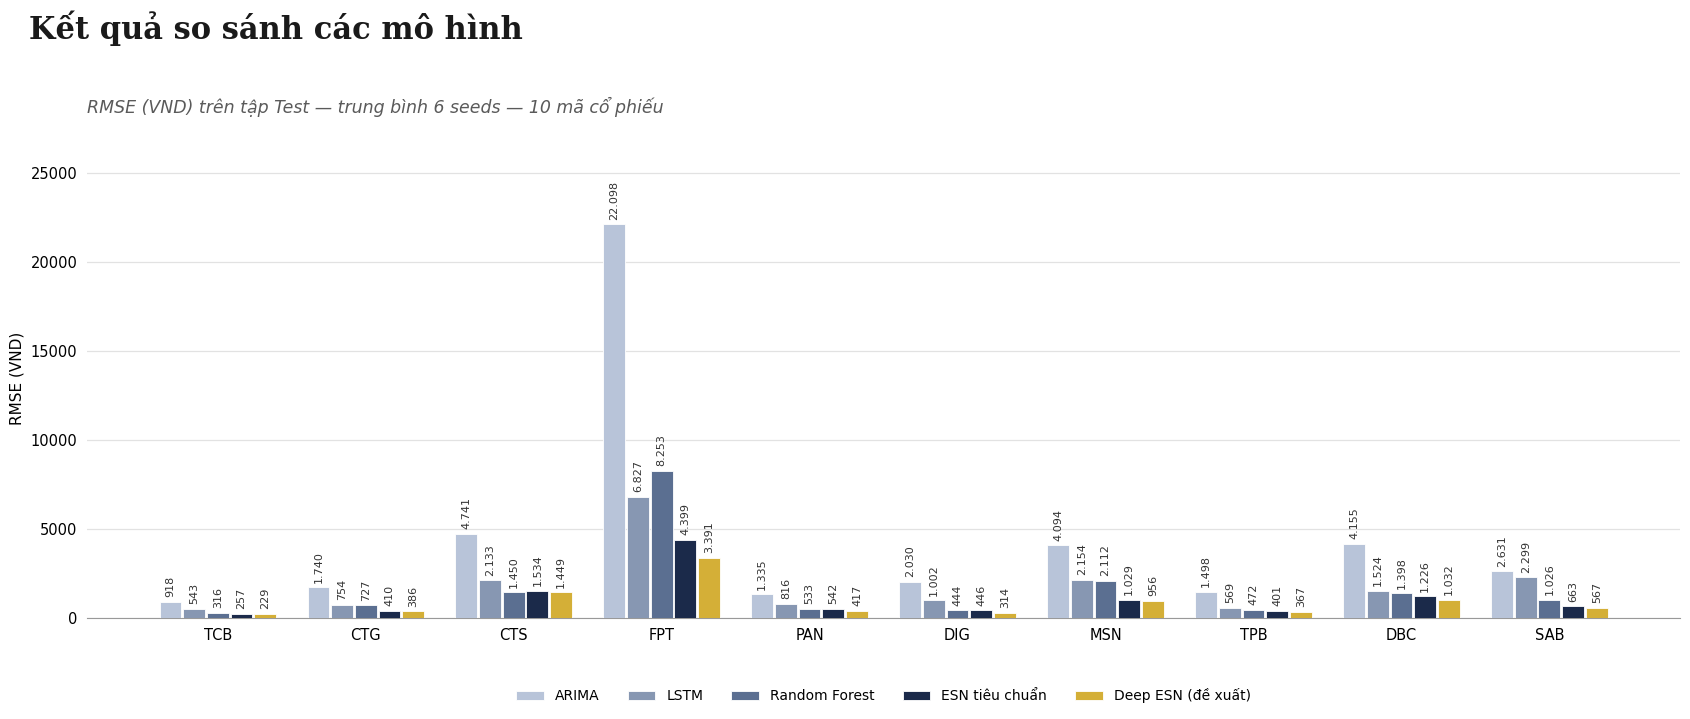


BẢNG RMSE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ
        ARIMA     LSTM  Random Forest  ESN tiêu chuẩn  Deep ESN (đề xuất)
TCB    917.68   542.90         316.16          256.97              228.62
CTG   1740.34   753.55         727.38          409.84              386.10
CTS   4741.33  2132.60        1450.46         1534.45             1449.50
FPT  22098.13  6827.04        8253.01         4398.81             3391.00
PAN   1334.70   816.26         533.21          542.14              417.14
DIG   2030.16  1002.29         444.01          446.45              313.68
MSN   4093.60  2153.95        2111.56         1028.69              955.75
TPB   1498.06   569.46         471.65          400.73              366.70
DBC   4154.90  1523.65        1397.71         1225.86             1032.35
SAB   2631.45  2298.68        1025.87          663.01              567.12


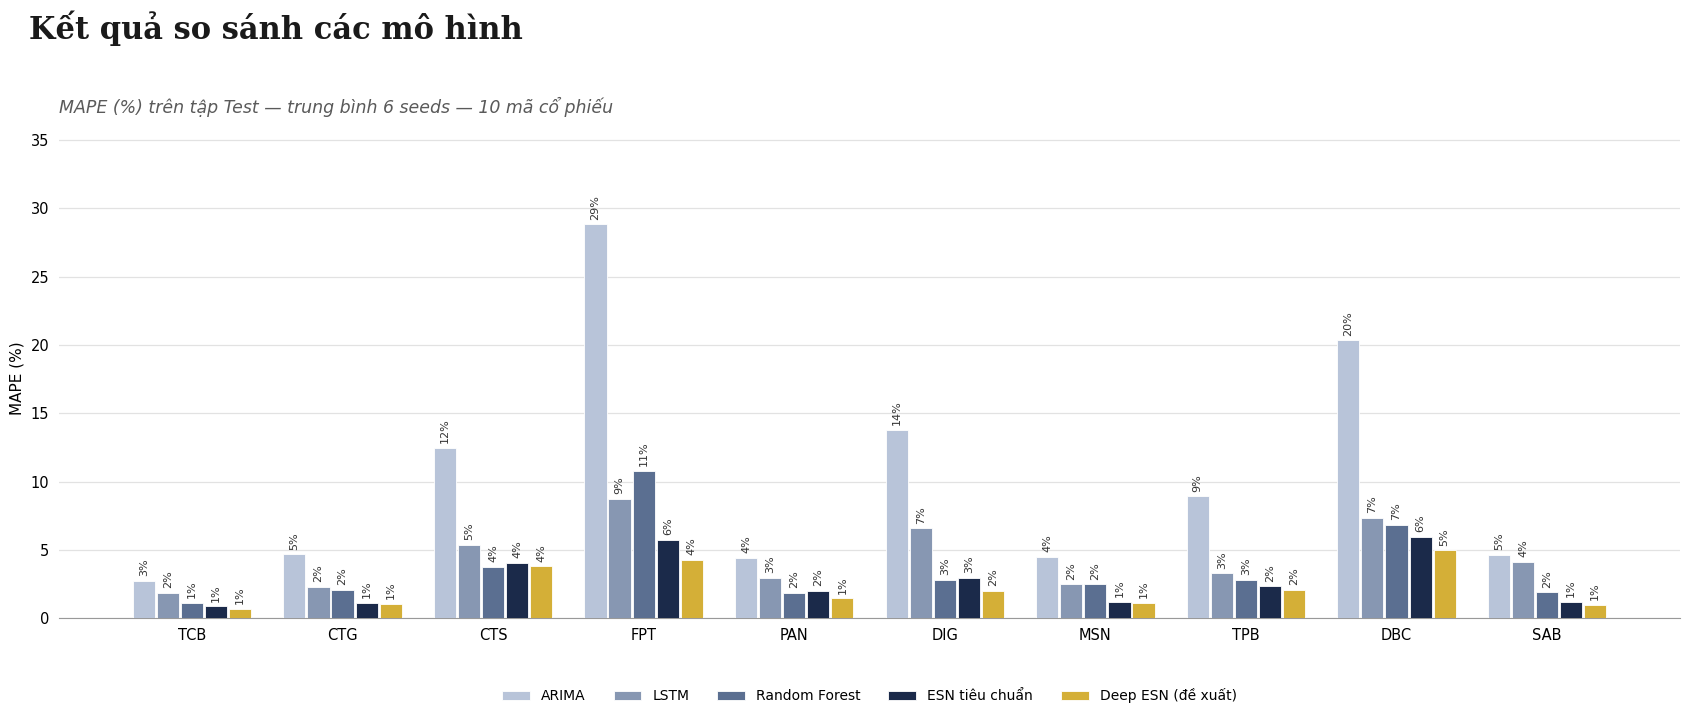


BẢNG MAPE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ
     ARIMA  LSTM  Random Forest  ESN tiêu chuẩn  Deep ESN (đề xuất)
TCB   2.72  1.84           1.12            0.87                0.70
CTG   4.69  2.32           2.08            1.14                1.05
CTS  12.45  5.38           3.76            4.05                3.81
FPT  28.83  8.72          10.77            5.71                4.29
PAN   4.44  2.94           1.85            1.98                1.46
DIG  13.80  6.58           2.81            2.95                2.02
MSN   4.47  2.49           2.49            1.20                1.10
TPB   8.93  3.29           2.79            2.33                2.08
DBC  20.33  7.37           6.84            5.95                4.97
SAB   4.64  4.14           1.89            1.19                0.99


In [11]:
# ============================================================
# BỔ SUNG — Biểu đồ so sánh MAE các mô hình (tất cả các mã)
# ============================================================
_MODEL_MAE_KEY = {
    "ARIMA":              "mae_arima",
    "LSTM":               "mae_lstm",
    "Random Forest":      "mae_rf",
    "ESN tiêu chuẩn":     "mae_esn",
    "Deep ESN (đề xuất)": "mae_deepesn",
}
stock_names   = [s for _, s, _ in STOCKS]
model_names   = list(_MODEL_MAE_KEY.keys())
n_stocks      = len(stock_names)
n_models      = len(model_names)
mae_matrix = np.array([
    [results[stock][_MODEL_MAE_KEY[m]] for m in model_names]
    for stock in stock_names
])  # shape (n_stocks, n_models)
fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.7), 7))
x        = np.arange(n_stocks)
bar_w    = 0.8 / n_models
for j, model in enumerate(model_names):
    vals = mae_matrix[:, j]
    xs   = x + (j - (n_models - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=MODEL_COLORS[model], label=model,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + mae_matrix.max() * 0.012,
                 vn_number(v), ha="center", va="bottom",
                 fontsize=8, color="#333333", rotation=90 if n_stocks > 6 else 0)
ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("MAE (VND)", fontsize=11)
ax.set_ylim(0, mae_matrix.max() * 1.22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=n_models, frameon=False, fontsize=10)
style_slide_chart(
    fig, ax,
    "Kết quả so sánh các mô hình",
    f"MAE (VND) trên tập Test — trung bình 6 seeds — {n_stocks} mã cổ phiếu")
plt.tight_layout()
plt.show()
df_mae_compare = pd.DataFrame(mae_matrix, index=stock_names, columns=model_names)
print("\n" + "="*90)
print("BẢNG MAE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ")
print("="*90)
print(df_mae_compare.round(2).to_string())
print("="*90)


# ============================================================
# BỔ SUNG — Biểu đồ so sánh RMSE các mô hình (tất cả các mã)
# ============================================================
_MODEL_RMSE_KEY = {
    "ARIMA":              "rmse_arima",
    "LSTM":               "rmse_lstm",
    "Random Forest":      "rmse_rf",
    "ESN tiêu chuẩn":     "rmse_esn",
    "Deep ESN (đề xuất)": "rmse_deepesn",
}
rmse_matrix = np.array([
    [results[stock][_MODEL_RMSE_KEY[m]] for m in model_names]
    for stock in stock_names
])  # shape (n_stocks, n_models)
fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.7), 7))
for j, model in enumerate(model_names):
    vals = rmse_matrix[:, j]
    xs   = x + (j - (n_models - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=MODEL_COLORS[model], label=model,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + rmse_matrix.max() * 0.012,
                 vn_number(v), ha="center", va="bottom",
                 fontsize=8, color="#333333", rotation=90 if n_stocks > 6 else 0)
ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("RMSE (VND)", fontsize=11)
ax.set_ylim(0, rmse_matrix.max() * 1.22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=n_models, frameon=False, fontsize=10)
style_slide_chart(
    fig, ax,
    "Kết quả so sánh các mô hình",
    f"RMSE (VND) trên tập Test — trung bình 6 seeds — {n_stocks} mã cổ phiếu")
plt.tight_layout()
plt.show()
df_rmse_compare = pd.DataFrame(rmse_matrix, index=stock_names, columns=model_names)
print("\n" + "="*90)
print("BẢNG RMSE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ")
print("="*90)
print(df_rmse_compare.round(2).to_string())
print("="*90)


# ============================================================
# BỔ SUNG — Biểu đồ so sánh MAPE các mô hình (tất cả các mã)
# ============================================================
_MODEL_MAPE_KEY = {
    "ARIMA":              "mape_arima",
    "LSTM":               "mape_lstm",
    "Random Forest":      "mape_rf",
    "ESN tiêu chuẩn":     "mape_esn",
    "Deep ESN (đề xuất)": "mape_deepesn",
}
mape_matrix = np.array([
    [results[stock][_MODEL_MAPE_KEY[m]] for m in model_names]
    for stock in stock_names
])  # shape (n_stocks, n_models)
fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.7), 7))
for j, model in enumerate(model_names):
    vals = mape_matrix[:, j]
    xs   = x + (j - (n_models - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=MODEL_COLORS[model], label=model,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + mape_matrix.max() * 0.012,
                 f"{vn_number(v)}%", ha="center", va="bottom",
                 fontsize=8, color="#333333", rotation=90 if n_stocks > 6 else 0)
ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_ylim(0, mape_matrix.max() * 1.22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=n_models, frameon=False, fontsize=10)
style_slide_chart(
    fig, ax,
    "Kết quả so sánh các mô hình",
    f"MAPE (%) trên tập Test — trung bình 6 seeds — {n_stocks} mã cổ phiếu")
plt.tight_layout()
plt.show()
df_mape_compare = pd.DataFrame(mape_matrix, index=stock_names, columns=model_names)
print("\n" + "="*90)
print("BẢNG MAPE THEO MÔ HÌNH — TẤT CẢ CÁC MÃ")
print("="*90)
print(df_mape_compare.round(2).to_string())
print("="*90)

In [12]:
# ============================================================
# BỔ SUNG 1 — Bảng best hyperparameters cho từng mô hình
# ============================================================
print("\n" + "="*80)
print(f"BẢNG BEST HYPERPARAMETERS — {', '.join(s for _, s, _ in STOCKS)}")
print("="*80)

rows = []

for _, stock, _ in STOCKS:
    res = results[stock]
    p = res["best_params_deepesn"]
    rows.append({
        "Stock": stock, "Model": "Deep ESN",
        "n_reservoir": p["n_reservoir"], "n_layers": p["n_layers"],
        "spectral_radius": p["sr"], "sparsity": p["sparsity"],
        "ridge_alpha": p["alpha"],
        "units/estimators": "—", "dropout": "—", "lr": "—",
        "ARIMA order": "—",
    })

for _, stock, _ in STOCKS:
    res = results[stock]
    p = res["best_params_esn"]
    rows.append({
        "Stock": stock, "Model": "ESN tiêu chuẩn",
        "n_reservoir": p["n_reservoir"], "n_layers": 1,
        "spectral_radius": p["sr"], "sparsity": p["sparsity"],
        "ridge_alpha": p["alpha"],
        "units/estimators": "—", "dropout": "—", "lr": "—",
        "ARIMA order": "—",
    })

for _, stock, _ in STOCKS:
    res = results[stock]
    p = res["best_params_lstm"]
    rows.append({
        "Stock": stock, "Model": "LSTM",
        "n_reservoir": "—", "n_layers": "—",
        "spectral_radius": "—", "sparsity": "—", "ridge_alpha": "—",
        "units/estimators": p["units"],
        "dropout": p["dropout"], "lr": p["lr"],
        "ARIMA order": "—",
    })

for _, stock, _ in STOCKS:
    res = results[stock]
    p = res["best_params_rf"]
    rows.append({
        "Stock": stock, "Model": "Random Forest",
        "n_reservoir": "—", "n_layers": "—",
        "spectral_radius": "—", "sparsity": "—", "ridge_alpha": "—",
        "units/estimators": p["n_estimators"],
        "dropout": f"max_depth={p['max_depth']}",
        "lr": f"min_split={p['min_samples_split']}",
        "ARIMA order": "—",
    })

for _, stock, _ in STOCKS:
    res = results[stock]
    rows.append({
        "Stock": stock, "Model": "ARIMA",
        "n_reservoir": "—", "n_layers": "—",
        "spectral_radius": "—", "sparsity": "—", "ridge_alpha": "—",
        "units/estimators": "—", "dropout": "—", "lr": "—",
        "ARIMA order": str(res["best_arima_order"]),
    })

df_hyperparams = pd.DataFrame(rows).set_index(["Model", "Stock"])
print(df_hyperparams.to_string())
print("="*80)



BẢNG BEST HYPERPARAMETERS — TCB, CTG, CTS, FPT, PAN, DIG, MSN, TPB, DBC, SAB
                     n_reservoir n_layers spectral_radius sparsity ridge_alpha units/estimators         dropout           lr ARIMA order
Model          Stock                                                                                                                    
Deep ESN       TCB            45        3            0.72     0.08       0.001                —               —            —           —
               CTG            50        3            0.75      0.1      0.0005                —               —            —           —
               CTS            40        2            0.72     0.12       0.003                —               —            —           —
               FPT            45        2            0.75     0.09      0.0005                —               —            —           —
               PAN            45        3            0.75     0.07      0.0005                —     

Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)

── Ablation số tầng reservoir — TCB ──
          n_layers  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  MAPE (mean)  MAPE (std)
Cấu hình                                                                                   
1 lớp            1      193.69      42.77       243.85       50.72         0.80        0.18
2 lớp            2      180.41      29.27       227.32       22.51         0.74        0.13
3 lớp            3      171.08      19.09       228.62       18.32         0.70        0.08
Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)

── Ablation số tầng reservoir — CTG ──
          n_layers  MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  MAPE (mean)  MAPE (std)
Cấu hình                                                                                   
1 lớp            1 

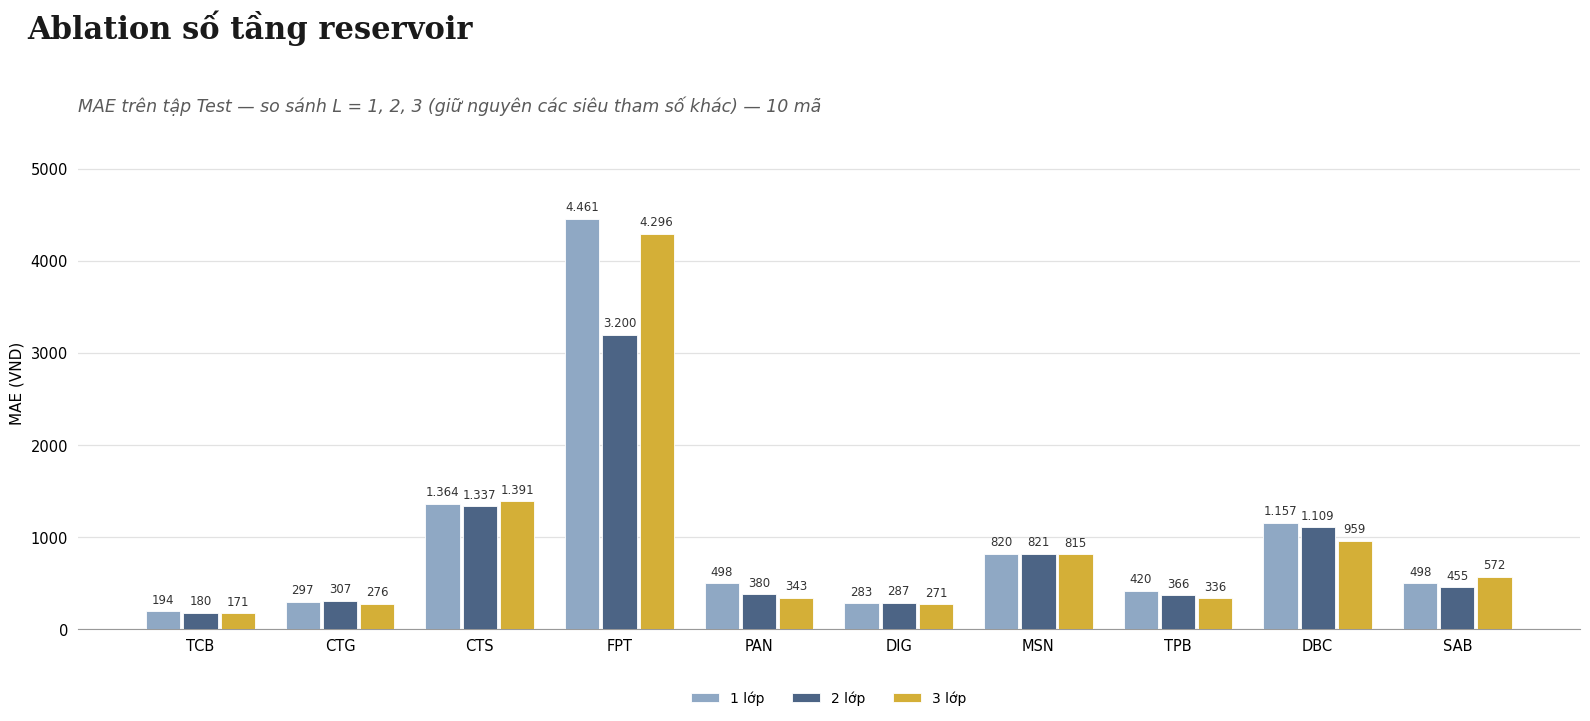


BẢNG MAE ABLATION — TẤT CẢ CÁC MÃ
       1 lớp    2 lớp    3 lớp
TCB   193.69   180.41   171.08
CTG   297.30   306.84   276.15
CTS  1364.41  1337.30  1391.12
FPT  4460.54  3199.86  4295.53
PAN   498.27   380.19   342.76
DIG   282.63   286.53   271.36
MSN   820.16   821.47   814.65
TPB   419.60   366.19   335.75
DBC  1157.27  1108.65   959.34
SAB   498.46   455.17   572.50


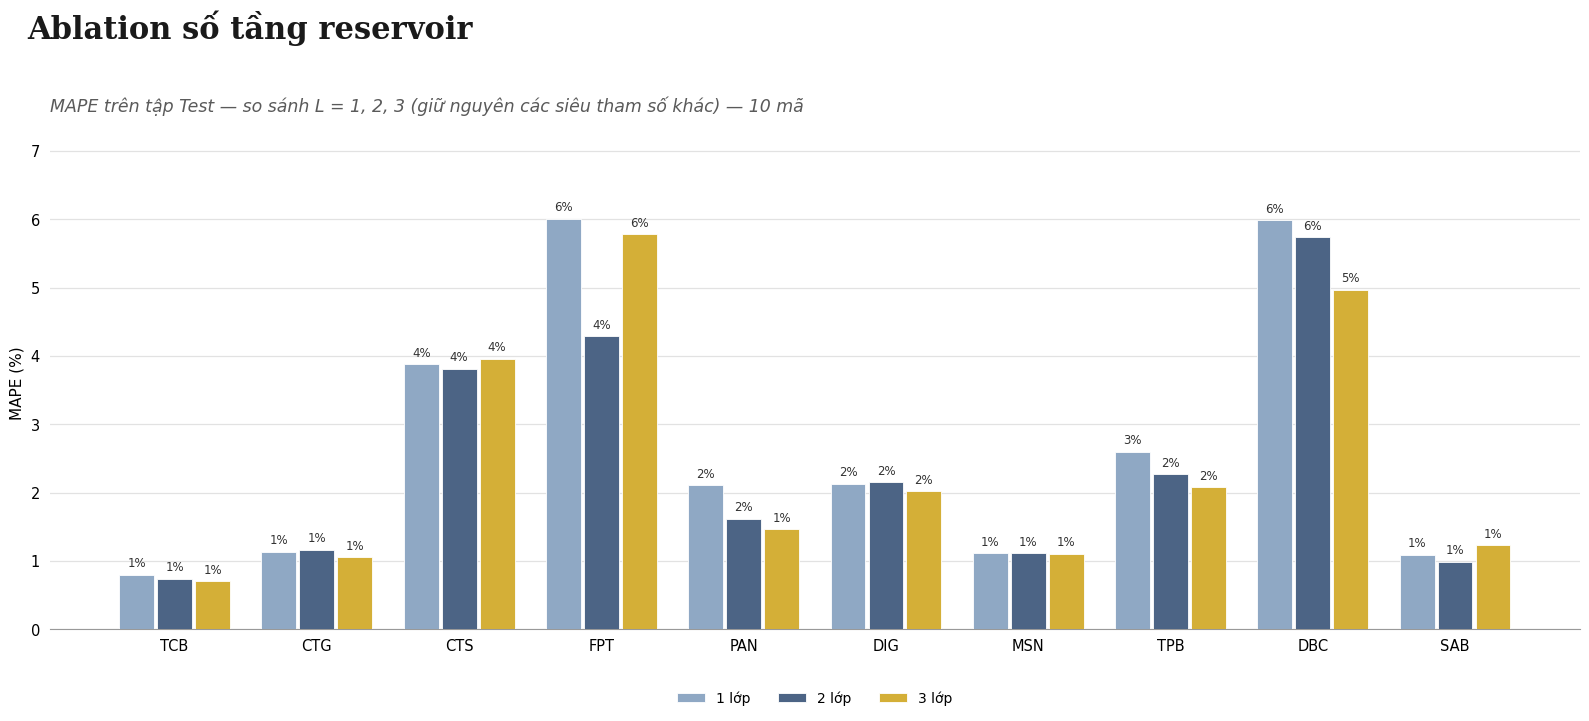


BẢNG MAPE ABLATION — TẤT CẢ CÁC MÃ
     1 lớp  2 lớp  3 lớp
TCB   0.80   0.74   0.70
CTG   1.13   1.16   1.05
CTS   3.88   3.81   3.96
FPT   6.01   4.29   5.78
PAN   2.11   1.62   1.46
DIG   2.13   2.15   2.02
MSN   1.11   1.11   1.10
TPB   2.60   2.27   2.08
DBC   5.99   5.74   4.97
SAB   1.09   0.99   1.23


In [13]:
# ============================================================
# BỔ SUNG 2 — Ablation số tầng reservoir
# n_layers = 1 (ESN), 2 (DeepESN), 3 (DeepESN)
# ============================================================
SEEDS_ABLATION = [0, 42, 123, 456, 789, 1234]
_LAYER_LABEL = {1: "1 lớp", 2: "2 lớp", 3: "3 lớp"}

def run_ablation_layers(filepath, stock_name, loader_type,
                        smooth_window, window, best_params_deepesn):
    train_scaled, val_scaled, test_scaled, scaler, df = load_and_preprocess(
        filepath, smooth_window=smooth_window, loader_type=loader_type)
    train_val_overlap = np.concatenate([train_scaled[-window:], val_scaled])
    val_test_overlap  = np.concatenate([val_scaled[-window:],   test_scaled])
    X_train, y_train = create_sequences(train_scaled,      window)
    X_val,   y_val   = create_sequences(train_val_overlap, window)
    X_test,  y_test  = create_sequences(val_test_overlap,  window)
    X_trainval       = np.concatenate([X_train, X_val])
    y_trainval       = np.concatenate([y_train, y_val])
    last_val_value   = df['Close_Smooth'].iloc[int(0.9 * len(df)) - 1]

    n_res    = best_params_deepesn["n_reservoir"]
    sr       = best_params_deepesn["sr"]
    sparsity = best_params_deepesn["sparsity"]
    alpha    = best_params_deepesn["alpha"]

    ablation_records = []
    for n_layers in [1, 2, 3]:
        label = _LAYER_LABEL[n_layers]
        mae_ab, rmse_ab, mape_ab = [], [], []
        for seed in SEEDS_ABLATION:
            model_ab = DeepESN(
                n_reservoir=n_res, n_layers=n_layers,
                spectral_radius=sr, sparsity=sparsity,
                ridge_alpha=alpha, random_state=seed)
            model_ab.fit(X_trainval, y_trainval)
            y_pred = model_ab.predict(
                X_test, warm_up_states=model_ab.last_states_)
            y_pred_diff = scaler.inverse_transform(
                y_pred.reshape(-1, 1)).flatten()
            y_true_diff = scaler.inverse_transform(
                y_test.reshape(-1, 1)).flatten()
            y_pred_inv  = invert_difference(last_val_value, y_pred_diff)
            y_true_inv  = invert_difference(last_val_value, y_true_diff)
            mae_ab.append(mean_absolute_error(y_true_inv, y_pred_inv))
            rmse_ab.append(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv)))
            mape_ab.append(np.mean(np.abs(
                (y_true_inv - y_pred_inv) /
                (np.abs(y_true_inv) + 1e-10))) * 100)

        ablation_records.append({
            "Cấu hình":    label,
            "n_layers":    n_layers,
            "MAE (mean)":  round(np.mean(mae_ab),  2),
            "MAE (std)":   round(np.std(mae_ab),   2),
            "RMSE (mean)": round(np.mean(rmse_ab), 2),
            "RMSE (std)":  round(np.std(rmse_ab),  2),
            "MAPE (mean)": round(np.mean(mape_ab), 2),
            "MAPE (std)":  round(np.std(mape_ab),  2),
        })

    df_ablation = pd.DataFrame(ablation_records).set_index("Cấu hình")
    print(f"\n── Ablation số tầng reservoir — {stock_name} ──")
    print(df_ablation.to_string())
    return df_ablation


df_ablation_all = {}
for filepath, stock_name, loader_type in STOCKS:
    df_ablation_all[stock_name] = run_ablation_layers(
        filepath=filepath, stock_name=stock_name, loader_type=loader_type,
        smooth_window=5, window=10,
        best_params_deepesn=results[stock_name]["best_params_deepesn"])

# ── Biểu đồ tổng hợp: 1 lớp / 2 lớp / 3 lớp — tất cả các mã ─────────
stock_names  = [s for _, s, _ in STOCKS]
layer_labels = ["1 lớp", "2 lớp", "3 lớp"]
n_stocks     = len(stock_names)
n_layers_    = len(layer_labels)

mae_ablation_matrix = np.array([
    [df_ablation_all[s].loc[lbl, "MAE (mean)"] for lbl in layer_labels]
    for s in stock_names
])

fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.6), 7))
x     = np.arange(n_stocks)
bar_w = 0.8 / n_layers_

for j, lbl in enumerate(layer_labels):
    vals = mae_ablation_matrix[:, j]
    xs   = x + (j - (n_layers_ - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=ABLATION_COLORS[lbl], label=lbl,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + mae_ablation_matrix.max() * 0.012,
                 vn_number(v), ha="center", va="bottom",
                 fontsize=8.5, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("MAE (VND)", fontsize=11)
ax.set_ylim(0, mae_ablation_matrix.max() * 1.2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
          ncol=n_layers_, frameon=False, fontsize=10)

style_slide_chart(
    fig, ax,
    "Ablation số tầng reservoir",
    f"MAE trên tập Test — so sánh L = 1, 2, 3 (giữ nguyên các siêu tham số khác) — {n_stocks} mã")

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("BẢNG MAE ABLATION — TẤT CẢ CÁC MÃ")
print("="*90)
print(pd.DataFrame(mae_ablation_matrix, index=stock_names, columns=layer_labels).round(2).to_string())
print("="*90)
# ── Biểu đồ tổng hợp MAPE: 1 lớp / 2 lớp / 3 lớp — tất cả các mã ─────────
mape_ablation_matrix = np.array([
    [df_ablation_all[s].loc[lbl, "MAPE (mean)"] for lbl in layer_labels]
    for s in stock_names
])

fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.6), 7))

for j, lbl in enumerate(layer_labels):
    vals = mape_ablation_matrix[:, j]
    xs   = x + (j - (n_layers_ - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=ABLATION_COLORS[lbl], label=lbl,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + mape_ablation_matrix.max() * 0.012,
                 f"{vn_number(v)}%", ha="center", va="bottom",
                 fontsize=8.5, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_ylim(0, mape_ablation_matrix.max() * 1.2)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
          ncol=n_layers_, frameon=False, fontsize=10)

style_slide_chart(
    fig, ax,
    "Ablation số tầng reservoir",
    f"MAPE trên tập Test — so sánh L = 1, 2, 3 (giữ nguyên các siêu tham số khác) — {n_stocks} mã")

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("BẢNG MAPE ABLATION — TẤT CẢ CÁC MÃ")
print("="*90)
print(pd.DataFrame(mape_ablation_matrix, index=stock_names, columns=layer_labels).round(2).to_string())
print("="*90)

Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)

── Sensitivity Analysis — smooth_window — TCB ──
               MAE (mean)  MAE (std)  RMSE (mean)  RMSE (std)  MAPE (mean)  MAPE (std)
smooth_window                                                                         
3                  315.48      54.80       388.71       51.13         1.29        0.23
5                  171.08      19.09       228.62       18.32         0.70        0.08
7                  138.75      15.72       170.39       16.99         0.57        0.07

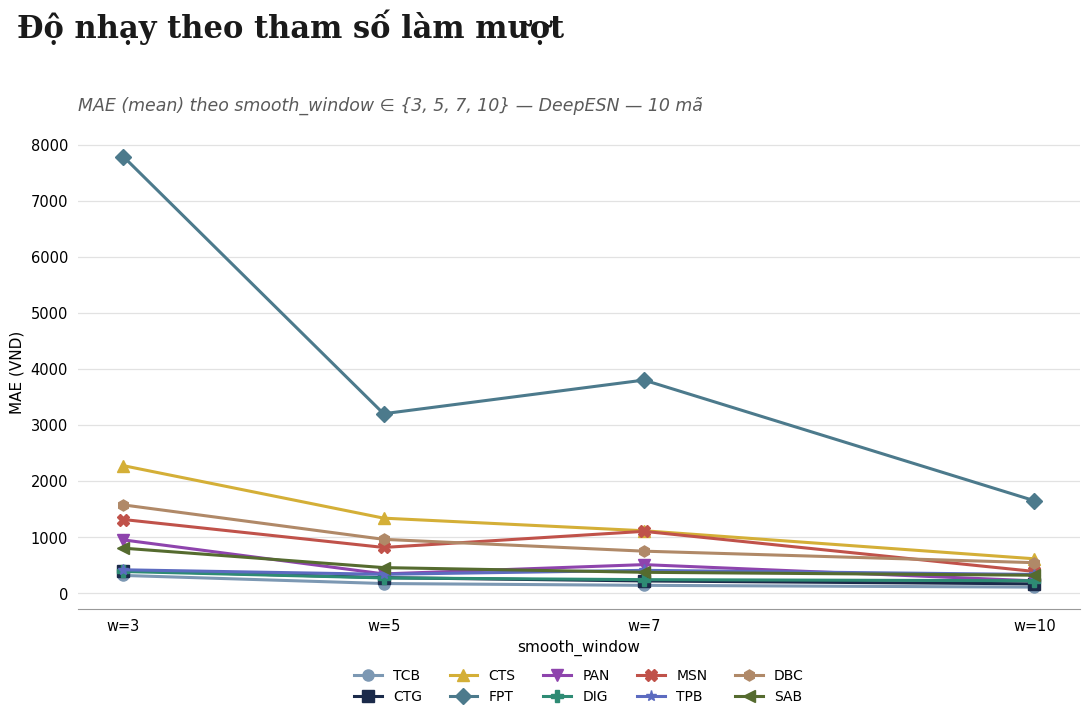


BẢNG MAE THEO SMOOTH_WINDOW — TẤT CẢ CÁC MÃ
       TCB     CTG      CTS      FPT     PAN     DIG      MSN     TPB      DBC     SAB
3   315.48  400.64  2273.51  7786.96  949.58  386.00  1313.19  416.01  1573.60  801.84
5   171.08  276.15  1337.30  3199.86  342.76  271.36   814.65  335.75   959.34  455.17
7   138.75  217.06  1112.39  3800.37  508.30  240.41  1101.99  406.24   748.43  371.49
10  107.18  165.32   612.32  1647.73  218.84  220.45   386.34  333.11   543.21  319.37


In [14]:
# ============================================================
# BỔ SUNG 3 — Sensitivity Analysis: smooth_window = 3, 5, 7, 10
# ============================================================
SEEDS_SENS = [0, 42, 123, 456, 789, 1234]

def run_sensitivity_smoothing(filepath, stock_name, loader_type,
                               window, best_params_deepesn):
    smooth_windows = [3, 5, 7, 10]
    sens_records   = []
    n_res    = best_params_deepesn["n_reservoir"]
    n_layers = best_params_deepesn["n_layers"]
    sr       = best_params_deepesn["sr"]
    sparsity = best_params_deepesn["sparsity"]
    alpha    = best_params_deepesn["alpha"]

    for sw in smooth_windows:
        train_scaled, val_scaled, test_scaled, scaler, df = load_and_preprocess(
            filepath, smooth_window=sw, loader_type=loader_type)
        train_val_overlap = np.concatenate([train_scaled[-window:], val_scaled])
        val_test_overlap  = np.concatenate([val_scaled[-window:],   test_scaled])
        X_train, y_train  = create_sequences(train_scaled,      window)
        X_val,   y_val    = create_sequences(train_val_overlap, window)
        X_test,  y_test   = create_sequences(val_test_overlap,  window)
        X_trainval        = np.concatenate([X_train, X_val])
        y_trainval        = np.concatenate([y_train, y_val])
        last_val_value    = df['Close_Smooth'].iloc[int(0.9 * len(df)) - 1]

        mae_sw, rmse_sw, mape_sw = [], [], []
        for seed in SEEDS_SENS:
            model_sw = DeepESN(
                n_reservoir=n_res, n_layers=n_layers,
                spectral_radius=sr, sparsity=sparsity,
                ridge_alpha=alpha, random_state=seed)
            model_sw.fit(X_trainval, y_trainval)
            y_pred = model_sw.predict(
                X_test, warm_up_states=model_sw.last_states_)
            y_pred_diff = scaler.inverse_transform(
                y_pred.reshape(-1, 1)).flatten()
            y_true_diff = scaler.inverse_transform(
                y_test.reshape(-1, 1)).flatten()
            y_pred_inv  = invert_difference(last_val_value, y_pred_diff)
            y_true_inv  = invert_difference(last_val_value, y_true_diff)
            mae_sw.append(mean_absolute_error(y_true_inv, y_pred_inv))
            rmse_sw.append(np.sqrt(mean_squared_error(y_true_inv, y_pred_inv)))
            mape_sw.append(np.mean(np.abs(
                (y_true_inv - y_pred_inv) /
                (np.abs(y_true_inv) + 1e-10))) * 100)

        sens_records.append({
            "smooth_window": sw,
            "MAE (mean)":    round(np.mean(mae_sw),  2),
            "MAE (std)":     round(np.std(mae_sw),   2),
            "RMSE (mean)":   round(np.mean(rmse_sw), 2),
            "RMSE (std)":    round(np.std(rmse_sw),  2),
            "MAPE (mean)":   round(np.mean(mape_sw), 2),
            "MAPE (std)":    round(np.std(mape_sw),  2),
        })

    df_sens = pd.DataFrame(sens_records).set_index("smooth_window")
    print(f"\n── Sensitivity Analysis — smooth_window — {stock_name} ──")
    print(df_sens.to_string())
    return df_sens


df_sens_all = {}
for filepath, stock_name, loader_type in STOCKS:
    df_sens_all[stock_name] = run_sensitivity_smoothing(
        filepath=filepath, stock_name=stock_name, loader_type=loader_type,
        window=10, best_params_deepesn=results[stock_name]["best_params_deepesn"])

# ── Biểu đồ tổng hợp: MAE theo smooth_window — tất cả các mã ────────
smooth_windows = [3, 5, 7, 10]

fig, ax = plt.subplots(figsize=(11, 7))
for _, stock_name, _ in STOCKS:
    means = df_sens_all[stock_name]["MAE (mean)"].values
    ax.plot(smooth_windows, means,
            marker=STOCK_MARKER[stock_name],
            color=STOCK_COLORS[stock_name],
            linewidth=2.2, markersize=8,
            label=stock_name, zorder=3)

ax.set_xlabel("smooth_window", fontsize=11)
ax.set_ylabel("MAE (VND)", fontsize=11)
ax.set_xticks(smooth_windows)
ax.set_xticklabels([f"w={w}" for w in smooth_windows], fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1),
          ncol=min(len(STOCKS), 5), frameon=False, fontsize=10)

style_slide_chart(
    fig, ax,
    "Độ nhạy theo tham số làm mượt",
    f"MAE (mean) theo smooth_window ∈ {{3, 5, 7, 10}} — DeepESN — {len(STOCKS)} mã")

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("BẢNG MAE THEO SMOOTH_WINDOW — TẤT CẢ CÁC MÃ")
print("="*90)
print(pd.DataFrame({s: df_sens_all[s]["MAE (mean)"].values for _, s, _ in STOCKS},
                    index=smooth_windows).round(2).to_string())
print("="*90)



XAI — INPUT LAG IMPORTANCE — TCB
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)

  Best hyperparams [TCB]:
    n_reservoir     = 45
    n_layers        = 3
    spectral_radius = 0.72
    sparsity        = 0.08
    ridge_alpha     = 0.001

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline), mean ± std

  ── Model seed = 0 ──
    Baseline MAE = 181.41
  ── Model seed = 42 ──
    Baseline MAE = 146.10
  ── Model seed = 123 ──
    Baseline MAE = 172.29
  ── Model seed = 456 ──
    Baseline MAE = 197.35
  ── Model seed = 789 ──
    Baseline MAE = 183.11
  ── Model seed = 1234 ──
    Baseline MAE = 146.20

── Permutation Importance — tổng hợp 6 seeds × 30 shuffles ──
     lag_1: ΔMAE = +161.9246 ± 125.9619
     lag_2: ΔMAE = +197.2513 ± 134.7870
     lag_3: ΔMAE = +372.6438 ± 295.4915
     lag_4: ΔMAE = +2

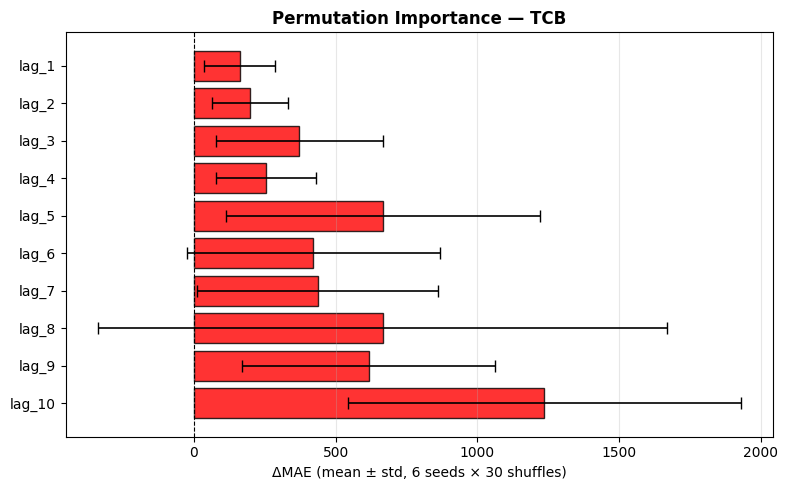


Xếp hạng lag theo ΔMAE — TCB
(tổng 180 mẫu/lag)
       lag  ΔMAE mean   ΔMAE std  n_samples
1   lag_10  1236.3737   693.5151        180
2    lag_8   665.9993  1004.2923        180
3    lag_5   665.8881   553.3926        180
4    lag_9   617.2374   446.4987        180
5    lag_7   436.3327   425.4035        180
6    lag_6   421.6064   445.6147        180
7    lag_3   372.6438   295.4915        180
8    lag_4   255.5204   176.5233        180
9    lag_2   197.2513   134.7870        180
10   lag_1   161.9246   125.9619        180

XAI — INPUT LAG IMPORTANCE — CTG
Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)

  Best hyperparams [CTG]:
    n_reservoir     = 50
    n_layers        = 3
    spectral_radius = 0.75
    sparsity        = 0.1
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE

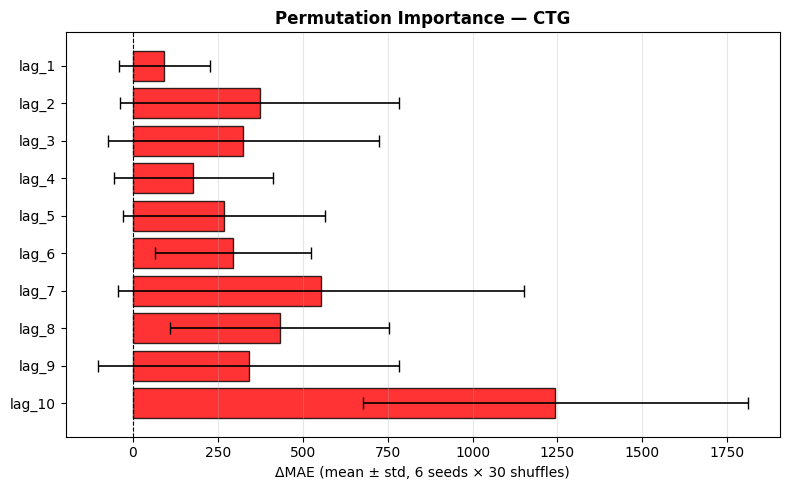


Xếp hạng lag theo ΔMAE — CTG
(tổng 180 mẫu/lag)
       lag  ΔMAE mean  ΔMAE std  n_samples
1   lag_10  1243.2257  566.5562        180
2    lag_7   554.5414  597.5956        180
3    lag_8   432.4562  322.8002        180
4    lag_2   372.6739  411.9609        180
5    lag_9   340.6154  443.0515        180
6    lag_3   325.4259  397.9916        180
7    lag_6   295.5239  230.1186        180
8    lag_5   268.9227  297.7058        180
9    lag_4   178.1329  233.8768        180
10   lag_1    92.6161  134.2420        180

XAI — INPUT LAG IMPORTANCE — CTS
Train : 776 ngày (2021-04-14 → 2024-05-24)
Val   : 97 ngày (2024-05-27 → 2024-10-10)
Test  : 97 ngày (2024-10-11 → 2025-03-04)

  Best hyperparams [CTS]:
    n_reservoir     = 40
    n_layers        = 2
    spectral_radius = 0.72
    sparsity        = 0.12
    ridge_alpha     = 0.003

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline), 

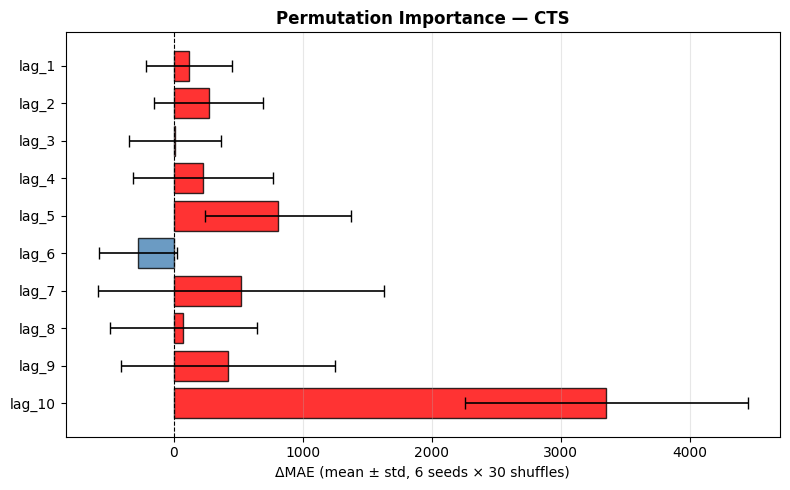


Xếp hạng lag theo ΔMAE — CTS
(tổng 180 mẫu/lag)
       lag  ΔMAE mean   ΔMAE std  n_samples
1   lag_10  3351.1122  1095.4931        180
2    lag_5   809.5108   568.2504        180
3    lag_7   520.9647  1105.6673        180
4    lag_9   420.6823   830.8077        180
5    lag_2   270.6281   423.0098        180
6    lag_4   229.8257   540.9715        180
7    lag_1   118.3112   333.2994        180
8    lag_8    73.7829   570.7476        180
9    lag_3    12.8980   356.1660        180
10   lag_6  -274.9015   303.1242        180

XAI — INPUT LAG IMPORTANCE — FPT
Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)

  Best hyperparams [FPT]:
    n_reservoir     = 45
    n_layers        = 2
    spectral_radius = 0.75
    sparsity        = 0.09
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - M

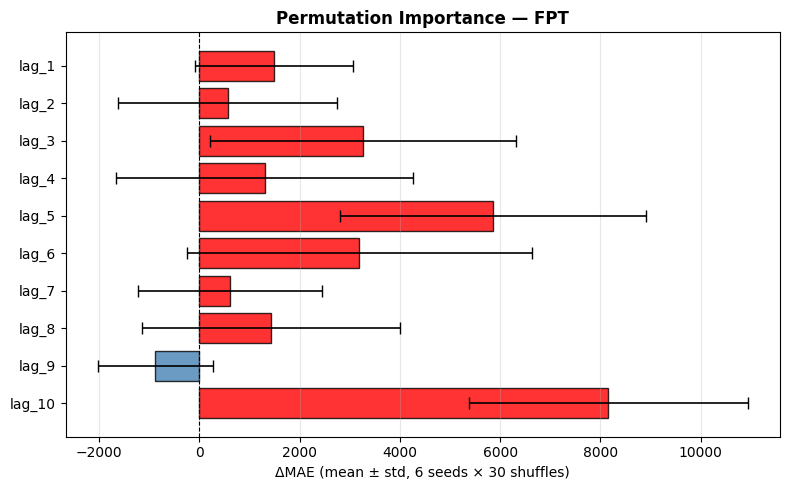


Xếp hạng lag theo ΔMAE — FPT
(tổng 180 mẫu/lag)
       lag  ΔMAE mean   ΔMAE std  n_samples
1   lag_10  8155.2729  2779.1219        180
2    lag_5  5863.9310  3052.0727        180
3    lag_3  3270.7565  3052.4451        180
4    lag_6  3193.3534  3436.6786        180
5    lag_1  1483.7514  1575.2350        180
6    lag_8  1426.7254  2572.5711        180
7    lag_4  1302.8976  2959.7844        180
8    lag_7   613.2035  1830.7002        180
9    lag_2   564.5093  2187.9242        180
10   lag_9  -876.4868  1142.5847        180

XAI — INPUT LAG IMPORTANCE — PAN
Train : 800 ngày (2022-07-14 → 2025-09-26)
Val   : 100 ngày (2025-09-29 → 2026-02-24)
Test  : 100 ngày (2026-02-25 → 2026-07-17)

  Best hyperparams [PAN]:
    n_reservoir     = 45
    n_layers        = 3
    spectral_radius = 0.75
    sparsity        = 0.07
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - M

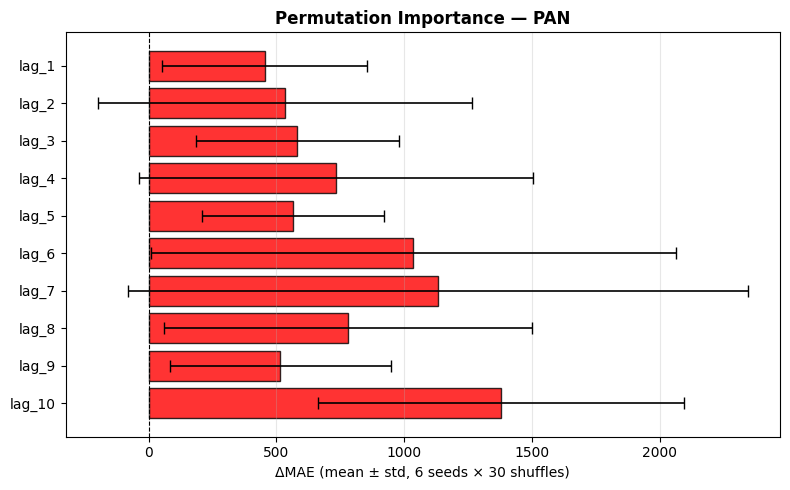


Xếp hạng lag theo ΔMAE — PAN
(tổng 180 mẫu/lag)
       lag  ΔMAE mean   ΔMAE std  n_samples
1   lag_10  1377.7789   716.4272        180
2    lag_7  1132.1918  1212.3765        180
3    lag_6  1036.9238  1026.6525        180
4    lag_8   781.4769   719.6672        180
5    lag_4   734.0903   771.6560        180
6    lag_3   581.6399   396.6527        180
7    lag_5   566.4634   356.2040        180
8    lag_2   533.8281   731.1610        180
9    lag_9   515.8975   431.9414        180
10   lag_1   455.4691   401.0938        180

XAI — INPUT LAG IMPORTANCE — DIG
Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)

  Best hyperparams [DIG]:
    n_reservoir     = 40
    n_layers        = 3
    spectral_radius = 0.75
    sparsity        = 0.1
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MA

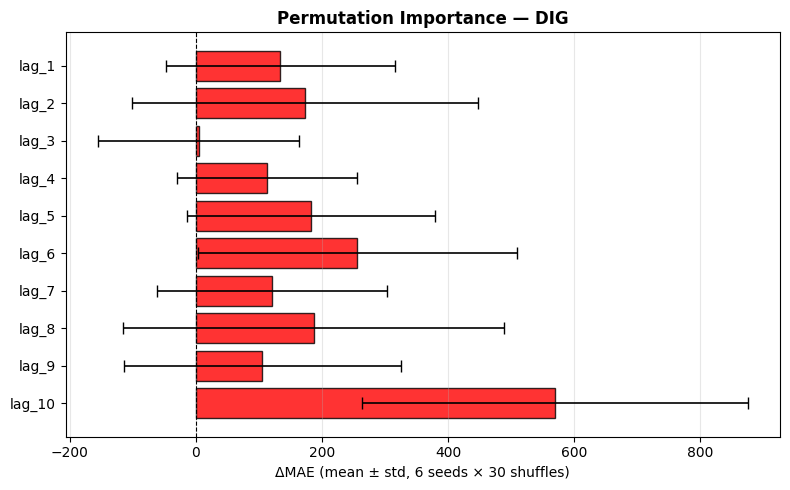


Xếp hạng lag theo ΔMAE — DIG
(tổng 180 mẫu/lag)
       lag  ΔMAE mean  ΔMAE std  n_samples
1   lag_10   569.3292  305.4948        180
2    lag_6   256.2358  253.0749        180
3    lag_8   187.0712  302.2774        180
4    lag_5   182.5700  196.4461        180
5    lag_2   173.5320  273.8515        180
6    lag_1   133.9802  181.1780        180
7    lag_7   120.4966  182.5162        180
8    lag_4   113.4953  142.7966        180
9    lag_9   105.8723  220.3374        180
10   lag_3     4.4367  159.0494        180

XAI — INPUT LAG IMPORTANCE — MSN
Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ngày (2026-02-23 → 2026-07-15)

  Best hyperparams [MSN]:
    n_reservoir     = 45
    n_layers        = 3
    spectral_radius = 0.75
    sparsity        = 0.1
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline)

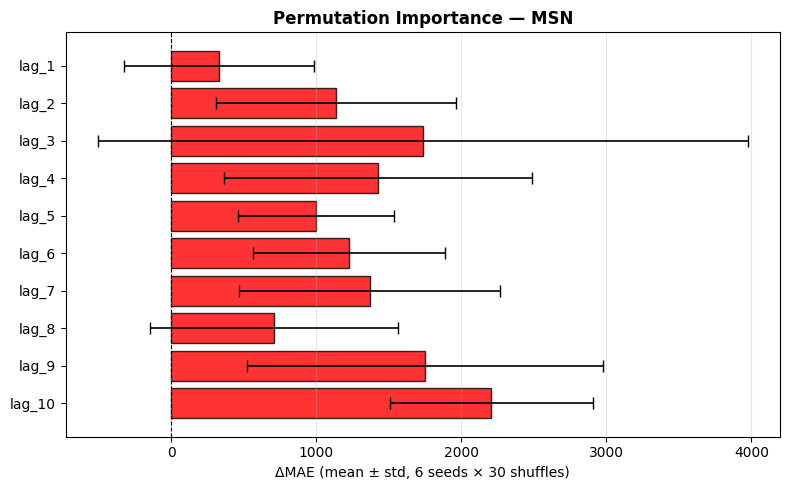


Xếp hạng lag theo ΔMAE — MSN
(tổng 180 mẫu/lag)
       lag  ΔMAE mean   ΔMAE std  n_samples
1   lag_10  2206.5336   698.5796        180
2    lag_9  1747.9610  1229.7757        180
3    lag_3  1733.8803  2239.4209        180
4    lag_4  1423.1373  1060.8657        180
5    lag_7  1366.0859   902.6903        180
6    lag_6  1225.2750   660.9715        180
7    lag_2  1135.9851   826.5251        180
8    lag_5   993.8392   537.6723        180
9    lag_8   706.4459   854.7440        180
10   lag_1   327.7208   651.9972        180

XAI — INPUT LAG IMPORTANCE — TPB
Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ngày (2026-02-23 → 2026-07-15)

  Best hyperparams [TPB]:
    n_reservoir     = 40
    n_layers        = 3
    spectral_radius = 0.73
    sparsity        = 0.1
    ridge_alpha     = 0.003

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE

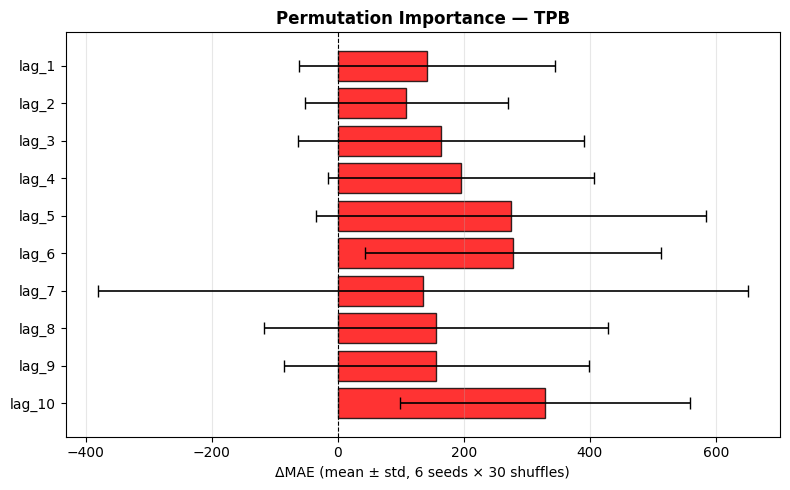


Xếp hạng lag theo ΔMAE — TPB
(tổng 180 mẫu/lag)
       lag  ΔMAE mean  ΔMAE std  n_samples
1   lag_10   328.6467  229.4950        180
2    lag_6   277.7875  234.6389        180
3    lag_5   275.2204  309.5191        180
4    lag_4   195.7840  211.1833        180
5    lag_3   163.9860  226.6999        180
6    lag_9   155.9503  242.0092        180
7    lag_8   155.5590  273.3487        180
8    lag_1   141.3312  202.9874        180
9    lag_7   134.9123  515.2185        180
10   lag_2   108.8674  161.0366        180

XAI — INPUT LAG IMPORTANCE — DBC
Train : 800 ngày (2022-07-14 → 2025-09-26)
Val   : 100 ngày (2025-09-29 → 2026-02-24)
Test  : 100 ngày (2026-02-25 → 2026-07-17)

  Best hyperparams [DBC]:
    n_reservoir     = 50
    n_layers        = 3
    spectral_radius = 0.74
    sparsity        = 0.08
    ridge_alpha     = 0.002

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline)

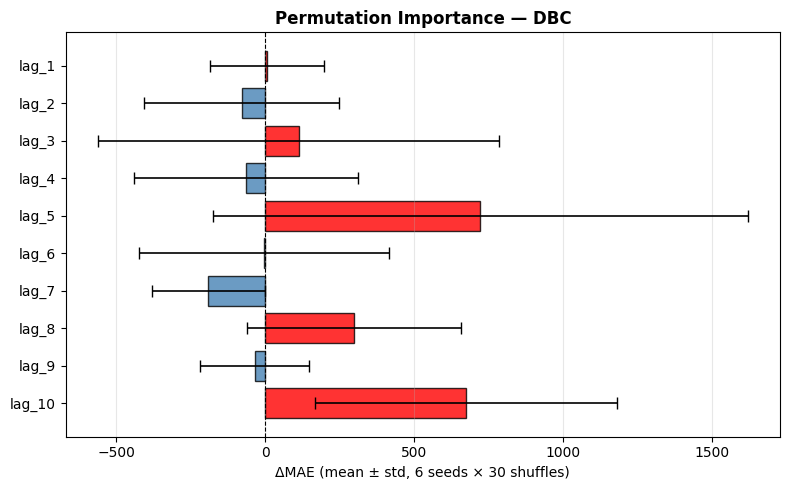


Xếp hạng lag theo ΔMAE — DBC
(tổng 180 mẫu/lag)
       lag  ΔMAE mean  ΔMAE std  n_samples
1    lag_5   721.5546  898.0916        180
2   lag_10   672.7112  506.9728        180
3    lag_8   298.6026  359.5377        180
4    lag_3   112.2355  672.9004        180
5    lag_1     5.2540  192.0554        180
6    lag_6    -3.1826  420.3698        180
7    lag_9   -35.4552  183.0611        180
8    lag_4   -63.9561  376.9698        180
9    lag_2   -79.3718  328.5850        180
10   lag_7  -191.2724  189.9423        180

XAI — INPUT LAG IMPORTANCE — SAB
Train : 800 ngày (2022-07-13 → 2025-09-25)
Val   : 100 ngày (2025-09-26 → 2026-02-23)
Test  : 100 ngày (2026-02-24 → 2026-07-16)

  Best hyperparams [SAB]:
    n_reservoir     = 45
    n_layers        = 2
    spectral_radius = 0.72
    sparsity        = 0.12
    ridge_alpha     = 0.0005

  Model seeds : [0, 42, 123, 456, 789, 1234]
  Shuffle/lag : 30 lần (rep seed 0..29)
  Tổng mẫu/lag: 180 ΔMAE
  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline

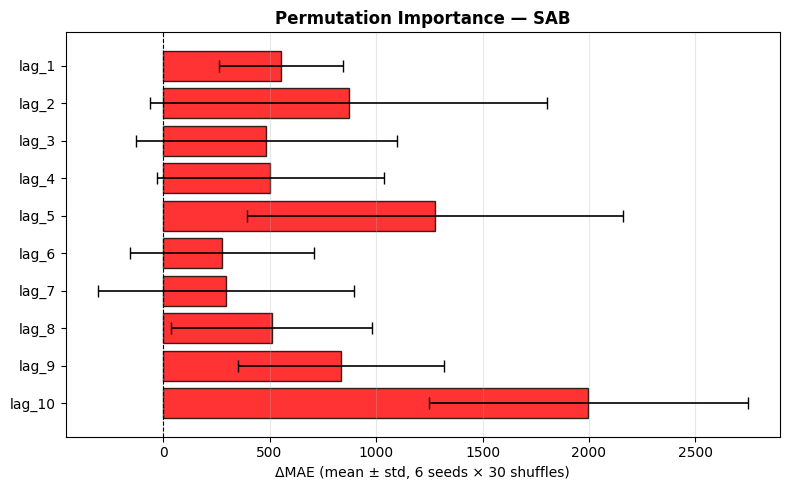


Xếp hạng lag theo ΔMAE — SAB
(tổng 180 mẫu/lag)
       lag  ΔMAE mean  ΔMAE std  n_samples
1   lag_10  1996.8800  747.5495        180
2    lag_5  1277.7333  884.2398        180
3    lag_2   871.3429  930.4174        180
4    lag_9   836.3089  482.6019        180
5    lag_1   554.3281  289.5951        180
6    lag_8   509.1716  472.1236        180
7    lag_4   503.7304  533.5861        180
8    lag_3   485.5629  611.9066        180
9    lag_7   296.0890  600.7642        180
10   lag_6   276.0211  433.6636        180


In [15]:
# ============================================================
# BỔ SUNG 4 — XAI: Permutation Importance (multi-seed model)
# ============================================================

def run_xai(filepath, stock_name, loader_type,
            smooth_window, window, best_params_deepesn):

    print(f"\n{'='*65}")
    print(f"XAI — INPUT LAG IMPORTANCE — {stock_name}")
    print("="*65)

    train_scaled, val_scaled, test_scaled, scaler, df = load_and_preprocess(
        filepath, smooth_window=smooth_window, loader_type=loader_type)
    train_val_overlap = np.concatenate([train_scaled[-window:], val_scaled])
    val_test_overlap  = np.concatenate([val_scaled[-window:],   test_scaled])
    X_train, y_train  = create_sequences(train_scaled,      window)
    X_val,   y_val    = create_sequences(train_val_overlap, window)
    X_test,  y_test   = create_sequences(val_test_overlap,  window)
    X_trainval        = np.concatenate([X_train, X_val])
    y_trainval        = np.concatenate([y_train, y_val])
    last_val_value    = df['Close_Smooth'].iloc[int(0.9 * len(df)) - 1]

    # In bộ siêu tham số tốt nhất
    print(f"\n  Best hyperparams [{stock_name}]:")
    print(f"    n_reservoir     = {best_params_deepesn['n_reservoir']}")
    print(f"    n_layers        = {best_params_deepesn['n_layers']}")
    print(f"    spectral_radius = {best_params_deepesn['sr']}")
    print(f"    sparsity        = {best_params_deepesn['sparsity']}")
    print(f"    ridge_alpha     = {best_params_deepesn['alpha']}")

    SEEDS_XAI = [0, 42, 123, 456, 789, 1234]  # seeds cho model
    N_SHUFFLE  = 30                             # số lần shuffle mỗi lag

    print(f"\n  Model seeds : {SEEDS_XAI}")
    print(f"  Shuffle/lag : {N_SHUFFLE} lần (rep seed 0..{N_SHUFFLE-1})")
    print(f"  Tổng mẫu/lag: {len(SEEDS_XAI) * N_SHUFFLE} ΔMAE")
    print(f"  Báo cáo: ΔMAE = MAE(shuffle) - MAE(baseline), mean ± std\n")

    # delta_all[lag_idx] = list tất cả ΔMAE từ mọi seed × mọi shuffle
    delta_all = [[] for _ in range(window)]

    for model_seed in SEEDS_XAI:
        print(f"  ── Model seed = {model_seed} ──")

        # Train model với seed này
        model_xai = DeepESN(
            n_reservoir=best_params_deepesn["n_reservoir"],
            n_layers=best_params_deepesn["n_layers"],
            spectral_radius=best_params_deepesn["sr"],
            sparsity=best_params_deepesn["sparsity"],
            ridge_alpha=best_params_deepesn["alpha"],
            random_state=model_seed)
        model_xai.fit(X_trainval, y_trainval)

        # Lưu warm-up state ngay sau fit
        warm_up_for_xai = [s.copy() for s in model_xai.last_states_]

        # Baseline với warm-up nhất quán
        baseline_pred  = model_xai.predict(
            X_test, warm_up_states=warm_up_for_xai)
        y_pred_diff_bl = scaler.inverse_transform(
            baseline_pred.reshape(-1, 1)).flatten()
        y_true_diff    = scaler.inverse_transform(
            y_test.reshape(-1, 1)).flatten()
        y_pred_inv_bl  = invert_difference(last_val_value, y_pred_diff_bl)
        y_true_inv_bl  = invert_difference(last_val_value, y_true_diff)
        baseline_mae   = mean_absolute_error(y_true_inv_bl, y_pred_inv_bl)
        print(f"    Baseline MAE = {baseline_mae:.2f}")

        # Permutation: shuffle mỗi lag N_SHUFFLE lần
        for lag_idx in range(window):
            for rep in range(N_SHUFFLE):
                X_test_perm = X_test.copy()
                rng = np.random.RandomState(rep)
                X_test_perm[:, lag_idx] = rng.permutation(
                    X_test_perm[:, lag_idx])

                #  Cùng warm-up state cho mọi lần shuffle
                perm_pred = model_xai.predict(
                    X_test_perm, warm_up_states=warm_up_for_xai)
                y_pred_diff_p = scaler.inverse_transform(
                    perm_pred.reshape(-1, 1)).flatten()
                y_pred_inv_p  = invert_difference(
                    last_val_value, y_pred_diff_p)
                perm_mae = mean_absolute_error(y_true_inv_bl, y_pred_inv_p)
                delta_all[lag_idx].append(perm_mae - baseline_mae)

    # ── Tổng hợp kết quả across tất cả seeds × shuffles ──
    lag_names      = [f"lag_{i+1}" for i in range(window)]
    perm_mean_list = [np.mean(delta_all[i]) for i in range(window)]
    perm_std_list  = [np.std(delta_all[i])  for i in range(window)]

    print(f"\n── Permutation Importance — tổng hợp {len(SEEDS_XAI)} seeds × {N_SHUFFLE} shuffles ──")
    for i, name in enumerate(lag_names):
        print(f"  {name:>8}: ΔMAE = {perm_mean_list[i]:+.4f} ± {perm_std_list[i]:.4f}")

    # ── Plot ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    y_pos  = np.arange(window)
    colors = ["red" if v > 0 else "steelblue" for v in perm_mean_list]
    ax.barh(
        y_pos, perm_mean_list[::-1],
        xerr=perm_std_list[::-1],
        color=colors[::-1],
        edgecolor="black", alpha=0.8,
        capsize=4, error_kw={"elinewidth": 1.2})
    ax.set_yticks(y_pos)
    ax.set_yticklabels(lag_names[::-1])
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"ΔMAE (mean ± std, {len(SEEDS_XAI)} seeds × {N_SHUFFLE} shuffles)")
    ax.set_title(
        f"Permutation Importance — {stock_name}",
        fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Bảng ranking ──────────────────────────────────────
    df_perm = pd.DataFrame({
        "lag":        lag_names,
        "ΔMAE mean":  [round(v, 4) for v in perm_mean_list],
        "ΔMAE std":   [round(v, 4) for v in perm_std_list],
        "n_samples":  [len(delta_all[i]) for i in range(window)],
    }).sort_values("ΔMAE mean", ascending=False).reset_index(drop=True)
    df_perm.index += 1
    print(f"\n{'='*50}")
    print(f"Xếp hạng lag theo ΔMAE — {stock_name}")
    print(f"(tổng {len(SEEDS_XAI)*N_SHUFFLE} mẫu/lag)")
    print("="*50)
    print(df_perm.to_string())

    return {
        "lag_names":    lag_names,
        "perm_mean":    perm_mean_list,
        "perm_std":     perm_std_list,
        "delta_all":    delta_all,
        "df_perm":      df_perm,
    }


# Chạy XAI cho từng dataset
xai_all = {}
for filepath, stock_name, loader_type in STOCKS:
    xai_all[stock_name] = run_xai(
        filepath=filepath, stock_name=stock_name, loader_type=loader_type,
        smooth_window=5, window=10,
        best_params_deepesn=results[stock_name]["best_params_deepesn"])



THỐNG KÊ MÔ TẢ — 10 CHUỖI GIÁ ĐÓNG CỬA
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)

  TCB:
    Số ngày giao dịch : 1000
    Giá TB            : 19859
    Std giá           : 4511
    Min / Max         : 10038 / 28125
    Daily return TB   : 0.0550%
    Volatility (std)  : 2.0433%
    Skewness          : -0.1976
    Kurtosis          : 2.6548
    ADF statistic     : -0.8354  (p=0.8085)
Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)

  CTG:
    Số ngày giao dịch : 991
    Giá TB            : 19997
    Std giá           : 3191
    Min / Max         : 12153 / 28736
    Daily return TB   : 0.0687%
    Volatility (std)  : 2.0492%
    Skewness          : -0.1056
    Kurtosis          : 2.3290
    ADF statistic     : -0.9222  (p=0.7806)
Train : 776 ngày (2021-04-14 → 2024-05-24)
Val   : 97 ngày (2024-05-27 → 2024-10-10)
Test  : 9

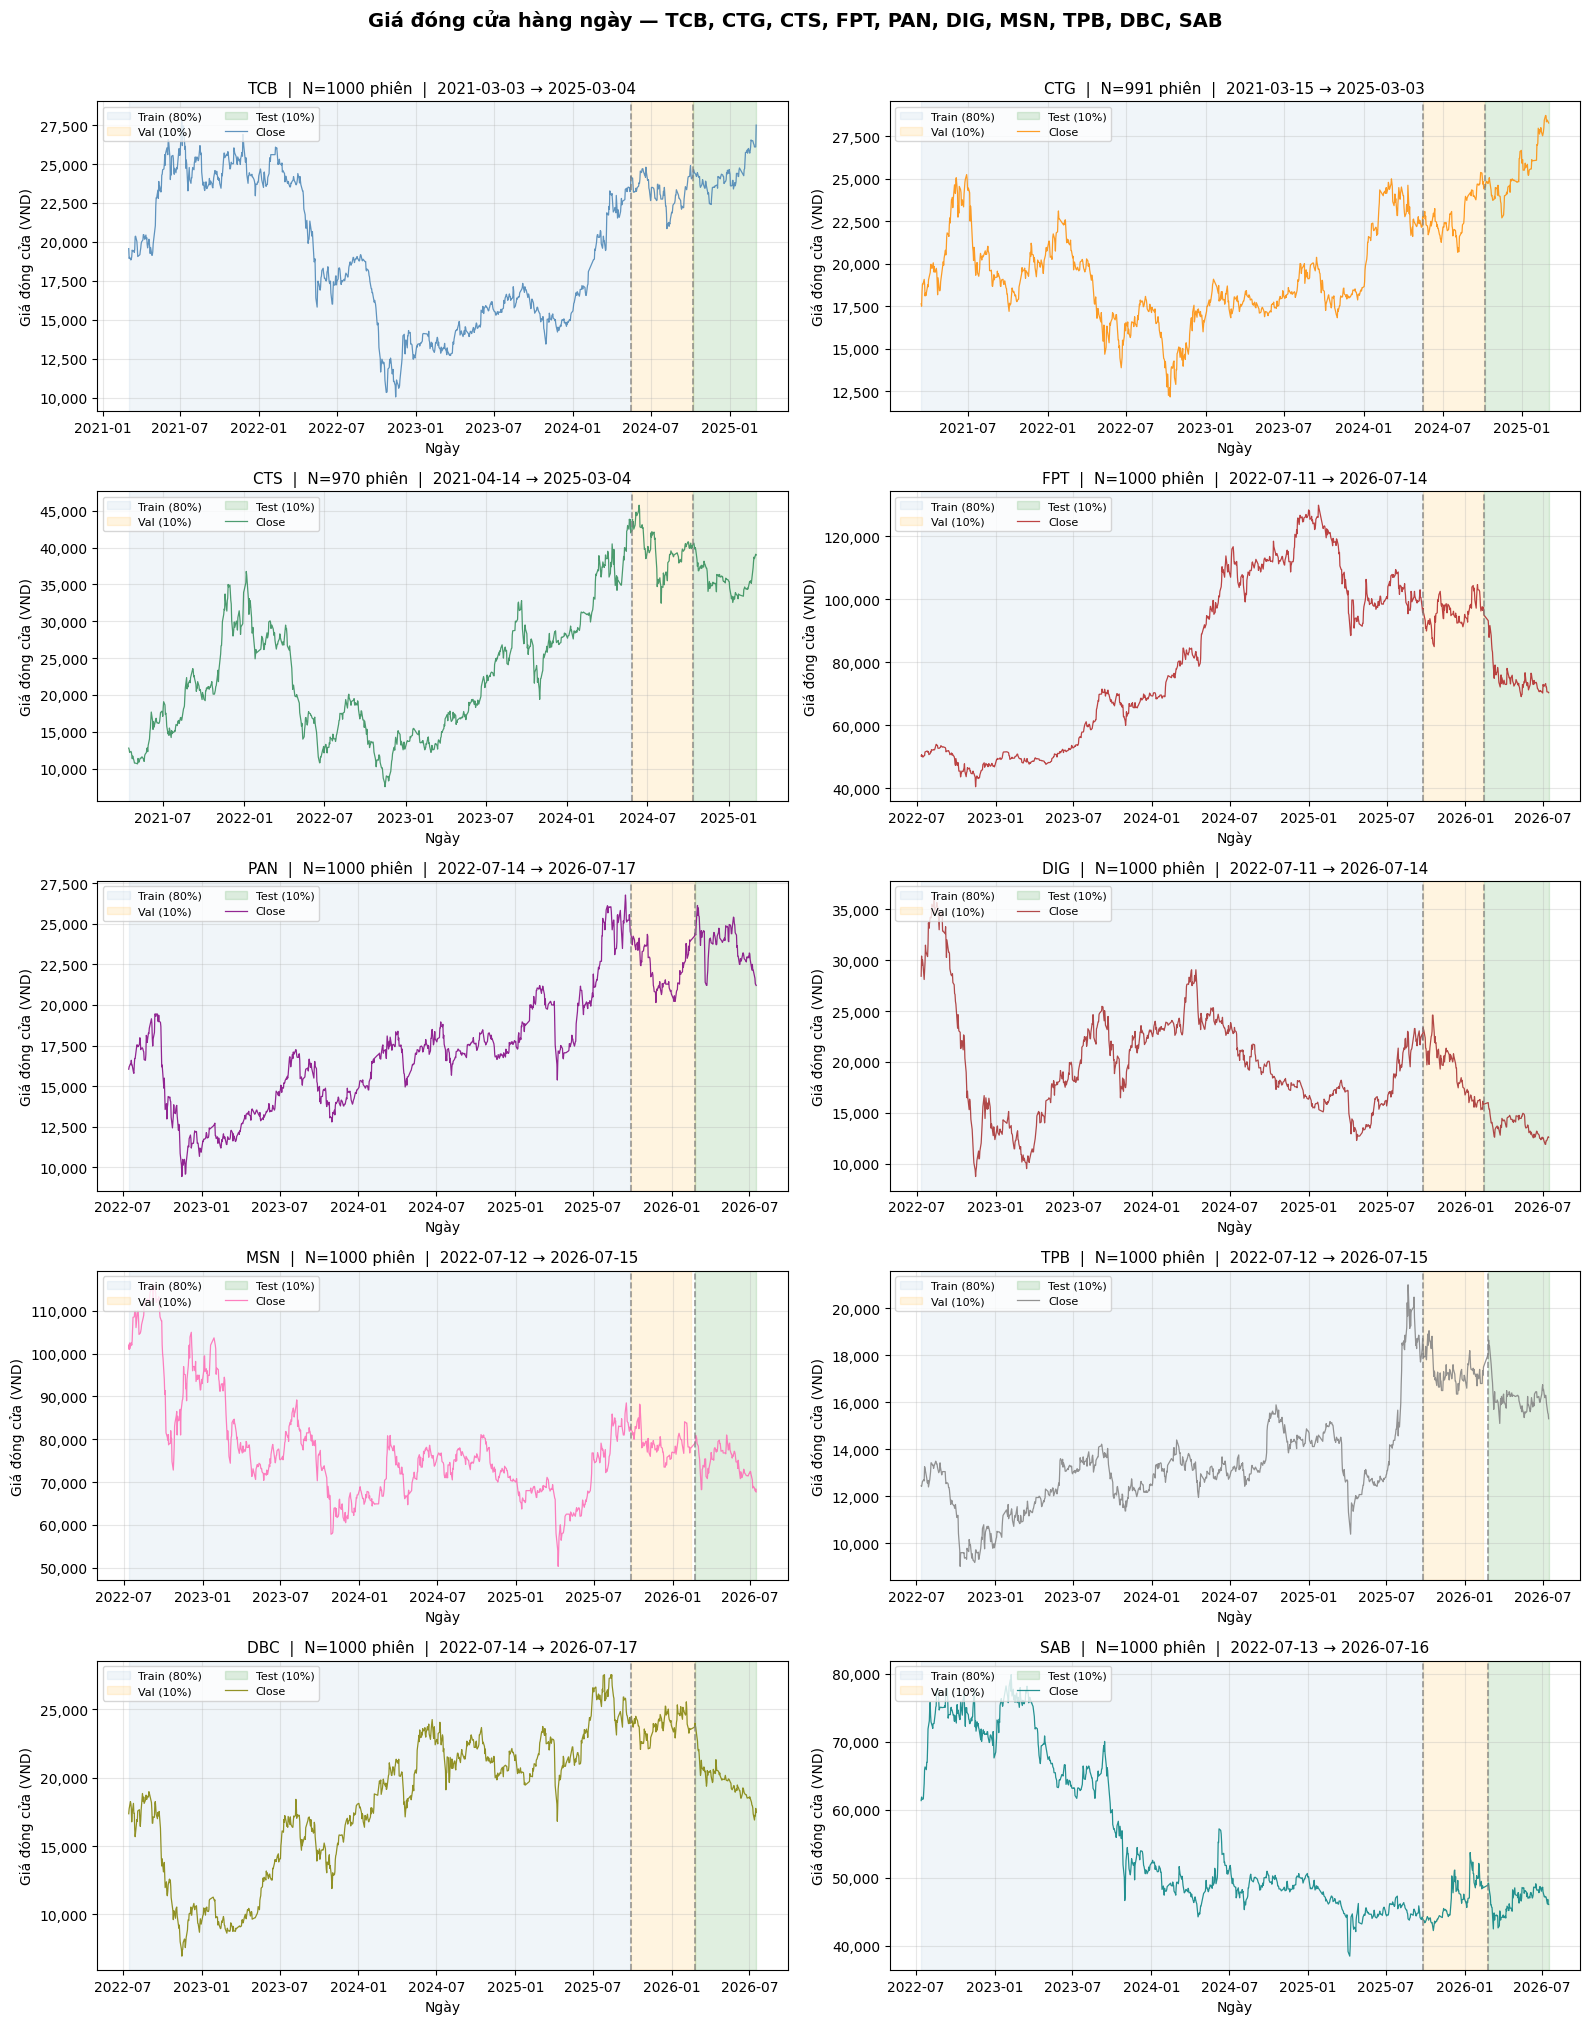

Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)
Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)
Train : 776 ngày (2021-04-14 → 2024-05-24)
Val   : 97 ngày (2024-05-27 → 2024-10-10)
Test  : 97 ngày (2024-10-11 → 2025-03-04)
Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)
Train : 800 ngày (2022-07-14 → 2025-09-26)
Val   : 100 ngày (2025-09-29 → 2026-02-24)
Test  : 100 ngày (2026-02-25 → 2026-07-17)
Train : 800 ngày (2022-07-11 → 2025-09-23)
Val   : 100 ngày (2025-09-24 → 2026-02-12)
Test  : 100 ngày (2026-02-13 → 2026-07-14)
Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ngày (2026-02-23 → 2026-07-15)
Train : 800 ngày (2022-07-12 → 2025-09-24)
Val   : 100 ngày (2025-09-25 → 2026-02-13)
Test  : 100 ng

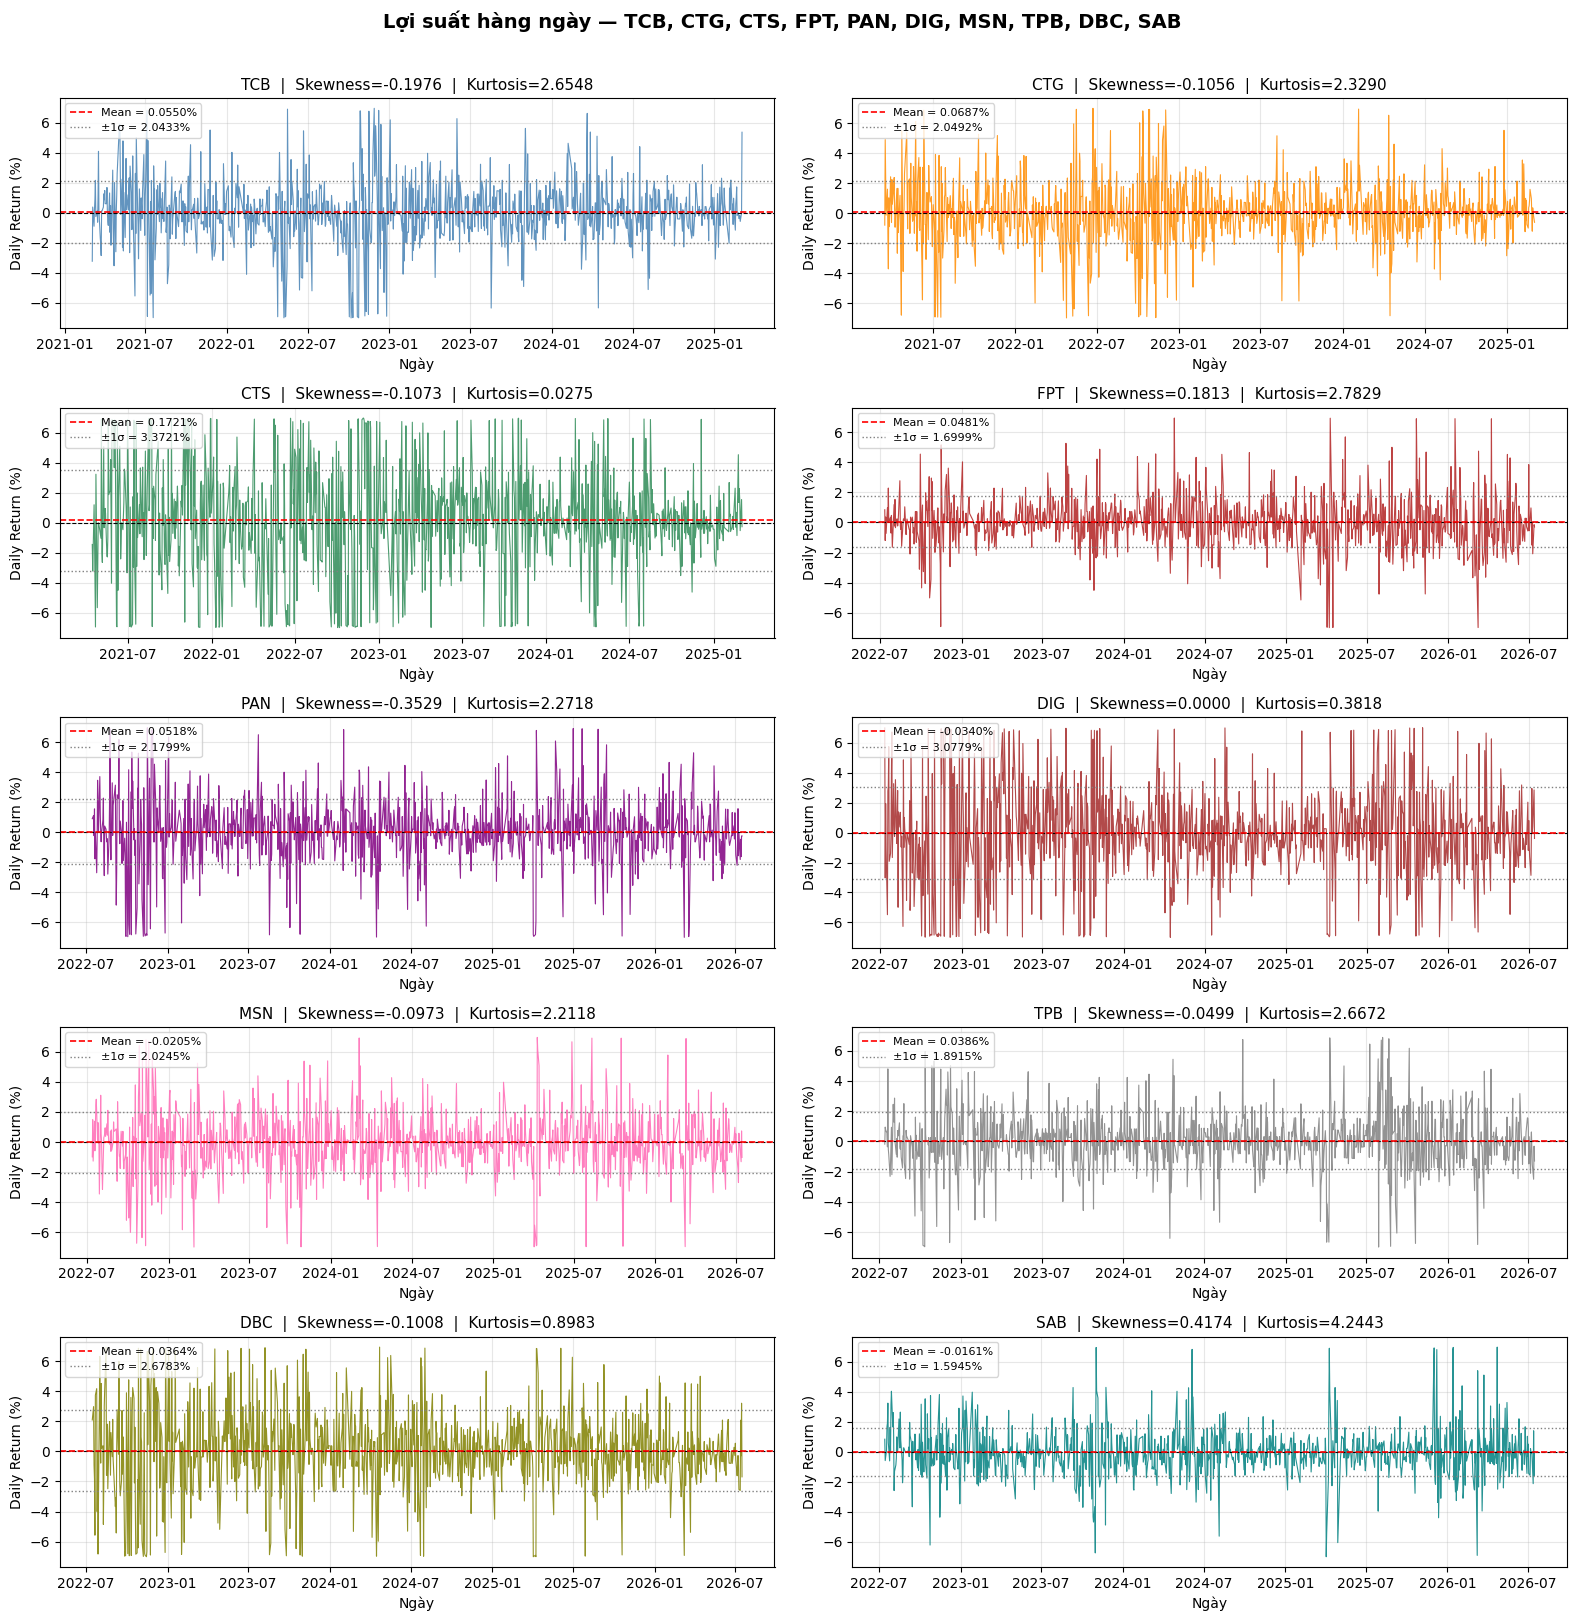

In [16]:
# ============================================================
# BỔ SUNG 5 — Thống kê mô tả các chuỗi giá
# ============================================================
def describe_series(results_dict, filepath, stock_name, loader_type):
    _, _, _, _, df = load_and_preprocess(
        filepath, smooth_window=5, loader_type=loader_type)
    close = df['Close']
    returns = close.pct_change().dropna()
    print(f"\n  {stock_name}:")
    print(f"    Số ngày giao dịch : {len(close)}")
    print(f"    Giá TB            : {close.mean():.0f}")
    print(f"    Std giá           : {close.std():.0f}")
    print(f"    Min / Max         : {close.min():.0f} / {close.max():.0f}")
    print(f"    Daily return TB   : {returns.mean()*100:.4f}%")
    print(f"    Volatility (std)  : {returns.std()*100:.4f}%")
    print(f"    Skewness          : {returns.skew():.4f}")
    print(f"    Kurtosis          : {returns.kurt():.4f}")
    from statsmodels.tsa.stattools import adfuller
    adf_stat, adf_p, *_ = adfuller(close.dropna())
    print(f"    ADF statistic     : {adf_stat:.4f}  (p={adf_p:.4f})")
    return {
        "Stock": stock_name, "N": len(close),
        "Mean": round(close.mean(), 0),
        "Std": round(close.std(), 0),
        "Min": round(close.min(), 0),
        "Max": round(close.max(), 0),
        "Daily Ret (%)": round(returns.mean()*100, 4),
        "Volatility (%)": round(returns.std()*100, 4),
        "Skewness": round(returns.skew(), 4),
        "Kurtosis": round(returns.kurt(), 4),
        "ADF p-value": round(adf_p, 4),
    }

print("\n" + "="*70)
print(f"THỐNG KÊ MÔ TẢ — {len(STOCKS)} CHUỖI GIÁ ĐÓNG CỬA")
print("="*70)
desc_rows = []
for filepath, stock_name, loader_type in STOCKS:
    desc_rows.append(describe_series(
        results[stock_name], filepath, stock_name, loader_type))
df_desc = pd.DataFrame(desc_rows).set_index("Stock")
print("\n", df_desc.to_string())
print("="*70)

# ── Biểu đồ giá đóng cửa từng mã ────────────────────────────────────
COLORS = ["steelblue", "darkorange", "seagreen", "firebrick", "purple",
          "brown", "hotpink", "gray", "olive", "teal"]
datasets = [
    (filepath, stock_name, loader_type, COLORS[i % len(COLORS)])
    for i, (filepath, stock_name, loader_type) in enumerate(STOCKS)
]

n_stocks = len(datasets)
ncols = 2
nrows = int(np.ceil(n_stocks / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), sharex=False)
fig.suptitle(f"Giá đóng cửa hàng ngày — {', '.join(s for _, s, _, _ in datasets)}",
             fontsize=14, fontweight="bold", y=1.01)
axes = np.array(axes).reshape(-1)

for ax, (filepath, stock_name, loader_type, color) in zip(axes, datasets):
    _, _, _, _, df = load_and_preprocess(
        filepath, smooth_window=5, loader_type=loader_type)

    close = df['Close']

    # Xác định ranh giới train/val/test
    n         = len(df)
    train_end = int(0.8 * n)
    val_end   = int(0.9 * n)
    idx_train = df.index[:train_end]
    idx_val   = df.index[train_end:val_end]
    idx_test  = df.index[val_end:]

    # Tô nền phân vùng
    ax.axvspan(idx_train[0], idx_train[-1],
               alpha=0.08, color="steelblue", label="Train (80%)")
    ax.axvspan(idx_val[0],   idx_val[-1],
               alpha=0.12, color="orange",    label="Val (10%)")
    ax.axvspan(idx_test[0],  idx_test[-1],
               alpha=0.12, color="green",     label="Test (10%)")

    # Vẽ giá đóng cửa gốc
    ax.plot(close.index, close.values,
            color=color, linewidth=0.9, alpha=0.85, label="Close")

    # Đường phân ranh giới
    ax.axvline(df.index[train_end], color="gray",
               linewidth=1.2, linestyle="--", alpha=0.8)
    ax.axvline(df.index[val_end],   color="gray",
               linewidth=1.2, linestyle="--", alpha=0.8)

    ax.set_title(f"{stock_name}  |  "
                 f"N={len(close)} phiên  |  "
                 f"{df.index[0].date()} → {df.index[-1].date()}",
                 fontsize=11)
    ax.set_ylabel("Giá đóng cửa (VND)")
    ax.set_xlabel("Ngày")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Ẩn các subplot thừa (nếu số mã lẻ)
for ax in axes[n_stocks:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# ── Biểu đồ lợi suất hàng ngày (daily return) ───────────────────────
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows), sharex=False)
fig2.suptitle(f"Lợi suất hàng ngày — {', '.join(s for _, s, _, _ in datasets)}",
              fontsize=14, fontweight="bold", y=1.01)
axes2 = np.array(axes2).reshape(-1)

for ax, (filepath, stock_name, loader_type, color) in zip(axes2, datasets):
    _, _, _, _, df = load_and_preprocess(
        filepath, smooth_window=5, loader_type=loader_type)
    returns = df['Close'].pct_change().dropna() * 100

    ax.plot(returns.index, returns.values,
            color=color, linewidth=0.8, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axhline(returns.mean(),  color="red",
               linewidth=1.2, linestyle="--",
               label=f"Mean = {returns.mean():.4f}%")
    ax.axhline(returns.mean() + returns.std(), color="gray",
               linewidth=1.0, linestyle=":",
               label=f"±1σ = {returns.std():.4f}%")
    ax.axhline(returns.mean() - returns.std(), color="gray",
               linewidth=1.0, linestyle=":")

    ax.set_title(f"{stock_name}  |  "
                 f"Skewness={returns.skew():.4f}  |  "
                 f"Kurtosis={returns.kurt():.4f}",
                 fontsize=11)
    ax.set_ylabel("Daily Return (%)")
    ax.set_xlabel("Ngày")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes2[n_stocks:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# BỔ SUNG 6 — Kiểm định ADF sau khi lấy sai phân bậc 1
# Xác nhận chuỗi Processed đã đạt tính dừng sau xử lý
# ============================================================
from statsmodels.tsa.stattools import adfuller

def check_stationarity_after_diff(filepath, stock_name, loader_type,
                                   smooth_window=5):
    _, _, _, _, df = load_and_preprocess(
        filepath, smooth_window=smooth_window, loader_type=loader_type)

    # ADF trên Close gốc
    adf_stat_close, adf_p_close, *_ = adfuller(df['Close'].dropna())

    # ADF trên Close_Smooth (chưa diff)
    adf_stat_smooth, adf_p_smooth, *_ = adfuller(df['Close_Smooth'].dropna())

    # ADF trên Processed (sau khi lấy sai phân bậc 1)
    adf_stat_proc, adf_p_proc, *_ = adfuller(df['Processed'].dropna())

    print(f"\n  {stock_name}:")
    print(f"    Close (gốc)         : ADF={adf_stat_close:.4f}, "
          f"p={adf_p_close:.4f}  "
          f"-> {'Dừng' if adf_p_close < 0.05 else 'Không dừng'}")
    print(f"    Close_Smooth         : ADF={adf_stat_smooth:.4f}, "
          f"p={adf_p_smooth:.4f}  "
          f"-> {'Dừng' if adf_p_smooth < 0.05 else 'Không dừng'}")
    print(f"    Processed (sau diff) : ADF={adf_stat_proc:.4f}, "
          f"p={adf_p_proc:.4f}  "
          f"-> {'Dừng' if adf_p_proc < 0.05 else 'Không dừng'}")

    return {
        "Stock": stock_name,
        "ADF Close": round(adf_stat_close, 4),
        "p Close": round(adf_p_close, 4),
        "ADF Close_Smooth": round(adf_stat_smooth, 4),
        "p Close_Smooth": round(adf_p_smooth, 4),
        "ADF Processed": round(adf_stat_proc, 4),
        "p Processed": round(adf_p_proc, 4),
    }

print("\n" + "="*75)
print("KIỂM ĐỊNH ADF — TRƯỚC VÀ SAU KHI LẤY SAI PHÂN BẬC 1")
print("="*75)

adf_rows = []
for filepath, stock_name, loader_type in STOCKS:
    adf_rows.append(check_stationarity_after_diff(filepath, stock_name, loader_type))

df_adf_compare = pd.DataFrame(adf_rows).set_index("Stock")
print("\n", df_adf_compare.to_string())
print("="*75)



KIỂM ĐỊNH ADF — TRƯỚC VÀ SAU KHI LẤY SAI PHÂN BẬC 1
Train : 800 ngày (2021-03-03 → 2024-05-16)
Val   : 100 ngày (2024-05-17 → 2024-10-07)
Test  : 100 ngày (2024-10-08 → 2025-03-04)

  TCB:
    Close (gốc)         : ADF=-0.8354, p=0.8085  -> Không dừng
    Close_Smooth         : ADF=-1.2640, p=0.6455  -> Không dừng
    Processed (sau diff) : ADF=-4.7573, p=0.0001  -> Dừng
Train : 792 ngày (2021-03-15 → 2024-05-16)
Val   : 99 ngày (2024-05-17 → 2024-10-04)
Test  : 100 ngày (2024-10-07 → 2025-03-03)

  CTG:
    Close (gốc)         : ADF=-0.9222, p=0.7806  -> Không dừng
    Close_Smooth         : ADF=-1.0642, p=0.7292  -> Không dừng
    Processed (sau diff) : ADF=-5.6015, p=0.0000  -> Dừng
Train : 776 ngày (2021-04-14 → 2024-05-24)
Val   : 97 ngày (2024-05-27 → 2024-10-10)
Test  : 97 ngày (2024-10-11 → 2025-03-04)

  CTS:
    Close (gốc)         : ADF=-1.4985, p=0.5343  -> Không dừng
    Close_Smooth         : ADF=-1.5282, p=0.5195  -> Không dừng
    Processed (sau diff) : ADF=-5.6796, p=

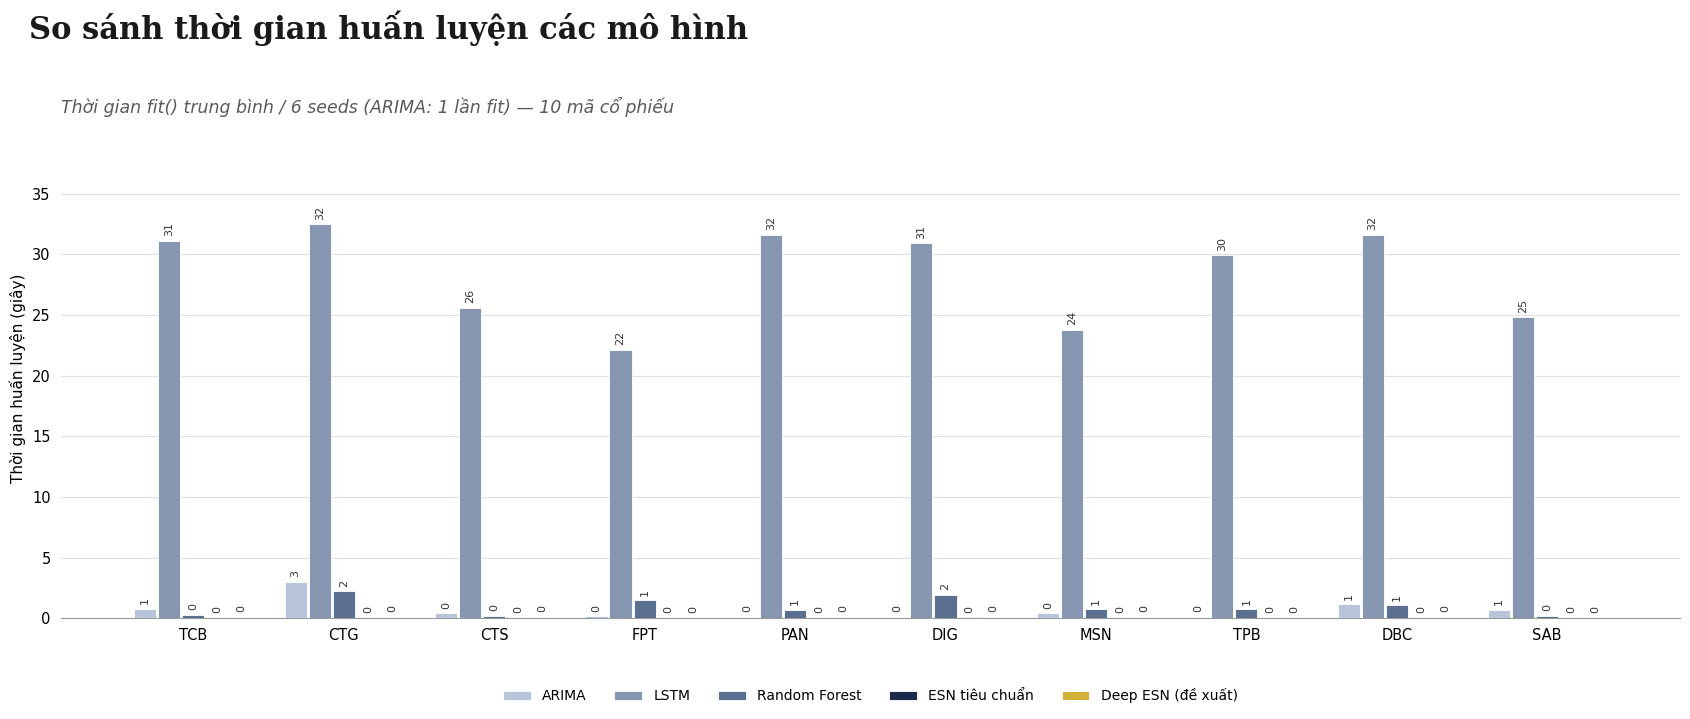


BẢNG THỜI GIAN HUẤN LUYỆN (GIÂY, mean ± std / 6 seeds) — TẤT CẢ CÁC MÃ
               ARIMA              LSTM    Random Forest   ESN tiêu chuẩn Deep ESN (đề xuất)
TCB  0.777s ± 0.000s  31.089s ± 4.666s  0.294s ± 0.010s  0.025s ± 0.000s    0.094s ± 0.015s
CTG  2.975s ± 0.000s  32.472s ± 8.524s  2.217s ± 0.331s  0.028s ± 0.000s    0.126s ± 0.027s
CTS  0.398s ± 0.000s  25.596s ± 6.580s  0.194s ± 0.009s  0.035s ± 0.005s    0.089s ± 0.024s
FPT  0.161s ± 0.000s  22.116s ± 4.974s  1.480s ± 0.361s  0.028s ± 0.000s    0.065s ± 0.025s
PAN  0.089s ± 0.000s  31.612s ± 5.701s  0.708s ± 0.071s  0.027s ± 0.001s    0.097s ± 0.022s
DIG  0.137s ± 0.000s  30.889s ± 8.780s  1.935s ± 0.303s  0.071s ± 0.003s    0.128s ± 0.028s
MSN  0.406s ± 0.000s  23.773s ± 4.809s  0.744s ± 0.212s  0.037s ± 0.006s    0.118s ± 0.026s
TPB  0.104s ± 0.000s  29.914s ± 4.177s  0.722s ± 0.013s  0.036s ± 0.009s    0.080s ± 0.020s
DBC  1.149s ± 0.000s  31.593s ± 6.445s  1.064s ± 0.326s  0.027s ± 0.001s    0.120s ± 0.017s
SAB  0.6

In [18]:
# ============================================================
# BỔ SUNG — Bảng & biểu đồ so sánh THỜI GIAN HUẤN LUYỆN
# (chỉ tính .fit() trên tập trainval, mean ± std trên 6 seeds; ARIMA std=0)
# ============================================================
_MODEL_TRAINTIME_KEY = {
    "ARIMA":              "traintime_arima",
    "LSTM":               "traintime_lstm",
    "Random Forest":      "traintime_rf",
    "ESN tiêu chuẩn":     "traintime_esn",
    "Deep ESN (đề xuất)": "traintime_deepesn",
}

stock_names = [s for _, s, _ in STOCKS]
model_names = list(_MODEL_TRAINTIME_KEY.keys())
n_stocks    = len(stock_names)
n_models    = len(model_names)

traintime_matrix = np.array([
    [results[stock][_MODEL_TRAINTIME_KEY[m]] for m in model_names]
    for stock in stock_names
])  # shape (n_stocks, n_models), đơn vị giây

# --- Biểu đồ cột nhóm (giây) ---
fig, ax = plt.subplots(figsize=(max(14, n_stocks * 1.7), 7))
x     = np.arange(n_stocks)
bar_w = 0.8 / n_models

for j, model in enumerate(model_names):
    vals = traintime_matrix[:, j]
    xs   = x + (j - (n_models - 1) / 2) * bar_w
    bars = ax.bar(xs, vals, width=bar_w * 0.92,
                  color=MODEL_COLORS[model], label=model,
                  edgecolor="white", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + traintime_matrix.max() * 0.012,
                 vn_number(v), ha="center", va="bottom",
                 fontsize=8, color="#333333", rotation=90 if n_stocks > 6 else 0)

ax.set_xticks(x)
ax.set_xticklabels(stock_names, fontsize=11)
ax.set_ylabel("Thời gian huấn luyện (giây)", fontsize=11)
ax.set_ylim(0, traintime_matrix.max() * 1.22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=n_models, frameon=False, fontsize=10)

style_slide_chart(
    fig, ax,
    "So sánh thời gian huấn luyện các mô hình",
    f"Thời gian fit() trung bình / 6 seeds (ARIMA: 1 lần fit) — {n_stocks} mã cổ phiếu")

plt.tight_layout()
plt.show()

# --- Bảng chi tiết mean ± std theo từng mã ---
def _traintime_cell(stock, model_key):
    r = results[stock]
    mean = r[model_key]
    list_key = model_key.replace("traintime_", "traintime_list_")
    std = np.std(r[list_key]) if r.get(list_key) else 0.0
    return f"{mean:.3f}s ± {std:.3f}s"

df_traintime_detail = pd.DataFrame(
    [[_traintime_cell(s, _MODEL_TRAINTIME_KEY[m]) for m in model_names] for s in stock_names],
    index=stock_names, columns=model_names)

print("\n" + "="*100)
print("BẢNG THỜI GIAN HUẤN LUYỆN (GIÂY, mean ± std / 6 seeds) — TẤT CẢ CÁC MÃ")
print("="*100)
print(df_traintime_detail.to_string())
print("="*100)

# --- Bảng tổng hợp: trung bình toàn bộ các mã, xếp hạng nhanh -> chậm ---
avg_traintime_per_model = pd.Series(
    traintime_matrix.mean(axis=0), index=model_names).sort_values()
df_traintime_summary = pd.DataFrame({
    "TB thời gian huấn luyện (giây)": avg_traintime_per_model.round(4),
    "Tổng thời gian / 6 mã (giây)":   (avg_traintime_per_model * n_stocks).round(2),
})
df_traintime_summary.index.name = "Mô hình"

print("\n" + "="*100)
print(f"BẢNG TỔNG HỢP — THỜI GIAN HUẤN LUYỆN TRUNG BÌNH ({n_stocks} mã, xếp hạng nhanh → chậm)")
print("="*100)
print(df_traintime_summary.to_string())
print("="*100)